In [1]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Adjusting D_MODEL to 130 to be divisible by 5 heads.
Defined Muscle Groups (Indices): {'Finger Flexors': [2, 3], 'Finger Extensors': [4, 5], 'Wrist Flex/Dev': [1], 'Wrist Extend/Dev': [6, 7], 'Thumb': [0]}
Loading data from: s4_full.mat
Data loaded successfully.
Preprocessing data (No explicit filtering)...
Fitting scalers...
Scalers fitted.
Creating sequences from 35 valid trials...
Created 133000 sequences from 35 trials.
Train size: 106400, Validation size: 26600
Building MHA model...
MHA models built successfully.

--- Training Model Summary ---
Model: "Finger_MHA_Training_Model"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     Param #           Connected to                                      
 emg_input (InputLayer)                          [(None, 200, 8)]                 0                 []     

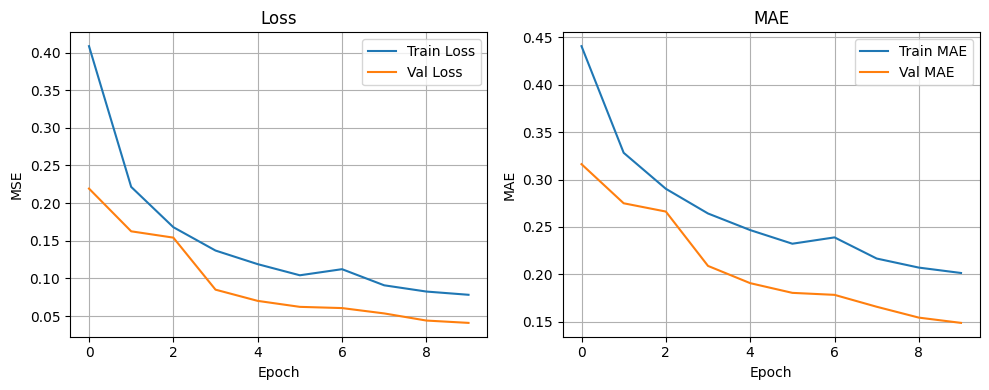


--- Performance Evaluation on Validation Set ---
832/832 [==============================] - 9s 10ms/step
Average R2 Score: 0.960
Average CC Score: 0.981


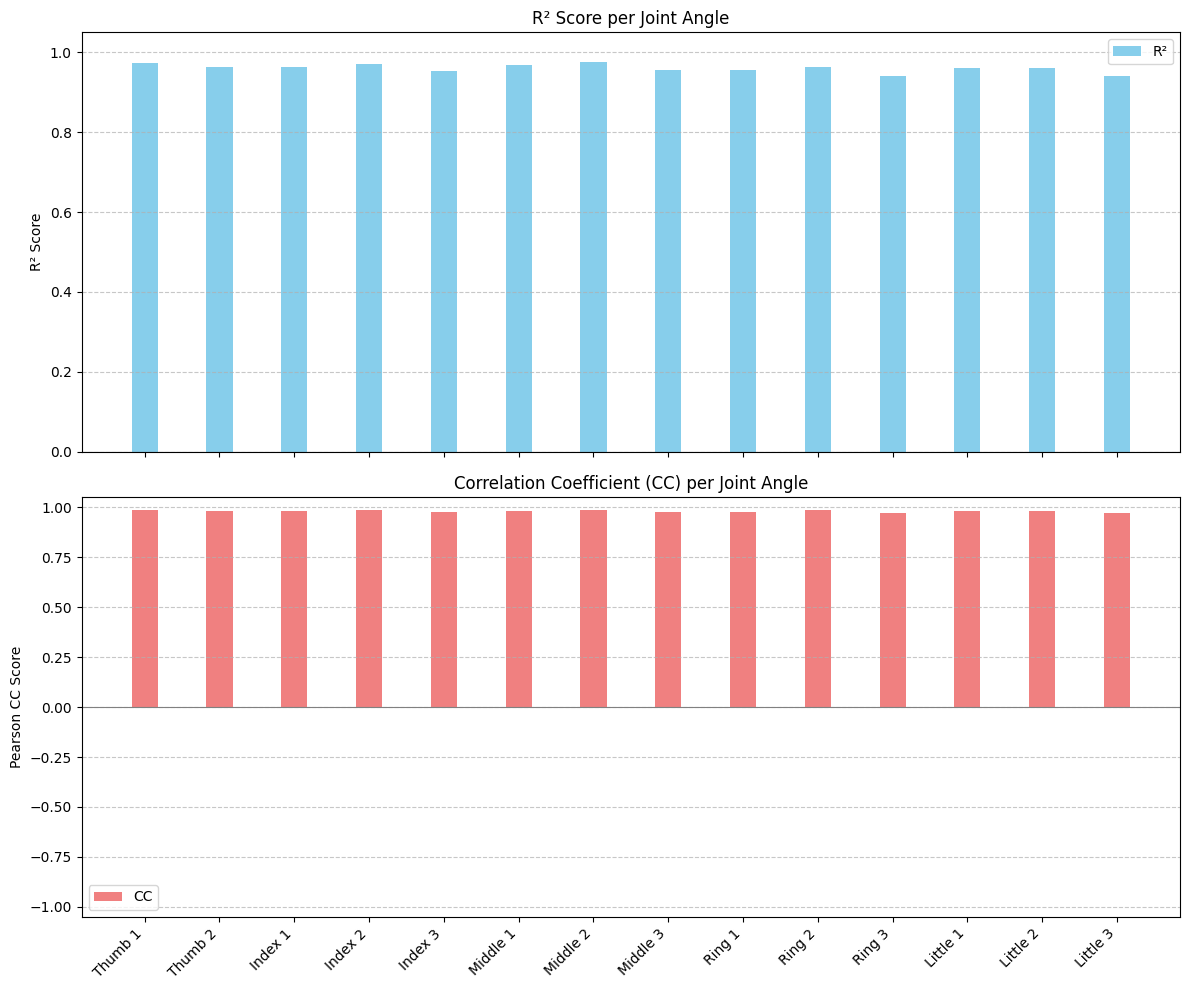

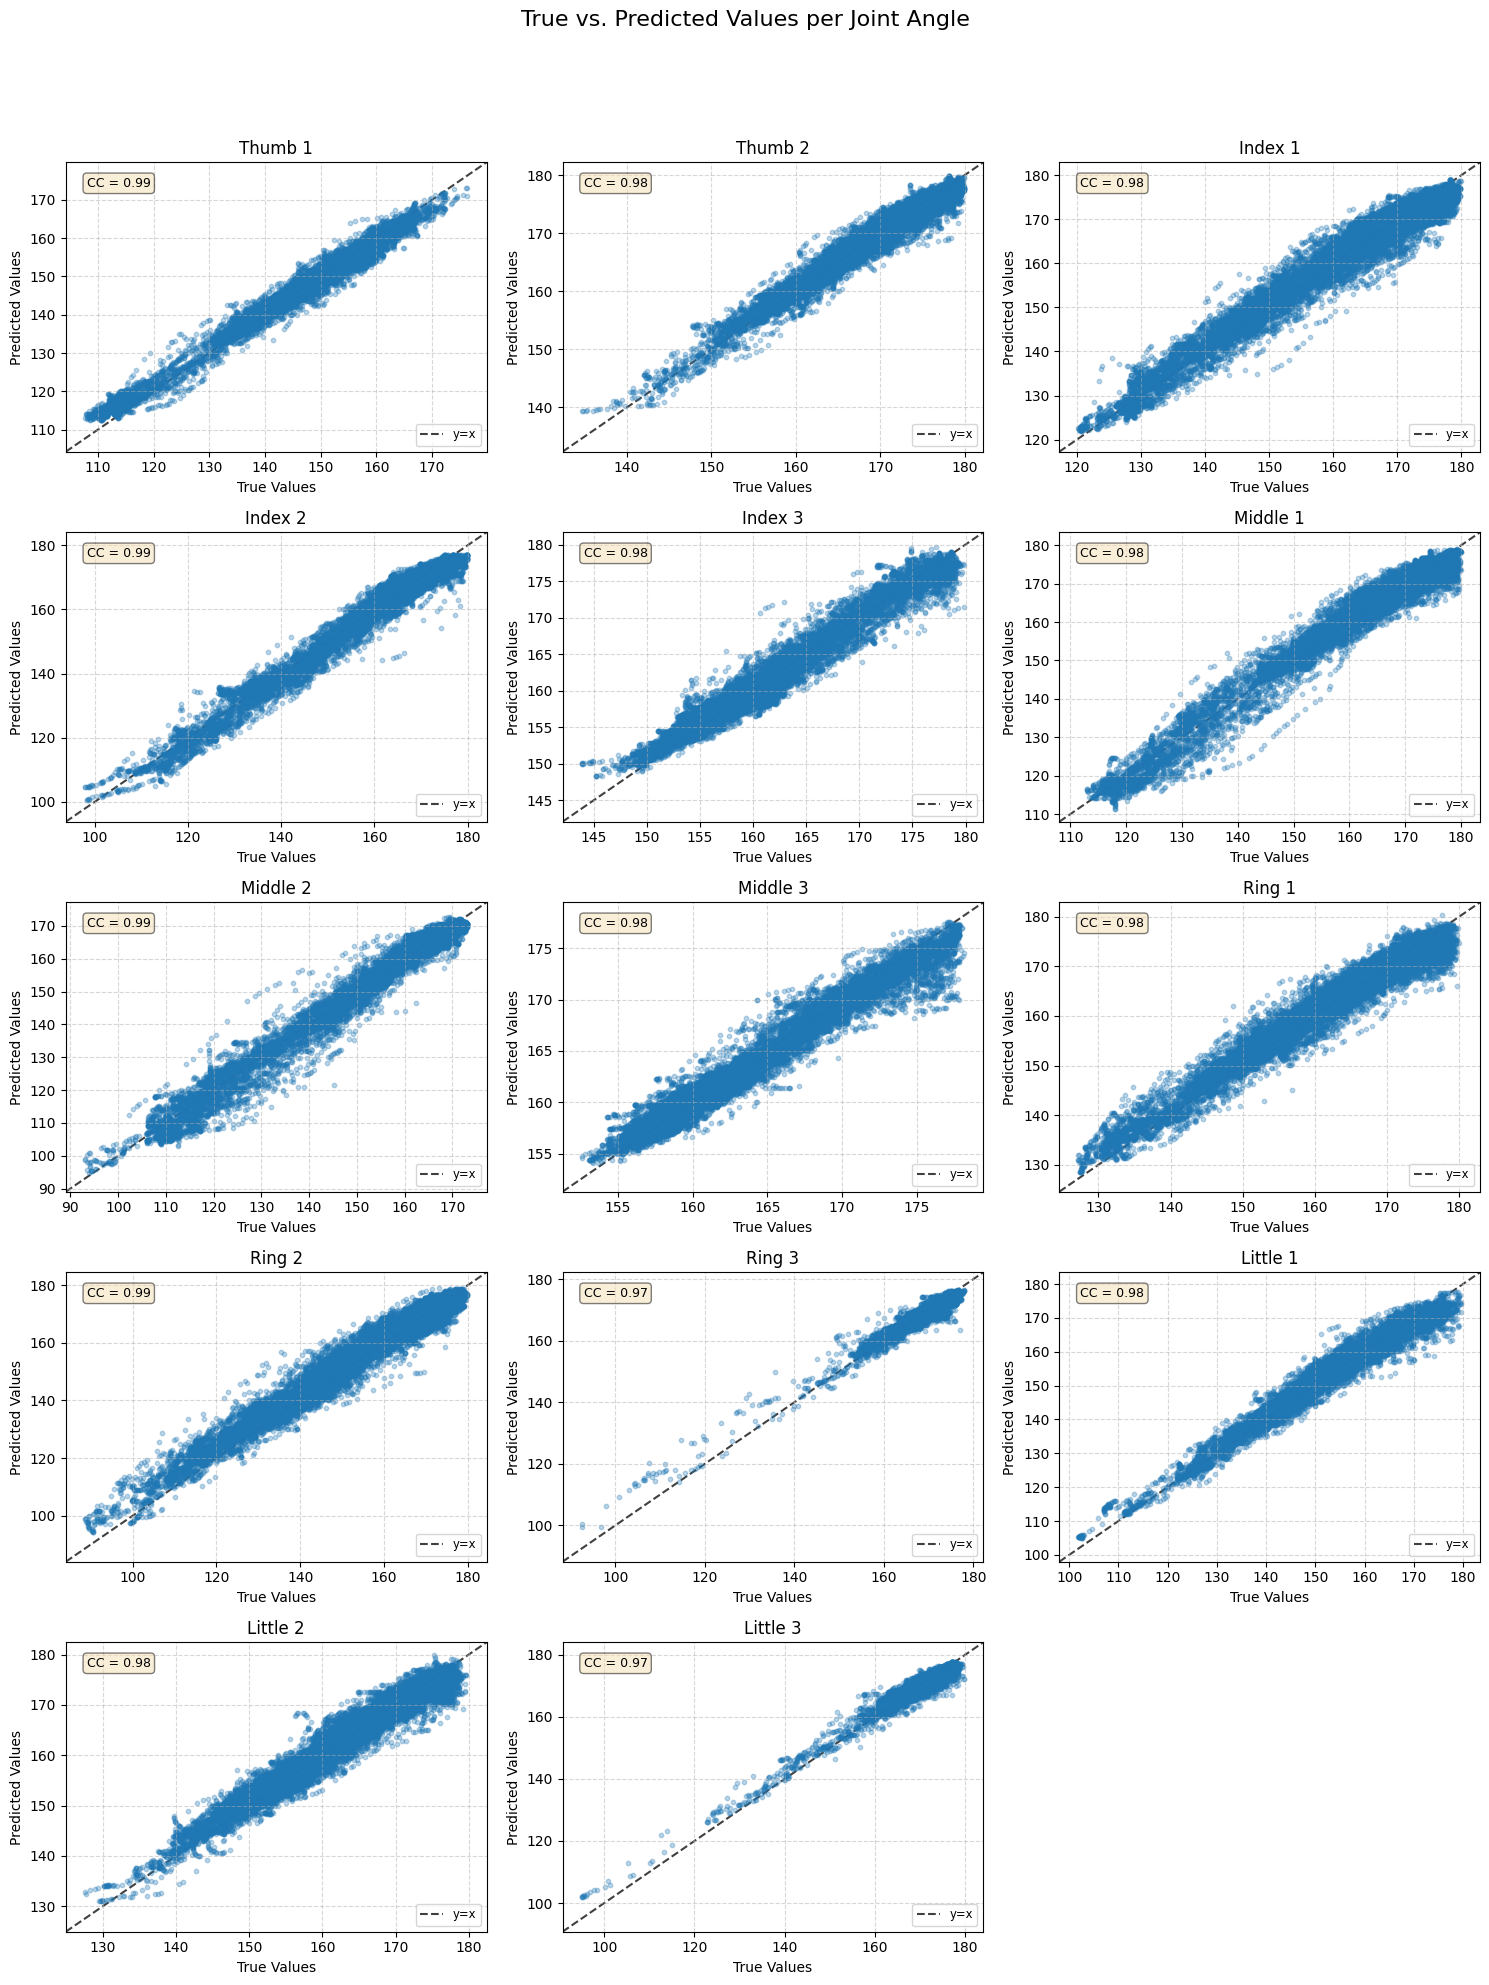


--- Detailed MHA Attention Visualization (Sample Windows) ---
Visualizing MHA attention heatmaps for the first 2 validation sample windows...

--- Visualizing MHA Attention Heatmap for Sample Window Index 0 ---


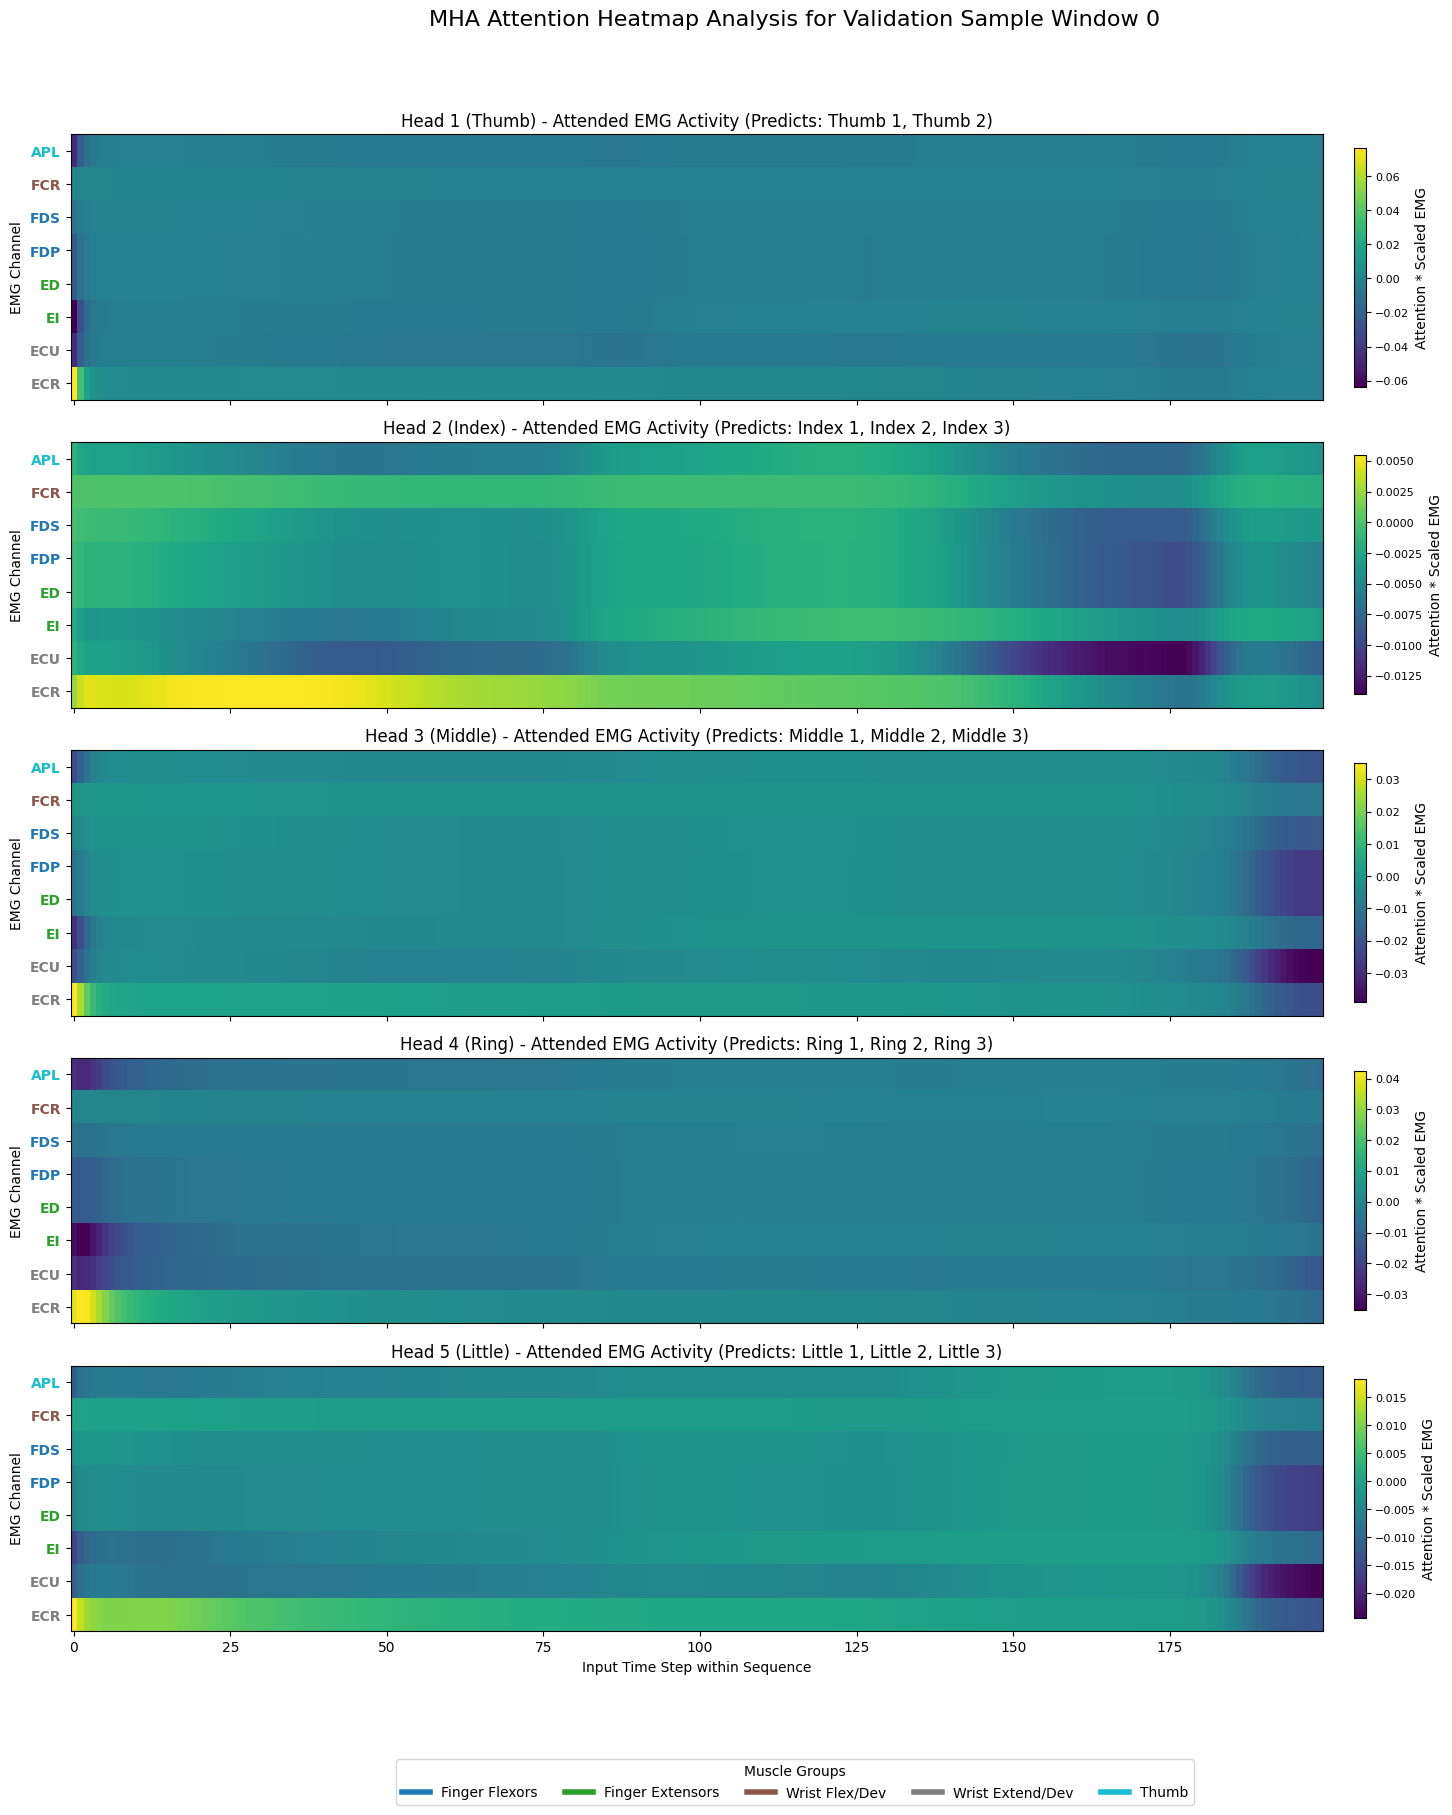


--- Visualizing MHA Attention Heatmap for Sample Window Index 1 ---


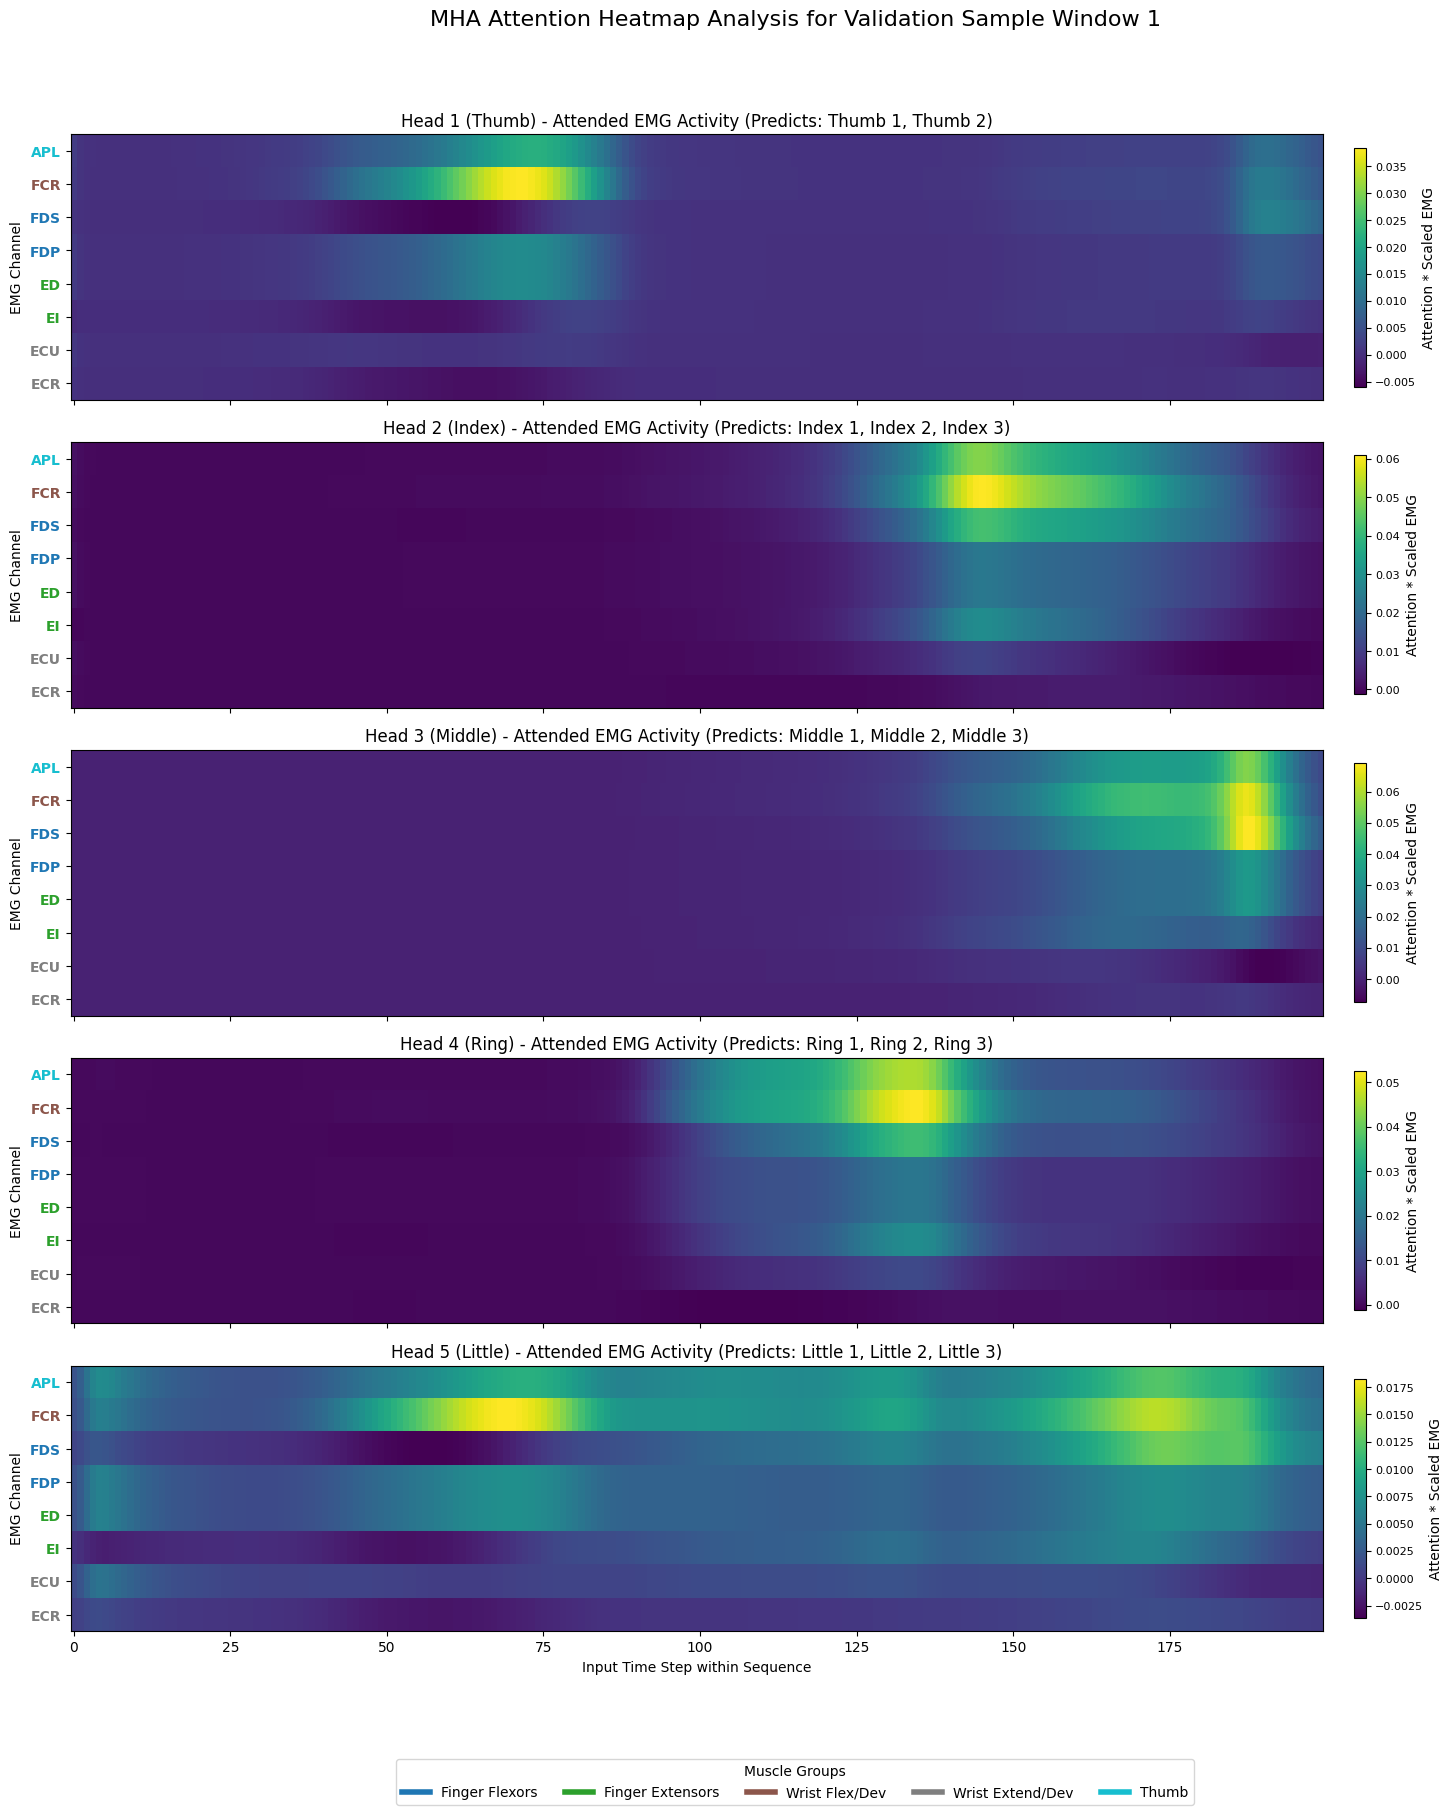


--- Dynamic Trial Simulation Visualization (EMG/Angle/Attention) ---
Visualizing dynamics simulation for the first 1 original trials...

--- Plotting Dynamics Simulation for Trial: T1_Task1 ---
Running model prediction for simulation...


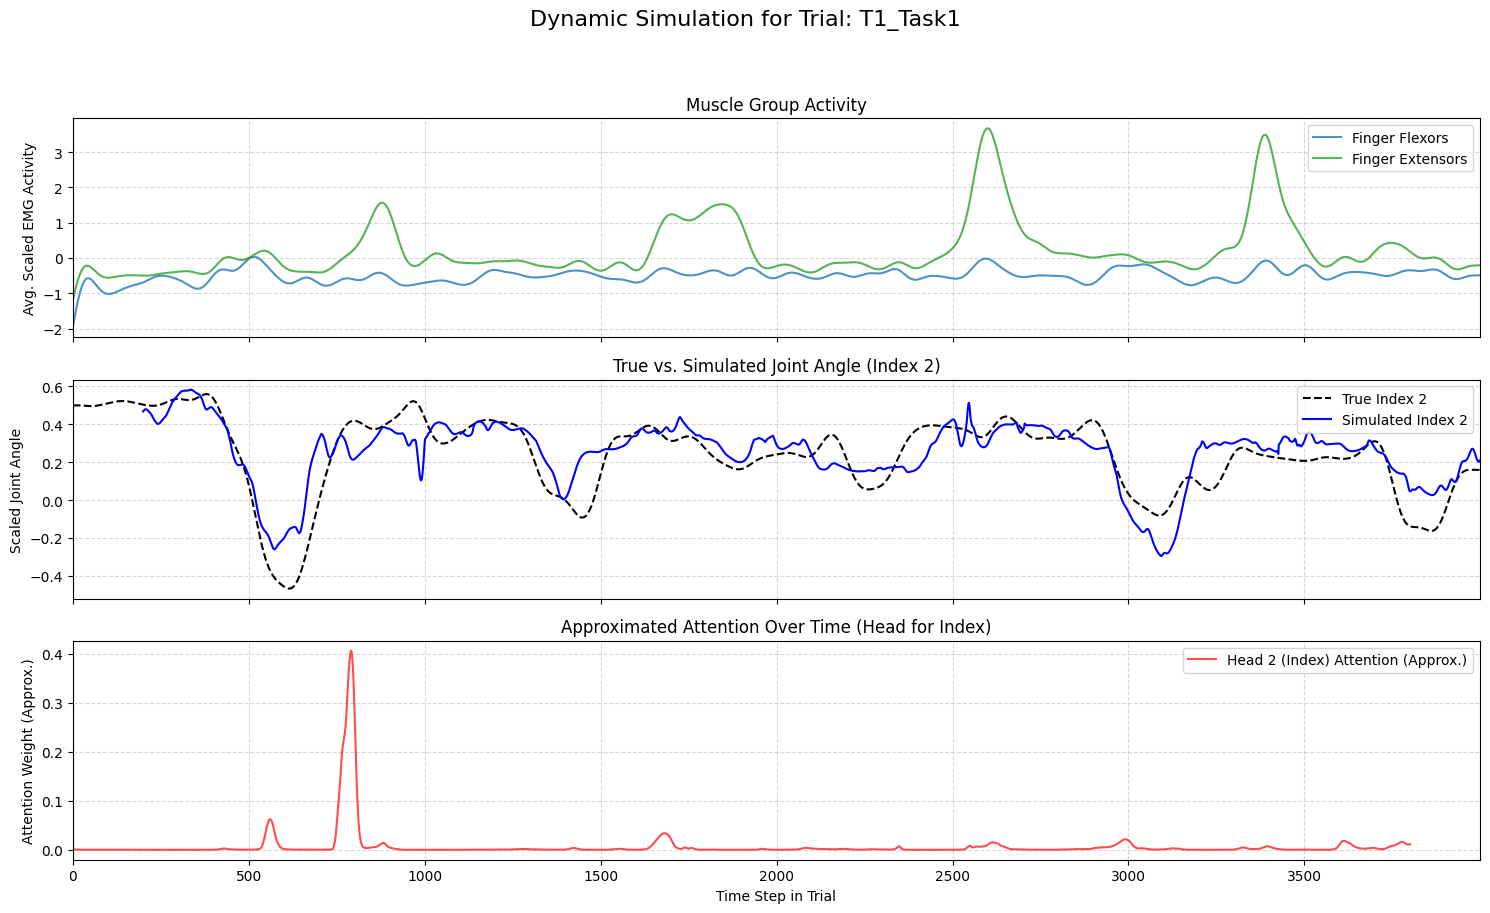


--- Integrated Gradients XAI Visualization ---
Calculating Integrated Gradients for the first 2 validation sample(s)...

--- Explaining Sample Index 0 ---
Explaining prediction for: Index 2 (Index 3)


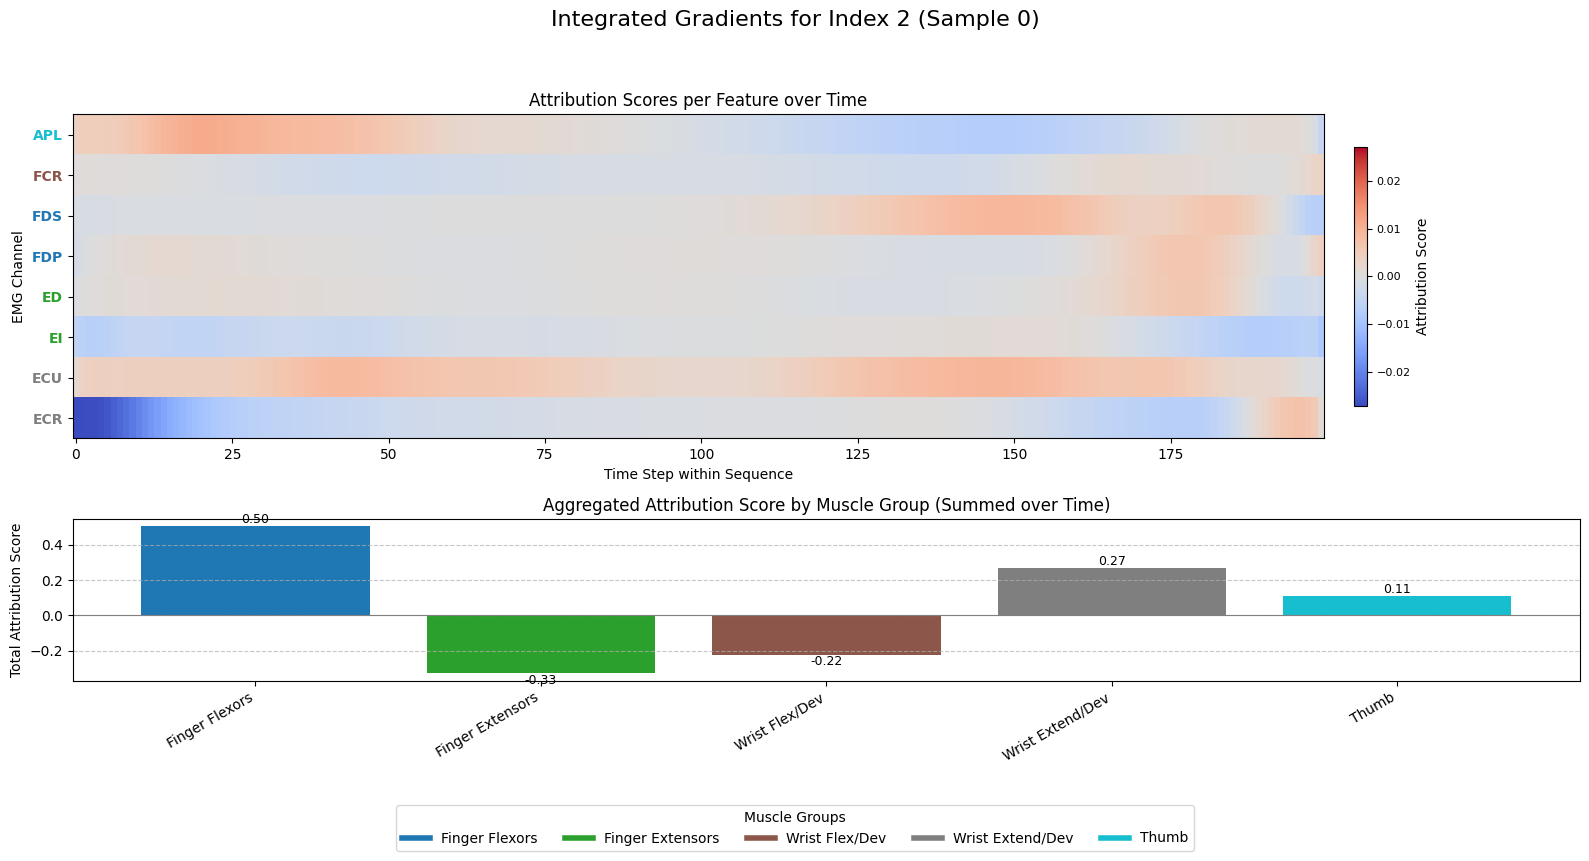


--- Explaining Sample Index 1 ---
Explaining prediction for: Index 2 (Index 3)


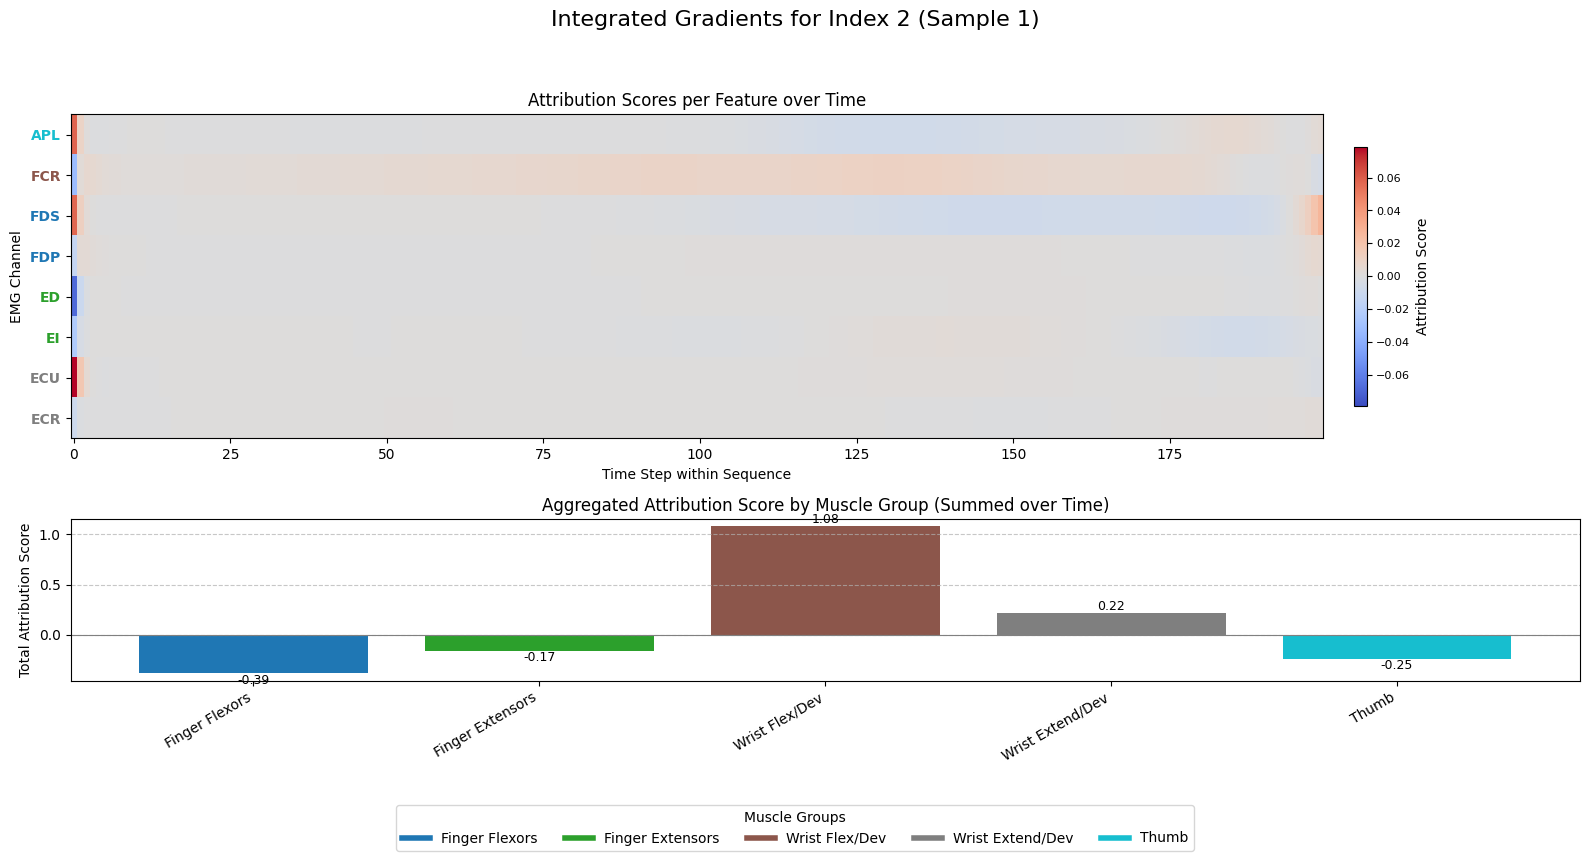

In [ ]:
# -*- coding: utf-8 -*-
"""
Python script for predicting finger kinematics from EMG using a
Multi-Head Attention (MHA) LSTM model with specific EMG preprocessing
and Integrated Gradients for XAI.

Includes:
- Custom MHA model with separate finger heads.
- R2/CC score plotting.
- Regression correlation scatter plots.
- MHA Attention Heatmap visualization (per head, normalized).
- Dynamic Simulation plot (EMG/True Angle/Predicted Angle/Attention).
- Integrated Gradients calculation and visualization.

"""

import numpy as np
import scipy.io
import scipy.stats
# Removed: from scipy.signal import butter, sosfiltfilt # For filtering
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Layer, Dropout, Lambda, LayerNormalization, MultiHeadAttention,
    Concatenate
)
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score
import os
import warnings
import math

# --- Configuration ---
MAT_FILE_PATH = 's4_full.mat' # <<<--- Example path, UPDATE FOR COLAB
SEQUENCE_LENGTH = 200
PREDICTION_HORIZON = 1 # Keep as 1 for current model structure
BATCH_SIZE = 128
EPOCHS = 10 # Adjust as needed
LSTM_UNITS = 128
VALIDATION_SPLIT = 0.2
MAX_SAMPLES_TO_VIZ_MHA = 2 # Limit detailed MHA heatmap visualization output
NUM_TRIALS_TO_PLOT_DYNAMICS = 1 # Limit dynamic plot output
NUM_SAMPLES_FOR_XAI = 2 # How many samples to run XAI (IG) on

# EMG Preprocessing Config - Filter parameters removed
# FS = 200.0
# LOWCUT = 20.0
# HIGHCUT = 95.0
# FILTER_ORDER = 4

# MHA Configuration
NUM_ATTENTION_HEADS = 5
D_MODEL = LSTM_UNITS
if D_MODEL % NUM_ATTENTION_HEADS != 0:
     D_MODEL = math.ceil(D_MODEL / NUM_ATTENTION_HEADS) * NUM_ATTENTION_HEADS
     print(f"Adjusting D_MODEL to {D_MODEL} to be divisible by {NUM_ATTENTION_HEADS} heads.")

# Integrated Gradients Config
IG_STEPS = 50 # Number of steps for approximation

# EMG Channel Names
EMG_CHANNEL_NAMES = ['APL', 'FCR', 'FDS', 'FDP', 'ED', 'EI', 'ECU', 'ECR']
# Joint Angle Names
JOINT_ANGLE_NAMES = [
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]
# Finger to Joint Mapping
FINGER_JOINT_INDICES = {
    'Thumb': list(range(0, 2)), 'Index': list(range(2, 5)), 'Middle': list(range(5, 8)),
    'Ring': list(range(8, 11)), 'Little': list(range(11, 14))
}
FINGER_NAMES = list(FINGER_JOINT_INDICES.keys())

# --- Muscle Group Definitions ---
MUSCLE_GROUPS = {
    'Finger Flexors': [EMG_CHANNEL_NAMES.index('FDS'), EMG_CHANNEL_NAMES.index('FDP')],
    'Finger Extensors': [EMG_CHANNEL_NAMES.index('ED'), EMG_CHANNEL_NAMES.index('EI')],
    'Wrist Flex/Dev': [EMG_CHANNEL_NAMES.index('FCR')],
    'Wrist Extend/Dev': [EMG_CHANNEL_NAMES.index('ECU'), EMG_CHANNEL_NAMES.index('ECR')],
    'Thumb': [EMG_CHANNEL_NAMES.index('APL')]
}
# Assign colors
try: cmap = plt.colormaps.get_cmap('tab10')
except AttributeError: cmap = plt.cm.get_cmap('tab10')
GROUP_COLORS = cmap(np.linspace(0, 1, len(MUSCLE_GROUPS)))
MUSCLE_GROUP_VIS_INFO = {name: {'indices': indices, 'color': GROUP_COLORS[i]}
                         for i, (name, indices) in enumerate(MUSCLE_GROUPS.items())}
print("Defined Muscle Groups (Indices):", MUSCLE_GROUPS)

# --- Custom Multi-Head Attention Layer ---
# (Definition remains the same as previous version)
class CustomMultiHeadAttentionSeparateOutput(Layer):
    """ Custom MHA layer returning separate context vectors per head. """
    def __init__(self, num_heads, d_model, **kwargs):
        super().__init__(**kwargs)
        if d_model % num_heads != 0: raise ValueError(f"d_model ({d_model}) must be divisible by num_heads ({num_heads})")
        self.num_heads = num_heads; self.d_model = d_model; self.depth = d_model // num_heads
        self.wq = Dense(d_model, name='q_proj'); self.wk = Dense(d_model, name='k_proj'); self.wv = Dense(d_model, name='v_proj')

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v, mask=None):
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        if mask is not None: scaled_attention_logits += (mask * -1e9)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        return output, attention_weights

    def call(self, query, value, key, mask=None, return_attention_scores=False):
        batch_size = tf.shape(query)[0]
        q = self.wq(query); k = self.wk(key); v = self.wv(value)
        q = self.split_heads(q, batch_size); k = self.split_heads(k, batch_size); v = self.split_heads(v, batch_size)
        scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        head_outputs = [scaled_attention[:, :, i, :] for i in range(self.num_heads)]
        if query.shape[1] == 1: head_outputs_squeezed = [tf.squeeze(head, axis=1) for head in head_outputs]
        else: head_outputs_squeezed = head_outputs
        squeezed_attention_weights = tf.squeeze(attention_weights, axis=2)
        if return_attention_scores: return head_outputs_squeezed, squeezed_attention_weights
        else: return head_outputs_squeezed

    def get_config(self):
        config = super().get_config()
        config.update({'num_heads': self.num_heads, 'd_model': self.d_model})
        return config

# --- 1. Data Loading ---
def load_mat_data(filepath):
    """Loads EMG and joint angle data from the specified .mat file."""
    print(f"Loading data from: {filepath}")
    if not os.path.exists(filepath): print(f"Error: File not found at {filepath}"); return None, None, None
    try:
        mat_data = scipy.io.loadmat(filepath)
        emg_data_cells = mat_data['dsfilt_emg']
        joint_angles_cells = mat_data['joint_angles']
        kinematics_data = mat_data.get('finger_kinematics', None)
        print("Data loaded successfully.")
        return emg_data_cells, joint_angles_cells, kinematics_data
    except Exception as e: print(f"An error occurred during loading: {e}"); return None, None, None

# --- 2. Data Preprocessing (Filtering Removed) ---
# Removed filter design and application functions

# Removed filter parameters from signature
def preprocess_data(emg_data_cells, joint_angles_cells, sequence_length, prediction_horizon):
    """ Preprocesses data: flattens, creates sequences, normalizes, splits. (No filtering) """
    print("Preprocessing data (No explicit filtering)...")
    all_emg_sequences, all_angle_targets = [], []
    original_scaled_trials = []
    num_trials, num_tasks = emg_data_cells.shape
    emg_scaler, angle_scaler = StandardScaler(), StandardScaler()
    temp_emg_list, temp_angle_list = [], []

    # --- Fit scalers first (on raw data) ---
    print("Fitting scalers...")
    emg_list_for_scaling = [] # Renamed list
    angle_list_for_scaling = []
    valid_trial_count = 0
    for i in range(num_trials):
        for j in range(num_tasks):
            if isinstance(emg_data_cells[i, j], np.ndarray) and emg_data_cells[i, j].ndim == 2 and emg_data_cells[i, j].shape[0] > 0 and \
               isinstance(joint_angles_cells[i, j], np.ndarray) and joint_angles_cells[i, j].ndim == 2 and joint_angles_cells[i, j].shape[0] > 0:
                min_len = min(emg_data_cells[i,j].shape[0], joint_angles_cells[i,j].shape[0])
                if min_len >= sequence_length + prediction_horizon:
                    trial_emg = emg_data_cells[i, j][:min_len, :] # Use raw EMG
                    trial_angle = joint_angles_cells[i, j][:min_len, :]
                    # --- Filtering Removed ---
                    emg_list_for_scaling.append(trial_emg) # Append raw EMG
                    angle_list_for_scaling.append(trial_angle)
                    valid_trial_count += 1

    if not emg_list_for_scaling: print("Error: No valid data/trials long enough found."); return None, None, None, None, None, None, None
    full_emg_data = np.vstack(emg_list_for_scaling); full_angle_data = np.vstack(angle_list_for_scaling)
    if np.any(np.isnan(full_emg_data)) or np.any(np.isinf(full_emg_data)) or \
       np.any(np.isnan(full_angle_data)) or np.any(np.isinf(full_angle_data)): raise ValueError("NaN or Inf detected in data.")
    emg_scaler.fit(full_emg_data); angle_scaler.fit(full_angle_data); print("Scalers fitted.")

    # --- Create sequences and store original scaled trials ---
    print(f"Creating sequences from {valid_trial_count} valid trials...")
    trial_count = 0
    for i in range(num_trials):
        for j in range(num_tasks):
             if isinstance(emg_data_cells[i, j], np.ndarray) and emg_data_cells[i, j].ndim == 2 and emg_data_cells[i, j].shape[0] > 0 and \
               isinstance(joint_angles_cells[i, j], np.ndarray) and joint_angles_cells[i, j].ndim == 2 and joint_angles_cells[i, j].shape[0] > 0:
                min_len = min(emg_data_cells[i,j].shape[0], joint_angles_cells[i,j].shape[0])
                if min_len >= sequence_length + prediction_horizon:
                    trial_emg = emg_data_cells[i, j][:min_len, :] # Raw EMG
                    trial_angle = joint_angles_cells[i, j][:min_len, :]
                    # --- Filtering Removed ---
                    # Scale the full raw trial
                    trial_emg_scaled = emg_scaler.transform(trial_emg) # Scale raw EMG
                    trial_angle_scaled = angle_scaler.transform(trial_angle)
                    original_scaled_trials.append({'emg': trial_emg_scaled, 'angle': trial_angle_scaled, 'id': f"T{i+1}_Task{j+1}"})
                    # Create sequences from this scaled trial
                    for k in range(len(trial_emg_scaled) - sequence_length - prediction_horizon + 1):
                        emg_sequence = trial_emg_scaled[k : k + sequence_length]
                        angle_target = trial_angle_scaled[k + sequence_length : k + sequence_length + prediction_horizon]
                        if prediction_horizon == 1: angle_target = angle_target.squeeze(axis=0)
                        all_emg_sequences.append(emg_sequence); all_angle_targets.append(angle_target)
                    trial_count += 1

    if not all_emg_sequences: print("Error: Could not create sequences."); return None, None, None, None, None, None, None
    X = np.array(all_emg_sequences); y = np.array(all_angle_targets); print(f"Created {X.shape[0]} sequences from {trial_count} trials.")
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VALIDATION_SPLIT, random_state=42, shuffle=True)
    print(f"Train size: {X_train.shape[0]}, Validation size: {X_val.shape[0]}")
    return X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials


# --- 3. Model Architecture (MHA Redesign) ---
# (Definition remains the same as previous version)
def build_finger_mha_lstm(sequence_length, num_emg_features, num_angle_features,
                          lstm_units, d_model, num_heads, finger_joint_indices):
    """ Builds LSTM with Custom MHA and separate finger prediction heads. """
    print("Building MHA model...")
    if num_heads != len(finger_joint_indices): raise ValueError("Number of heads must match number of fingers defined.")
    encoder_inputs = Input(shape=(sequence_length, num_emg_features), name='emg_input')
    encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, name='encoder_lstm')
    if d_model != lstm_units: print(f"Warning: d_model({d_model}) != lstm_units({lstm_units}). Ensure consistency.")
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
    encoder_outputs_norm = LayerNormalization(epsilon=1e-6)(encoder_outputs)
    state_h_norm = LayerNormalization(epsilon=1e-6)(state_h)
    query = Lambda(lambda x: tf.expand_dims(x, axis=1), name='expand_query_dim')(state_h_norm)
    value = encoder_outputs_norm; key = encoder_outputs_norm
    mha_layer = CustomMultiHeadAttentionSeparateOutput(num_heads=num_heads, d_model=d_model, name='custom_mha')
    head_context_vectors, attention_weights = mha_layer(query=query, value=value, key=key, return_attention_scores=True)
    finger_outputs = []
    finger_names = list(finger_joint_indices.keys())
    for i in range(num_heads):
        finger_name = finger_names[i]; num_finger_joints = len(finger_joint_indices[finger_name])
        head_context = head_context_vectors[i]
        finger_dense1 = Dense(32, activation='relu', name=f'{finger_name}_dense1')(head_context)
        finger_dropout = Dropout(0.2, name=f'{finger_name}_dropout')(finger_dense1)
        finger_output = Dense(num_finger_joints, activation='linear', name=f'{finger_name}_output')(finger_dropout)
        finger_outputs.append(finger_output)
    final_output = Concatenate(axis=-1, name='final_concatenated_output')(finger_outputs)
    model = Model(inputs=encoder_inputs, outputs=final_output, name='Finger_MHA_Training_Model')
    attention_model = Model(inputs=encoder_inputs, outputs=attention_weights, name='Finger_MHA_Attention_Model')
    print("MHA models built successfully.")
    return model, attention_model

# --- 4. Training ---
# (Definition remains the same as previous version)
def train_model(model, X_train, y_train, X_val, y_val, epochs, batch_size):
    """ Compiles and trains the model. """
    print("Compiling model...")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    print("Starting training...")
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=1)
    print("Training finished.")
    return history

# --- 5. Performance Evaluation & Visualization ---
# (Definitions remain the same as previous version)
def calculate_performance_scores(y_true, y_pred):
    """ Calculates R2 and CC scores for each output feature. """
    if y_true.shape != y_pred.shape: raise ValueError(f"Shape mismatch: y_true {y_true.shape}, y_pred {y_pred.shape}")
    if y_true.ndim != 2: raise ValueError(f"Expected 2D arrays, got shapes: y_true {y_true.shape}, y_pred {y_pred.shape}")
    num_features = y_true.shape[1]
    r2_scores, cc_scores, cc_pvalues = [], [], []
    for i in range(num_features):
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        r2_scores.append(r2)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            cc, p_value = scipy.stats.pearsonr(y_true[:, i], y_pred[:, i])
            if np.isnan(cc): cc, p_value = 0.0, 1.0
        cc_scores.append(cc); cc_pvalues.append(p_value)
    return np.array(r2_scores), np.array(cc_scores), np.array(cc_pvalues)

def plot_performance_scores(r2_scores, cc_scores, angle_names):
    """ Creates bar plots for R2 and CC scores. """
    num_angles = len(angle_names); x = np.arange(num_angles); width = 0.35
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    rects1 = ax1.bar(x, r2_scores, width, label='R²', color='skyblue')
    ax1.set_ylabel('R² Score'); ax1.set_title('R² Score per Joint Angle')
    ax1.set_ylim(min(0, np.min(r2_scores)-0.1 if r2_scores.size > 0 else 0), 1.05); ax1.axhline(0, color='grey', lw=0.8)
    ax1.legend(); ax1.grid(axis='y', linestyle='--', alpha=0.7)
    rects2 = ax2.bar(x, cc_scores, width, label='CC', color='lightcoral')
    ax2.set_ylabel('Pearson CC Score'); ax2.set_title('Correlation Coefficient (CC) per Joint Angle')
    ax2.set_xticks(x); ax2.set_xticklabels(angle_names, rotation=45, ha='right')
    ax2.set_ylim(-1.05, 1.05); ax2.axhline(0, color='grey', lw=0.8)
    ax2.legend(); ax2.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout(); plt.show()

def plot_regression_correlation(y_true, y_pred, angle_names, cc_scores=None):
    """ Creates scatter plots for true vs predicted values for each angle. """
    num_angles = y_true.shape[1]
    if num_angles != len(angle_names): angle_names = [f"Angle {i+1}" for i in range(num_angles)]
    ncols = 3; nrows = math.ceil(num_angles / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=False, sharey=False)
    axes = axes.flatten()
    for i in range(num_angles):
        ax = axes[i]; true_vals = y_true[:, i]; pred_vals = y_pred[:, i]
        ax.scatter(true_vals, pred_vals, alpha=0.3, s=10)
        min_val = min(np.min(true_vals), np.min(pred_vals)); max_val = max(np.max(true_vals), np.max(pred_vals))
        padding = (max_val - min_val) * 0.05; lims = [min_val - padding, max_val + padding]
        ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='y=x'); ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("True Values"); ax.set_ylabel("Predicted Values"); ax.set_title(f"{angle_names[i]}")
        ax.grid(True, linestyle='--', alpha=0.5)
        if cc_scores is not None and i < len(cc_scores): cc = cc_scores[i]; ax.text(0.05, 0.95, f'CC = {cc:.2f}', transform=ax.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))
        ax.legend(loc='lower right', fontsize='small')
    for j in range(num_angles, len(axes)): fig.delaxes(axes[j])
    fig.suptitle("True vs. Predicted Values per Joint Angle", fontsize=16, y=1.02)
    fig.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()


# --- 6. Attention Visualization (MHA Redesign - Updated) ---
# (Definitions remain the same as previous version)
def get_mha_attention_weights(input_data, attention_model):
    """ Extracts MHA attention weights (batch, heads, seq_len). """
    try:
        input_data_float32 = input_data.astype(np.float32)
        attention_weights = attention_model.predict(input_data_float32, verbose=0)
        return attention_weights
    except Exception as e: print(f"Error during MHA attention weight prediction: {e}"); return None

def plot_mha_attention_heatmap(input_emg_sequence, attention_weights_sample,
                               emg_channels, muscle_group_info, finger_names,
                               title="MHA Attention Analysis"):
    """ Plots one heatmap per head showing attended EMG activity (Normalized Per Head). """
    num_heads, seq_len = attention_weights_sample.shape
    num_emg = len(emg_channels)
    if input_emg_sequence is None or input_emg_sequence.shape != (seq_len, num_emg): print(f"Cannot plot: Input EMG sequence shape mismatch or is None."); return

    fig, axes = plt.subplots(num_heads, 1, figsize=(16, 3.5 * num_heads), sharex=True)
    if num_heads == 1: axes = [axes]
    fig.suptitle(title, fontsize=16, y=1.01)
    heatmap_data = np.zeros((num_heads, num_emg, seq_len))
    for h in range(num_heads):
        for t in range(seq_len):
            for c in range(num_emg): heatmap_data[h, c, t] = attention_weights_sample[h, t] * input_emg_sequence[t, c]
    for h in range(num_heads):
        ax = axes[h]; head_data = heatmap_data[h, :, :]
        vmin_head = np.min(head_data); vmax_head = np.max(head_data)
        if abs(vmax_head - vmin_head) < 1e-6: vmin_head -= 0.01; vmax_head += 0.01
        im = ax.imshow(head_data, aspect='auto', cmap='viridis', vmin=vmin_head, vmax=vmax_head)
        ax.set_yticks(np.arange(num_emg)); ax.set_yticklabels(emg_channels)
        ax.set_title(f"Head {h+1} ({finger_names[h]}) - Attended EMG Activity (Predicts: {', '.join(JOINT_ANGLE_NAMES[idx] for idx in FINGER_JOINT_INDICES[finger_names[h]])})")
        ax.set_ylabel("EMG Channel")
        for group_name, info in muscle_group_info.items():
            for idx in info['indices']:
                if 0 <= idx < len(ax.get_yticklabels()): ax.get_yticklabels()[idx].set_color(info['color']); ax.get_yticklabels()[idx].set_fontweight('bold')
        cbar = fig.colorbar(im, ax=ax, label='Attention * Scaled EMG', shrink=0.9, pad=0.02); cbar.ax.tick_params(labelsize=8)
    axes[-1].set_xlabel("Input Time Step within Sequence")
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name) for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=len(muscle_group_info), title="Muscle Groups")
    plt.tight_layout(rect=[0, 0.05, 1, 0.98]); plt.show()

# --- 7. Dynamic EMG/Angle Simulation Plot ---
# (Definition modified from previous version)
def plot_trial_dynamics_simulation(
    trial_emg_scaled, trial_angles_scaled, # True angle data for comparison
    model, attention_model, # Trained models
    emg_channels, joint_angle_names, muscle_group_info,
    finger_names, finger_joint_indices, sequence_length,
    prediction_horizon, # <<<--- Argument added
    trial_id="Unknown Trial"):
    """ Visualizes EMG group activity, true vs. SIMULATED joint angles, and approximated attention. """
    print(f"\n--- Plotting Dynamics Simulation for Trial: {trial_id} ---")
    trial_len = trial_emg_scaled.shape[0]
    if trial_len < sequence_length: print(f"Trial too short ({trial_len} steps). Skipping dynamics plot."); return

    num_windows = trial_len - sequence_length + 1
    X_windows = np.array([trial_emg_scaled[k:k + sequence_length] for k in range(num_windows)])
    X_windows_float32 = X_windows.astype(np.float32)
    mha_attention_weights = get_mha_attention_weights(X_windows_float32, attention_model)
    if mha_attention_weights is None: print("Could not get attention weights. Skipping."); return
    print("Running model prediction for simulation...")
    y_pred_windows_scaled = model.predict(X_windows_float32, verbose=0)
    # print(f"Predicted angles shape: {y_pred_windows_scaled.shape}") # Verbose
    num_heads = mha_attention_weights.shape[1]
    groups_to_plot = ['Finger Flexors', 'Finger Extensors']
    group_indices_to_plot = {name: muscle_group_info[name]['indices'] for name in groups_to_plot}
    group_colors_to_plot = {name: muscle_group_info[name]['color'] for name in groups_to_plot}
    angle_name_to_plot = 'Index 2'; angle_idx_to_plot = JOINT_ANGLE_NAMES.index(angle_name_to_plot) if angle_name_to_plot in JOINT_ANGLE_NAMES else 0; angle_name_to_plot = JOINT_ANGLE_NAMES[angle_idx_to_plot]
    head_idx_to_plot = -1; head_name_to_plot = "N/A"
    for head_i, (finger, indices) in enumerate(FINGER_JOINT_INDICES.items()):
        if angle_idx_to_plot in indices: head_idx_to_plot = head_i; head_name_to_plot = finger; break
    if head_idx_to_plot == -1: head_idx_to_plot = 0; head_name_to_plot = finger_names[0]
    attention_over_time = mha_attention_weights[:, head_idx_to_plot, 0]
    attention_time_axis = np.arange(num_windows)
    fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True); fig.suptitle(f"Dynamic Simulation for Trial: {trial_id}", fontsize=16, y=1.01)
    time_axis_full = np.arange(trial_len)
    # Use prediction_horizon in time axis calculation
    time_axis_pred = np.arange(sequence_length + prediction_horizon -1, trial_len + prediction_horizon)
    if len(time_axis_pred) != num_windows: time_axis_pred = np.arange(sequence_length, trial_len + prediction_horizon); # Try adjusting if P_H > 1 caused mismatch
    if len(time_axis_pred) != num_windows: time_axis_pred = None # Give up if still mismatch
    ax1 = axes[0]
    for name, indices in group_indices_to_plot.items():
        if indices: group_activity = np.mean(trial_emg_scaled[:, indices], axis=1); ax1.plot(time_axis_full, group_activity, label=name, color=group_colors_to_plot[name], alpha=0.8)
    ax1.set_ylabel("Avg. Scaled EMG Activity"); ax1.set_title("Muscle Group Activity"); ax1.legend(loc='upper right'); ax1.grid(True, linestyle='--', alpha=0.5)
    ax2 = axes[1]
    ax2.plot(time_axis_full, trial_angles_scaled[:, angle_idx_to_plot], label=f'True {angle_name_to_plot}', color='black', linestyle='--')
    if time_axis_pred is not None and len(time_axis_pred) == y_pred_windows_scaled.shape[0]: ax2.plot(time_axis_pred, y_pred_windows_scaled[:, angle_idx_to_plot], label=f'Simulated {angle_name_to_plot}', color='blue', linestyle='-')
    else: print(f"Cannot plot simulated angle due to time axis mismatch.")
    ax2.set_ylabel("Scaled Joint Angle"); ax2.set_title(f"True vs. Simulated Joint Angle ({angle_name_to_plot})"); ax2.legend(loc='upper right'); ax2.grid(True, linestyle='--', alpha=0.5)
    ax3 = axes[2]
    if len(attention_time_axis) == len(attention_over_time): ax3.plot(attention_time_axis, attention_over_time, label=f'Head {head_idx_to_plot+1} ({head_name_to_plot}) Attention (Approx.)', color='red', alpha=0.7)
    else: print(f"Cannot plot attention: Time axis length mismatch.")
    ax3.set_ylabel("Attention Weight (Approx.)"); ax3.set_title(f"Approximated Attention Over Time (Head for {head_name_to_plot})"); ax3.set_xlabel("Time Step in Trial"); ax3.legend(loc='upper right'); ax3.grid(True, linestyle='--', alpha=0.5); ax3.set_xlim(0, trial_len -1)
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()


# --- 8. Integrated Gradients XAI (NEW) ---
# (Definitions remain the same as previous version)
@tf.function
def get_gradients(model, input_tensor, target_angle_index):
    """Calculates gradients of the target output angle w.r.t. input tensor."""
    input_tensor = tf.cast(input_tensor, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor, training=False)
        target_output = predictions[:, target_angle_index]
    gradients = tape.gradient(target_output, input_tensor)
    return gradients

def get_integrated_gradients(model, baseline, input_sample, target_angle_index, num_steps=50):
    """Calculates Integrated Gradients attributions."""
    input_sample = tf.convert_to_tensor(input_sample, dtype=tf.float32)
    if baseline is None: baseline = tf.zeros_like(input_sample)
    else: baseline = tf.convert_to_tensor(baseline, dtype=tf.float32)
    if input_sample.shape != baseline.shape: raise ValueError(f"Input shape {input_sample.shape} != baseline shape {baseline.shape}")
    interpolated_inputs = tf.stack([baseline + (float(i) / num_steps) * (input_sample - baseline) for i in range(num_steps + 1)])
    if input_sample.shape[0] == 1: interpolated_inputs = tf.squeeze(interpolated_inputs, axis=1)
    try:
        grads = get_gradients(model, interpolated_inputs, target_angle_index)
        if grads is None: print("Error: Gradients are None."); return None
    except Exception as e:
        print(f"Error calculating gradients during IG: {e}")
        try: # Retry without tf.function
            print("Retrying gradient calculation without tf.function...")
            grads = get_gradients.__wrapped__(model, interpolated_inputs, target_angle_index)
            if grads is None: print("Error: Gradients are still None."); return None
        except Exception as e2: print(f"Error calculating gradients during IG (retry): {e2}"); return None
    grads = (grads[:-1] + grads[1:]) / 2.0
    avg_grads = tf.reduce_mean(grads, axis=0)
    input_squeezed = tf.squeeze(input_sample, axis=0) if input_sample.shape[0] == 1 else input_sample
    baseline_squeezed = tf.squeeze(baseline, axis=0) if baseline.shape[0] == 1 else baseline
    integrated_gradients = (input_squeezed - baseline_squeezed) * avg_grads
    return integrated_gradients.numpy()

def visualize_attributions(attributions, emg_channels, muscle_group_info, title="Feature Attributions"):
    """Visualizes attributions using a heatmap and aggregated bars."""
    seq_len, num_emg = attributions.shape
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]})
    fig.suptitle(title, fontsize=16, y=1.01)
    ax1 = axes[0]; max_abs_val = np.max(np.abs(attributions)); vmin, vmax = -max_abs_val, max_abs_val
    cmap = 'coolwarm'; im = ax1.imshow(attributions.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax1.set_yticks(np.arange(num_emg)); ax1.set_yticklabels(emg_channels)
    ax1.set_ylabel("EMG Channel"); ax1.set_xlabel("Time Step within Sequence"); ax1.set_title("Attribution Scores per Feature over Time")
    for group_name, info in muscle_group_info.items():
        for idx in info['indices']:
            if 0 <= idx < len(ax1.get_yticklabels()): ax1.get_yticklabels()[idx].set_color(info['color']); ax1.get_yticklabels()[idx].set_fontweight('bold')
    cbar = fig.colorbar(im, ax=ax1, label='Attribution Score', shrink=0.8, pad=0.02); cbar.ax.tick_params(labelsize=8)
    ax2 = axes[1]; group_names = list(muscle_group_info.keys()); total_channel_attribution = np.sum(attributions, axis=0)
    aggregated_scores = {name: 0.0 for name in group_names}
    for group_name, info in muscle_group_info.items():
        if info['indices']: aggregated_scores[group_name] = np.sum(total_channel_attribution[info['indices']])
    x_groups = np.arange(len(group_names)); colors = [muscle_group_info[name]['color'] for name in group_names]
    bars = ax2.bar(x_groups, [aggregated_scores[name] for name in group_names], color=colors)
    ax2.set_ylabel('Total Attribution Score'); ax2.set_title('Aggregated Attribution Score by Muscle Group (Summed over Time)')
    ax2.set_xticks(x_groups); ax2.set_xticklabels(group_names, rotation=30, ha='right')
    ax2.grid(axis='y', linestyle='--', alpha=0.7); ax2.axhline(0, color='grey', lw=0.8)
    for bar in bars: yval = bar.get_height(); ax2.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom' if yval >=0 else 'top', ha='center', fontsize=9)
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name) for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=len(muscle_group_info), title="Muscle Groups")
    plt.tight_layout(rect=[0, 0.05, 1, 0.97]); plt.show()


# --- Main Execution (Using MHA Model) ---
if __name__ == "__main__":
    # 1. Load Data
    emg_data_cells, joint_angles_cells, _ = load_mat_data(MAT_FILE_PATH)

    if emg_data_cells is not None and joint_angles_cells is not None:
        # 2. Preprocess Data
        # --- MODIFIED CALL: Pass correct variable names ---
        X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials = preprocess_data(
            emg_data_cells, joint_angles_cells, SEQUENCE_LENGTH, PREDICTION_HORIZON
            # Removed filter params from call
        )
        # --- End MODIFICATION ---

        if X_train is not None:
            num_emg_features = X_train.shape[2]
            num_angle_features = y_train.shape[1]

            if num_angle_features != len(JOINT_ANGLE_NAMES): exit(f"FATAL Error: Angle features mismatch.")

            # 3. Build MHA Models
            model, attention_model = build_finger_mha_lstm(
                SEQUENCE_LENGTH, num_emg_features, num_angle_features,
                LSTM_UNITS, D_MODEL, NUM_ATTENTION_HEADS, FINGER_JOINT_INDICES
            )
            print("\n--- Training Model Summary ---")
            model.summary(line_length=150)
            print("\n--- Model Architecture Plotting Skipped ---")

            # 4. Train Model
            history = train_model(model, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)

            # Plot training history
            plt.figure(figsize=(10, 4))
            plt.subplot(1, 2, 1); plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss'); plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True)
            plt.subplot(1, 2, 2); plt.plot(history.history['mae'], label='Train MAE'); plt.plot(history.history['val_mae'], label='Val MAE'); plt.title('MAE'); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.grid(True)
            plt.tight_layout(); plt.show()

            # 5. Evaluate & Plot Performance Scores
            print("\n--- Performance Evaluation on Validation Set ---")
            y_pred_scaled_all = model.predict(X_val)
            cc_scores = None
            if hasattr(angle_scaler, 'mean_') and angle_scaler.mean_ is not None:
                 y_val_rescaled = angle_scaler.inverse_transform(y_val)
                 y_pred_rescaled_all = angle_scaler.inverse_transform(y_pred_scaled_all)
                 r2_scores, cc_scores, _ = calculate_performance_scores(y_val_rescaled, y_pred_rescaled_all)
                 print(f"Average R2 Score: {np.mean(r2_scores):.3f}")
                 print(f"Average CC Score: {np.mean(cc_scores):.3f}")
                 plot_performance_scores(r2_scores, cc_scores, JOINT_ANGLE_NAMES)
                 plot_regression_correlation(y_val_rescaled, y_pred_rescaled_all, JOINT_ANGLE_NAMES, cc_scores)
            else:
                 print("Warning: Angle scaler not fitted. Cannot evaluate/plot performance on original scale.")
                 loss, mae = model.evaluate(X_val, y_val, verbose=0)
                 print(f"Scaled Validation Loss (MSE): {loss:.4f}, Scaled Validation MAE: {mae:.4f}")


            # --- 6. MHA Attention Visualization (Heatmaps per sample window) ---
            print("\n--- Detailed MHA Attention Visualization (Sample Windows) ---")
            num_samples_to_viz_mha = min(MAX_SAMPLES_TO_VIZ, X_val.shape[0])
            if num_samples_to_viz_mha > 0:
                print(f"Visualizing MHA attention heatmaps for the first {num_samples_to_viz_mha} validation sample windows...")
                X_val_subset_mha = X_val[:num_samples_to_viz_mha]
                mha_attention_weights = get_mha_attention_weights(X_val_subset_mha, attention_model)
                if mha_attention_weights is not None and mha_attention_weights.shape[0] == num_samples_to_viz_mha:
                    for i in range(num_samples_to_viz_mha):
                        print(f"\n--- Visualizing MHA Attention Heatmap for Sample Window Index {i} ---")
                        plot_mha_attention_heatmap(
                            X_val_subset_mha[i], mha_attention_weights[i],
                            EMG_CHANNEL_NAMES, MUSCLE_GROUP_VIS_INFO, FINGER_NAMES,
                            title=f"MHA Attention Heatmap Analysis for Validation Sample Window {i}"
                        )
                else: print("\nCould not extract MHA attention weights for the specified samples.")
            else: print("Skipping MHA Heatmap visualization.")

            # --- 7. Dynamic Trial Simulation Visualization ---
            print("\n--- Dynamic Trial Simulation Visualization (EMG/Angle/Attention) ---")
            num_trials_to_plot = min(NUM_TRIALS_TO_PLOT_DYNAMICS, len(original_scaled_trials))
            if num_trials_to_plot > 0 and 'attention_model' in locals() and 'model' in locals():
                 print(f"Visualizing dynamics simulation for the first {num_trials_to_plot} original trials...")
                 for i in range(num_trials_to_plot):
                     trial_data = original_scaled_trials[i]
                     plot_trial_dynamics_simulation(
                         trial_emg_scaled=trial_data['emg'], trial_angles_scaled=trial_data['angle'],
                         model=model, attention_model=attention_model,
                         emg_channels=EMG_CHANNEL_NAMES, joint_angle_names=JOINT_ANGLE_NAMES,
                         muscle_group_info=MUSCLE_GROUP_VIS_INFO, finger_names=FINGER_NAMES,
                         finger_joint_indices=FINGER_JOINT_INDICES, sequence_length=SEQUENCE_LENGTH,
                         prediction_horizon=PREDICTION_HORIZON, # Pass argument
                         trial_id=trial_data['id']
                     )
            else: print("Skipping dynamic trial plotting.")

            # --- 8. Integrated Gradients XAI Visualization (NEW) ---
            print("\n--- Integrated Gradients XAI Visualization ---")
            num_samples_to_explain = min(NUM_SAMPLES_FOR_XAI, X_val.shape[0])
            if num_samples_to_explain > 0:
                print(f"Calculating Integrated Gradients for the first {num_samples_to_explain} validation sample(s)...")
                baseline = np.zeros((1, SEQUENCE_LENGTH, num_emg_features)).astype(np.float32)
                X_explain = X_val[:num_samples_to_explain]
                for i in range(num_samples_to_explain):
                    print(f"\n--- Explaining Sample Index {i} ---")
                    input_sample = X_explain[i:i+1]
                    target_angle_name = 'Index 2'
                    try: target_angle_index = JOINT_ANGLE_NAMES.index(target_angle_name)
                    except ValueError: target_angle_index = 0; target_angle_name = JOINT_ANGLE_NAMES[0]
                    print(f"Explaining prediction for: {target_angle_name} (Index {target_angle_index})")
                    ig_attributions = get_integrated_gradients(
                        model=model, baseline=baseline, input_sample=input_sample,
                        target_angle_index=target_angle_index, num_steps=IG_STEPS
                    )
                    if ig_attributions is not None:
                        visualize_attributions(
                            attributions=ig_attributions, emg_channels=EMG_CHANNEL_NAMES,
                            muscle_group_info=MUSCLE_GROUP_VIS_INFO,
                            title=f"Integrated Gradients for {target_angle_name} (Sample {i})"
                        )
                    else: print("Skipping visualization due to IG calculation error.")
            else: print("Skipping Integrated Gradients visualization.")

        else:
            print("Preprocessing failed. Exiting.")
    else:
        print("Data loading failed. Exiting.")



Adjusting D_MODEL to 130 to be divisible by 5 heads.
Defined Muscle Groups (Indices): {'Finger Flexors': [2, 3], 'Finger Extensors': [4, 5], 'Wrist Flex/Dev': [1], 'Wrist Extend/Dev': [6, 7], 'Thumb': [0]}
Defined Synergies (Indices): {'Flexion Synergy': [1, 2, 3], 'Extension Synergy': [4, 6, 7], 'Thumb Synergy': [0]}
Loading data from: s4_full.mat
Data loaded successfully.
Using joint angle data for kinematic comparison plot.
Preprocessing data for LSTM training...
Fitting scalers...
Scalers fitted.
Creating sequences from 35 valid trials...
Capturing preprocessing viz data from trial index 0 (Original: 0,0)
Created 133000 sequences from 35 trials.
Train size: 106400, Val size: 26600

--- Plotting Preprocessing Effect (First 500 steps) ---


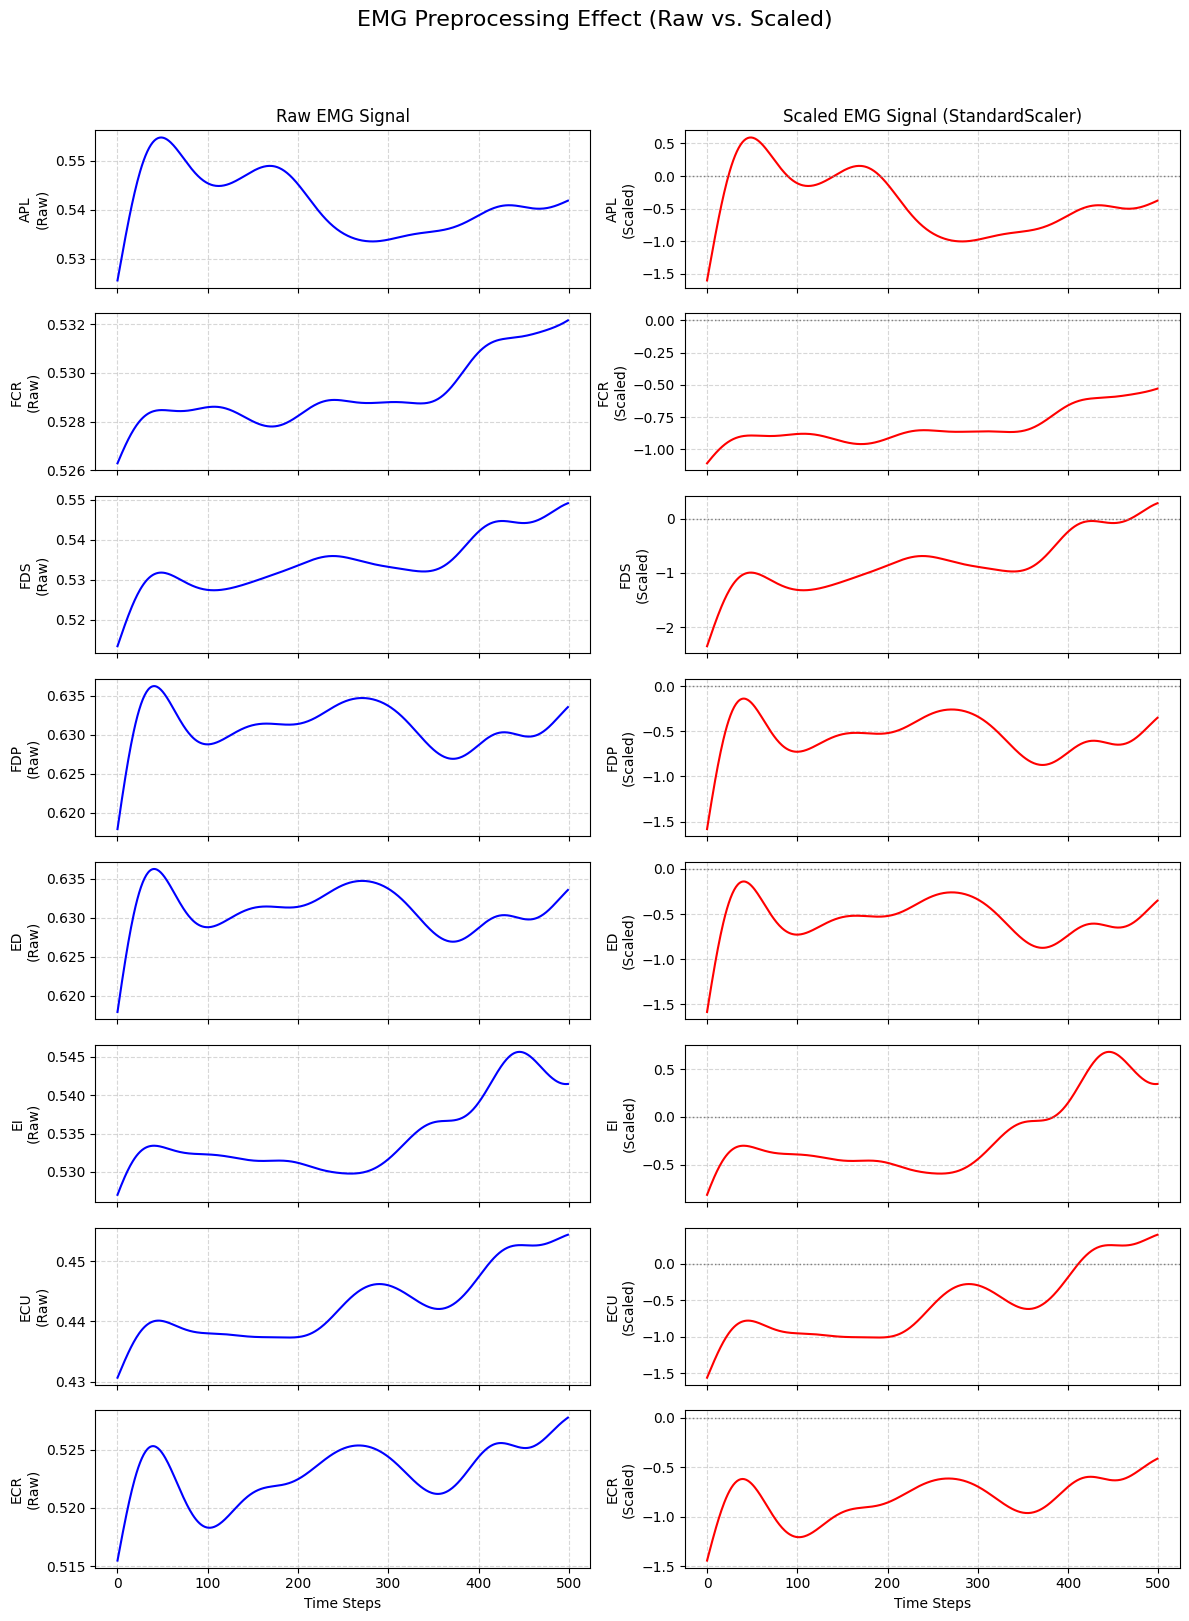


Preprocessing data for Kinematic Comparison Figure...
Processing data for the first 3 tasks.
Calculating mean trajectories (truncating to min length per task/joint)...
Preprocessing for kinematic figure complete. Max aligned length: 4000

Preprocessing data for Trial Analysis (ANOVA, Trial Changes)...
Processing data for the first 3 tasks.
Task 1: Found 5 valid trials for metric extraction.
Task 2: Found 5 valid trials for metric extraction.
Task 3: Found 5 valid trials for metric extraction.
Preprocessing for trial analysis complete.
Building MHA model...
MHA models built successfully.

--- Training Model Summary ---
Model: "Finger_MHA_Training_Model"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     Param #           Connected to                                      
 emg_input (InputLayer)             

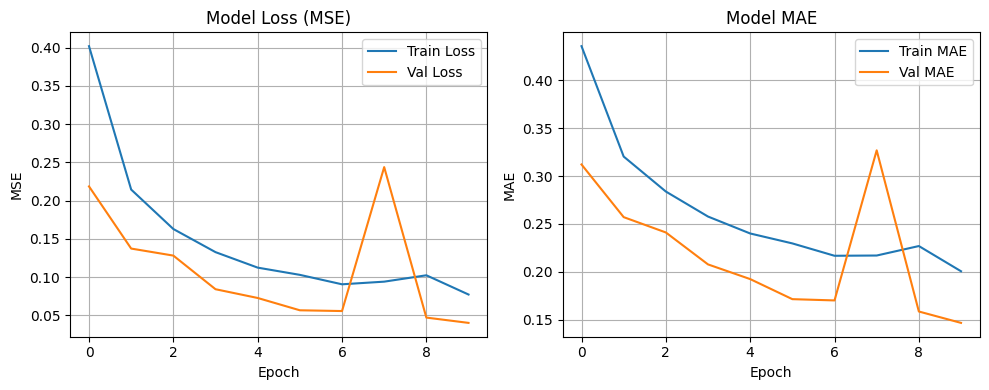


--- Performance Evaluation on Validation Set ---
208/208 [==============================] - 4s 16ms/step
Avg R2: 0.961, Avg CC: 0.981


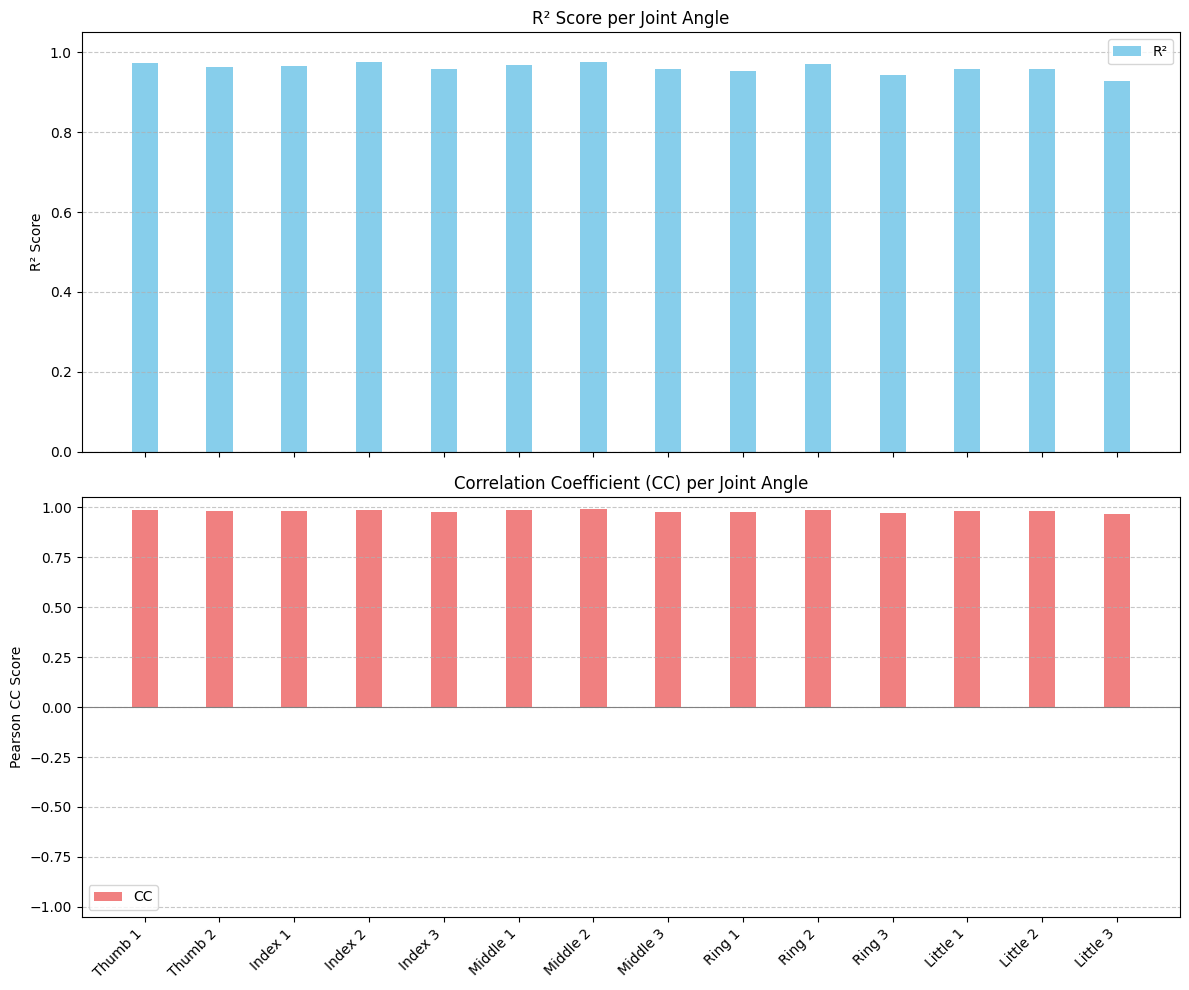

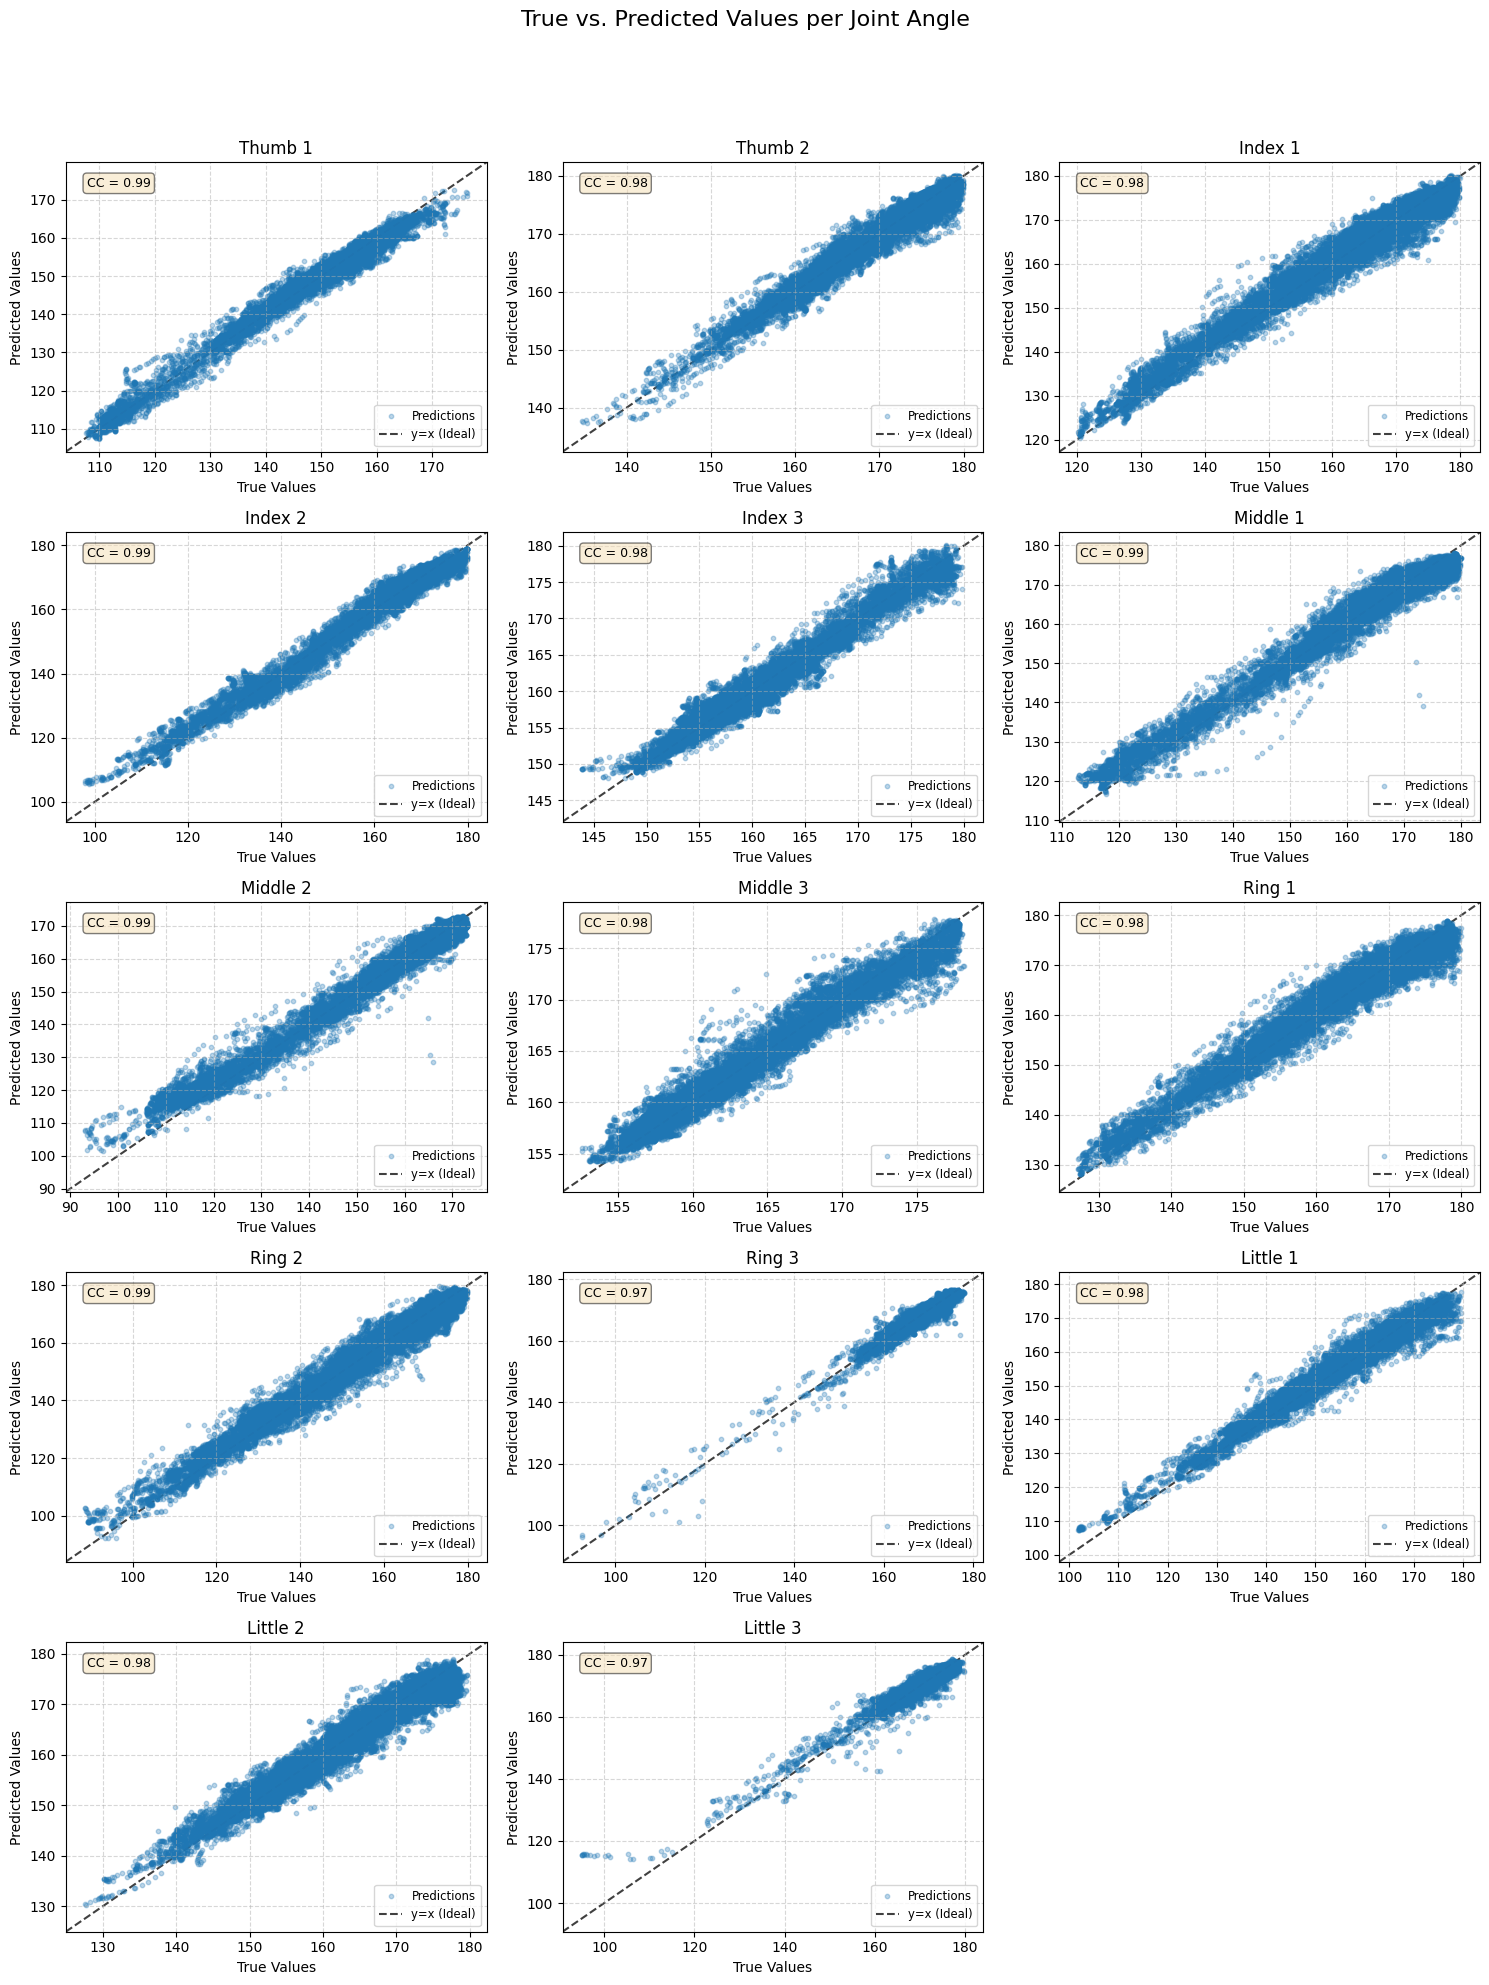


--- Detailed MHA Attention Visualization (Sample Windows) ---
Visualizing MHA attention for first 1 samples...


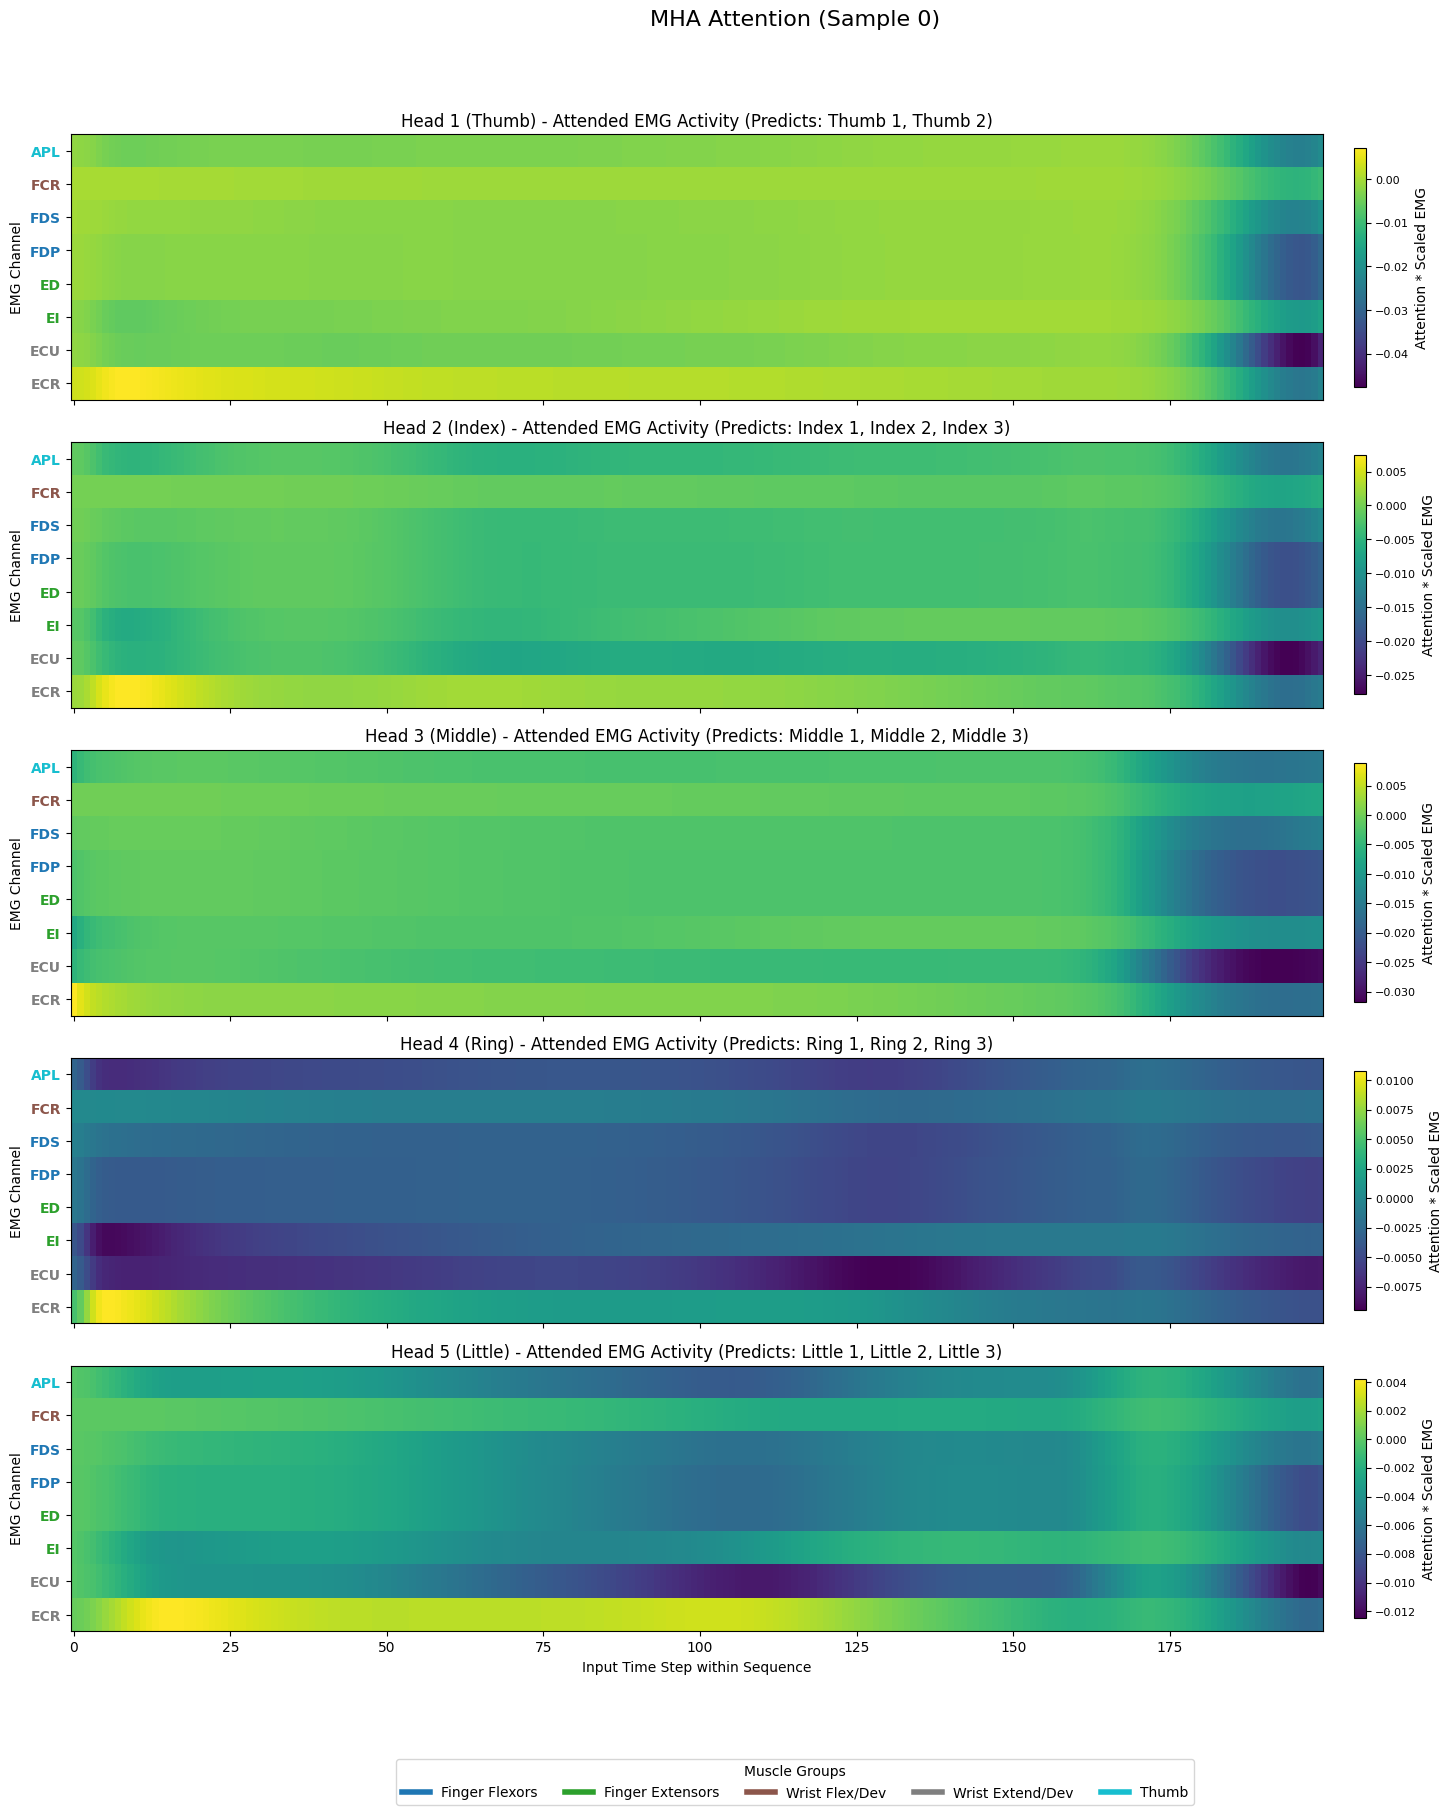


--- Dynamic Trial Simulation Visualization ---
Visualizing dynamics for first 1 trial(s)...

--- Plotting Dynamics Simulation for Trial: T1_Task1 ---
Running model prediction for simulation...
Extracting attention weights for simulation...


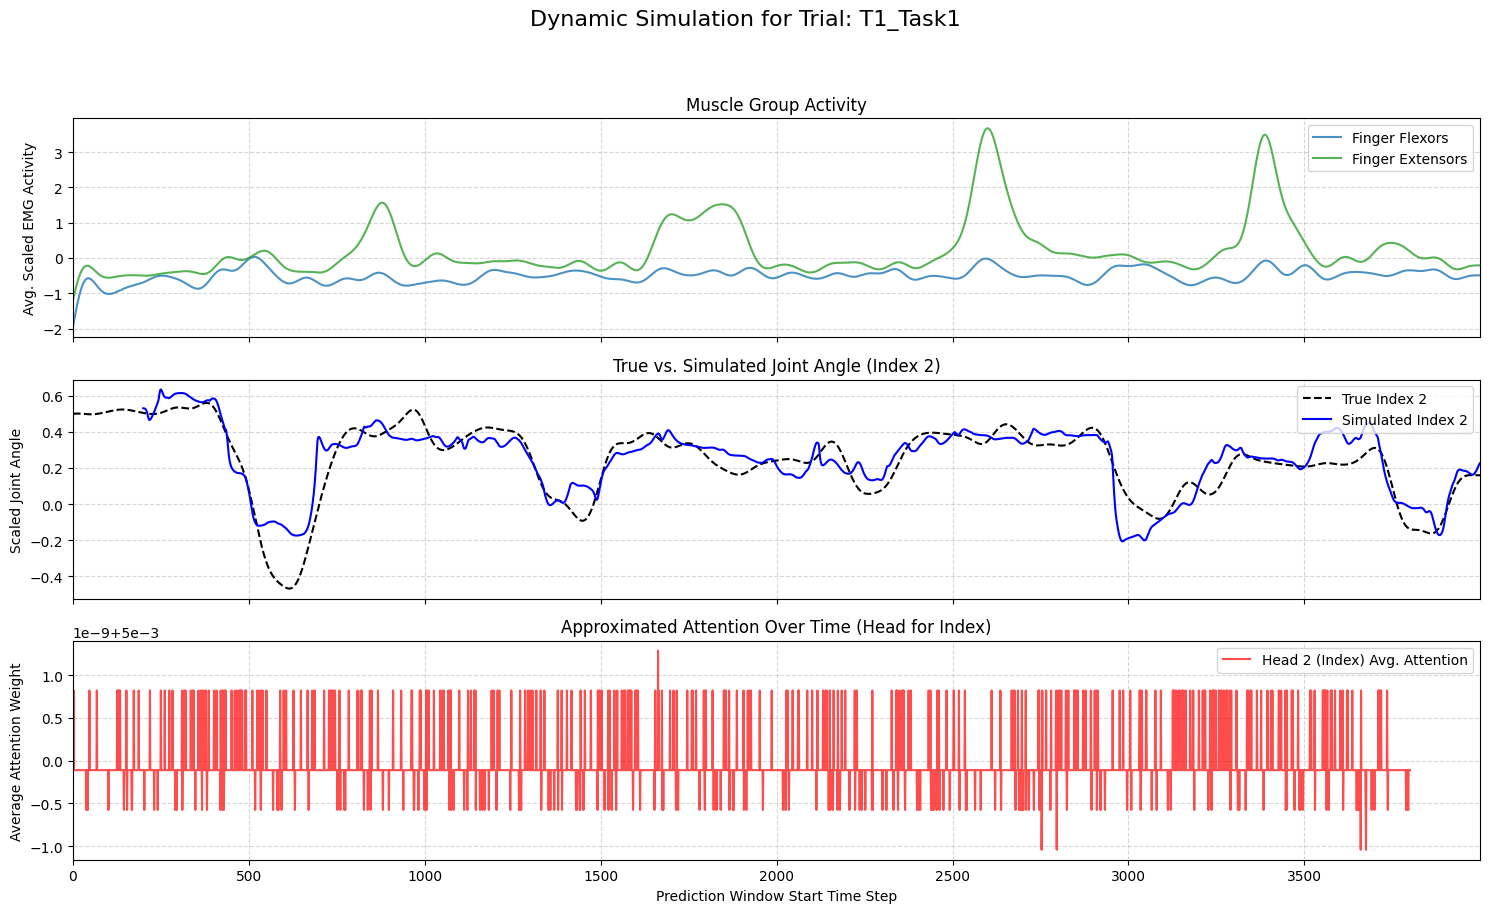


--- XAI & Biomechanics Visualization ---
Calculating & Visualizing for first 1 sample(s)...

--- Explaining Sample Index 0 ---
Explaining prediction for: Index 3 (Index 4)


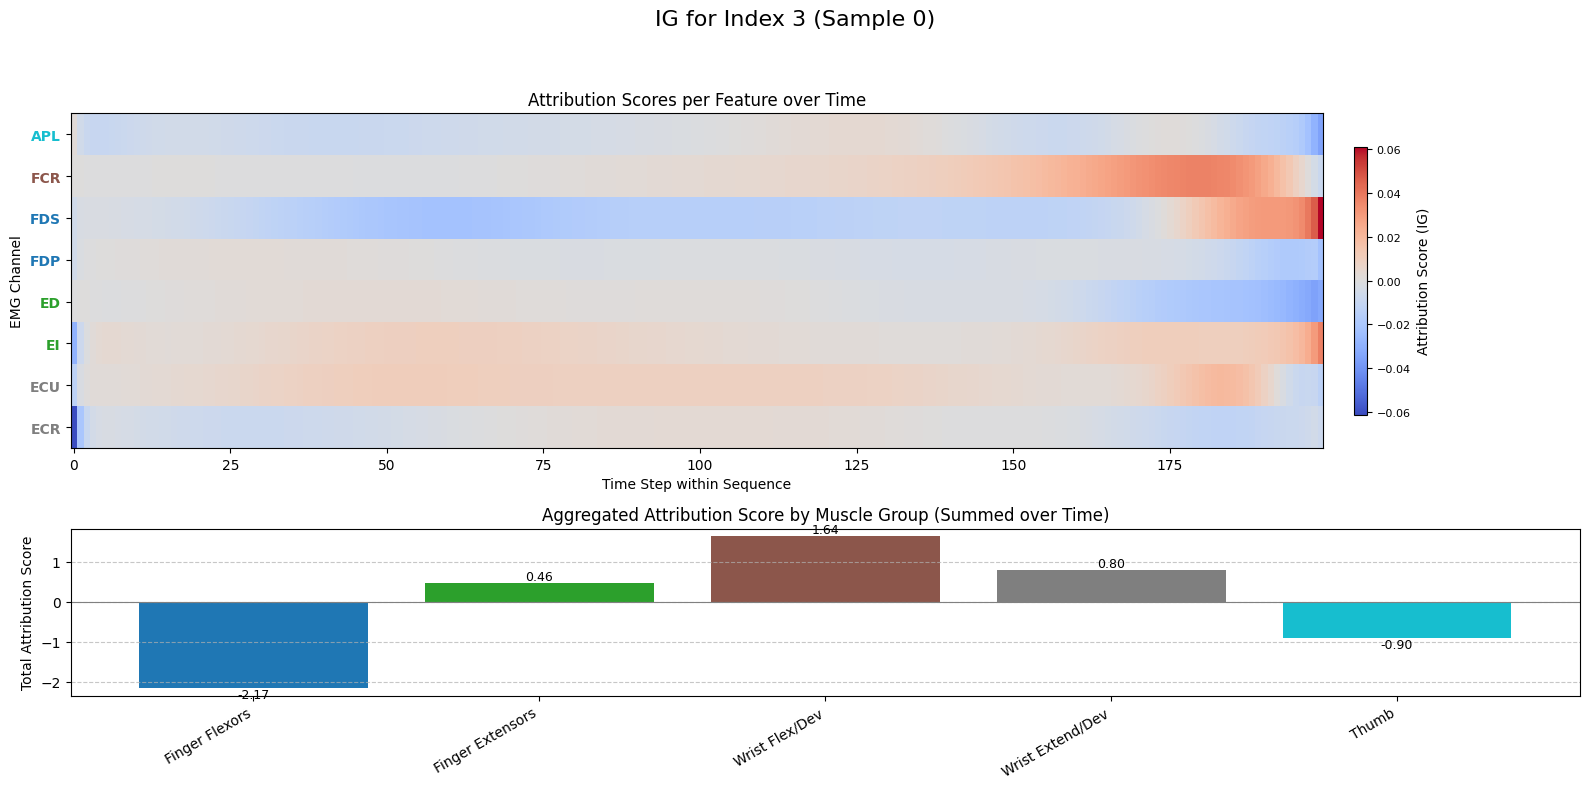

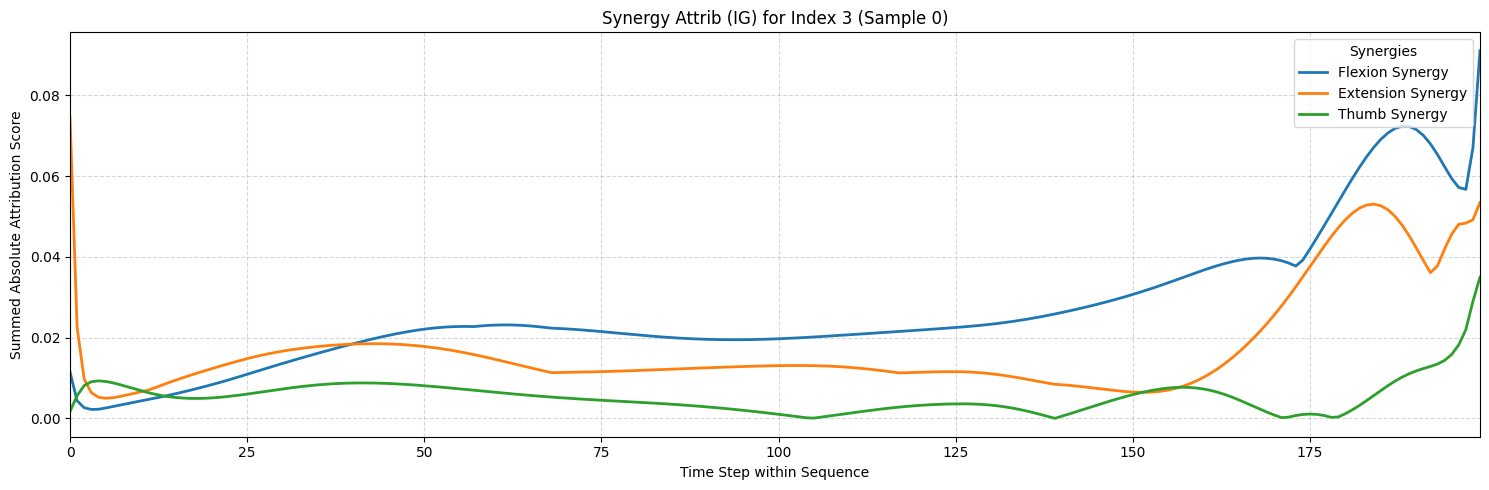

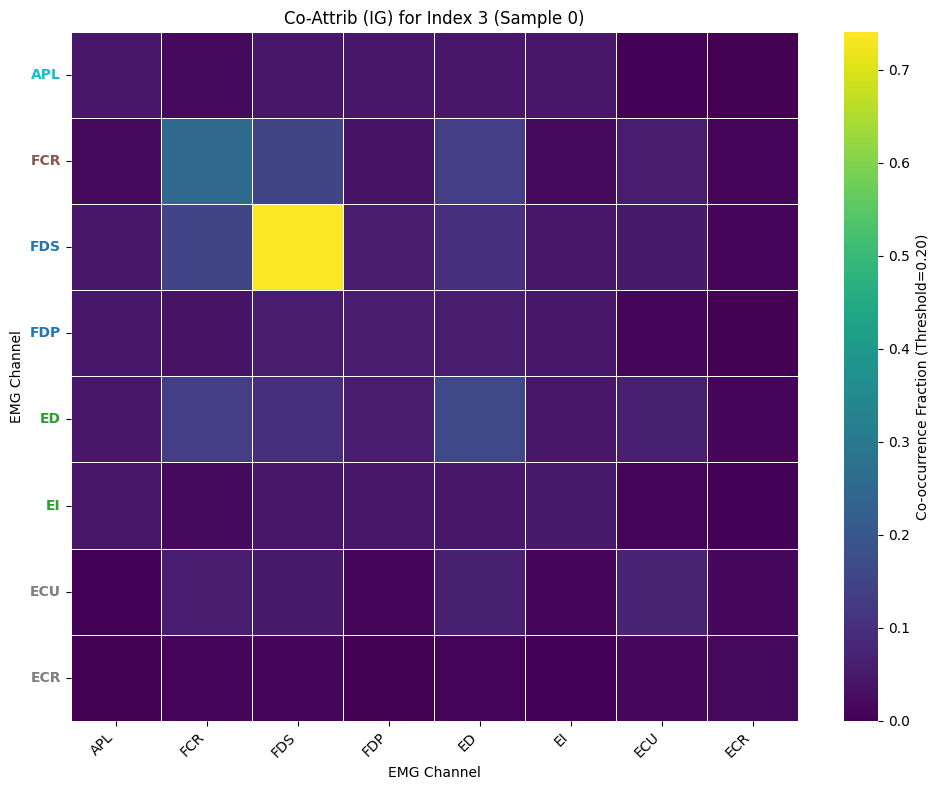


Plotting Full Validation Set Phase Space for Index 3...


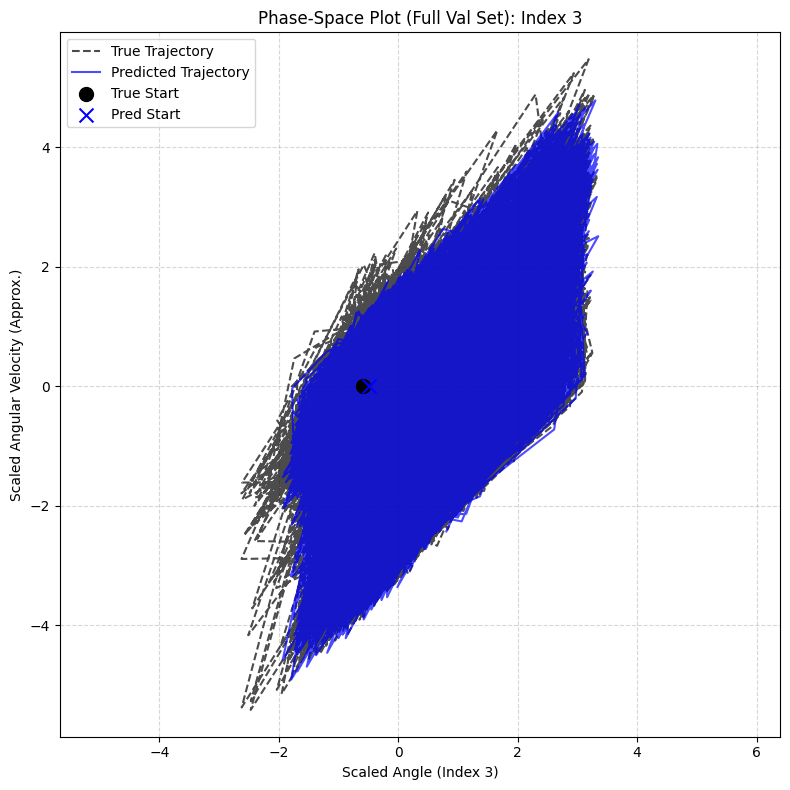

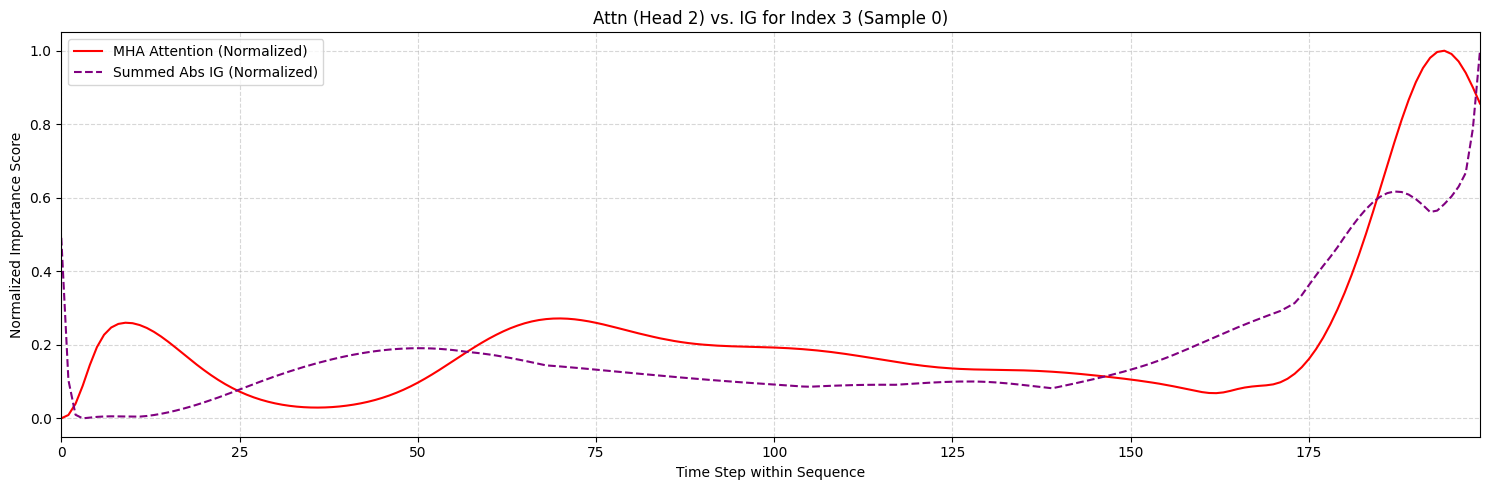


--- Plotting Actual Mean Kinematic Comparison Figure ---


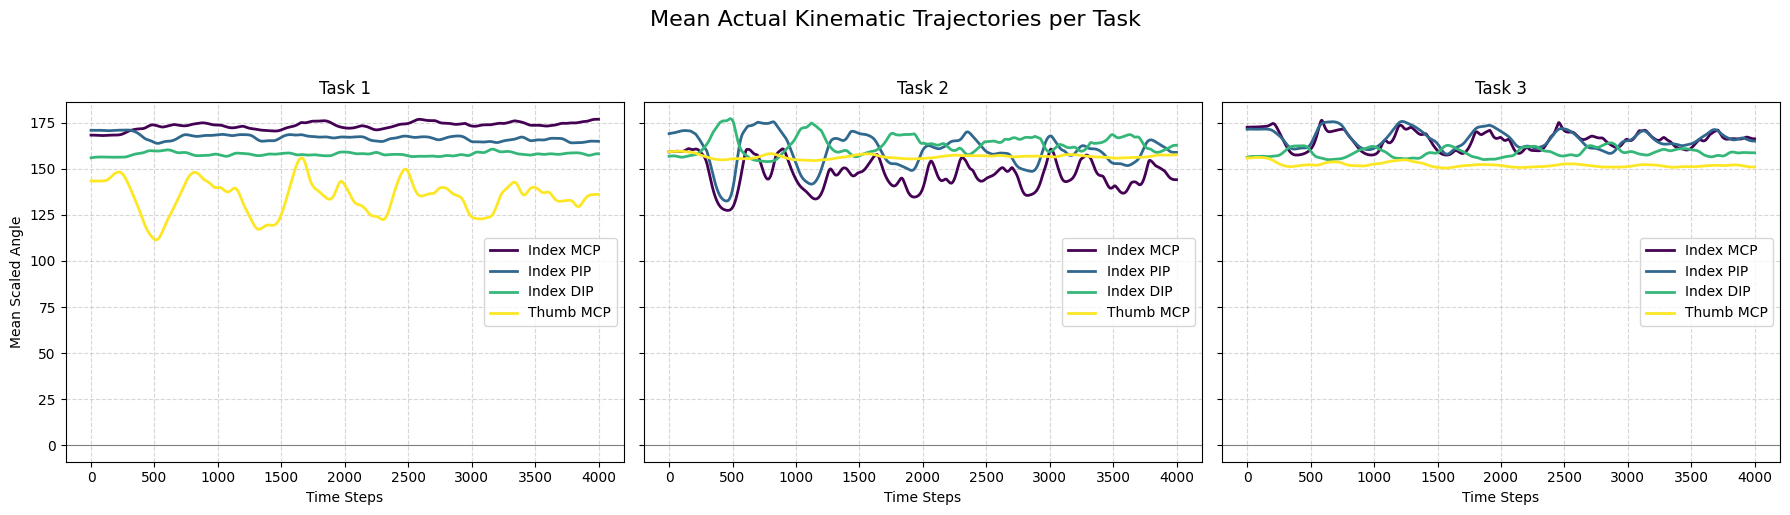


--- Plotting Predicted vs. Actual Mean Kinematics ---
Generating mean predictions from original trials...


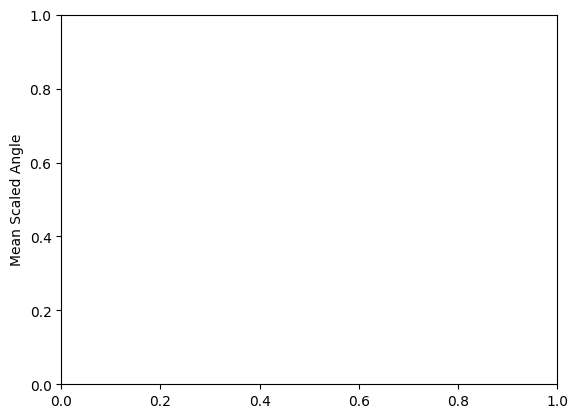

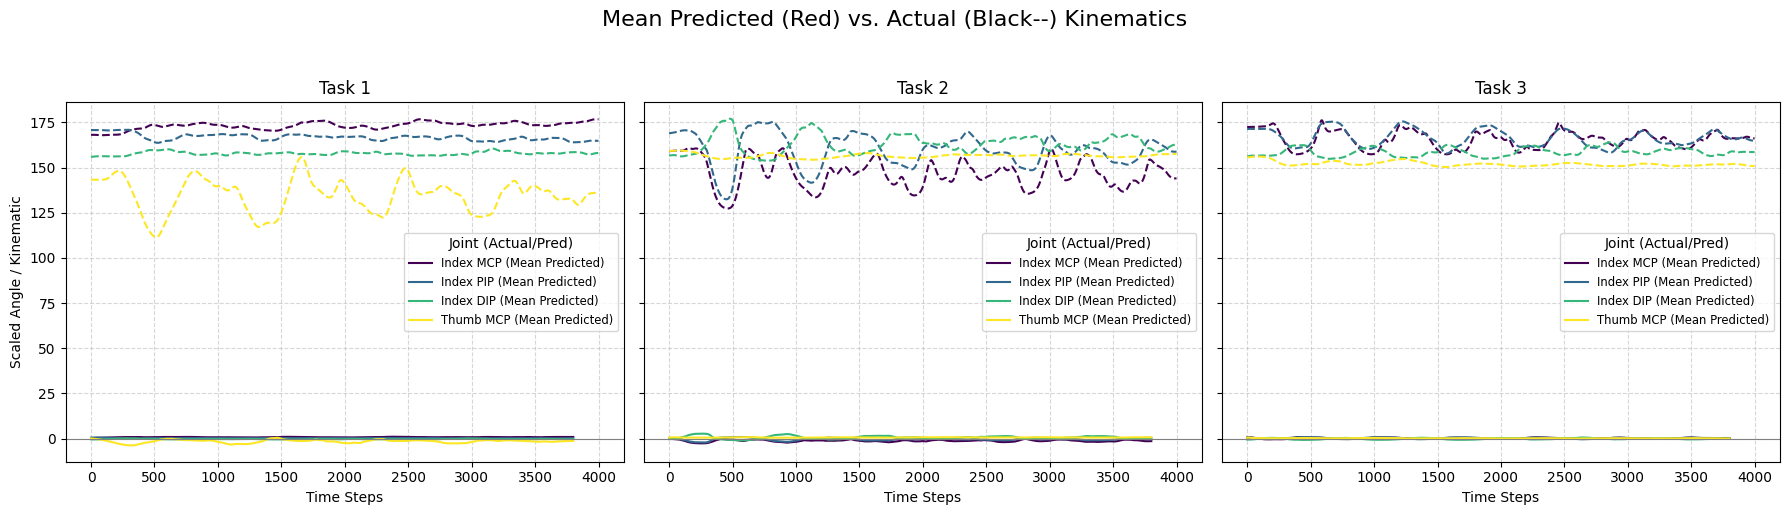


--- Plotting ANOVA Results ---

--- ANOVA Results for 'max_Index 2' across tasks ---
F-statistic: 69.883
P-value: 0.0000


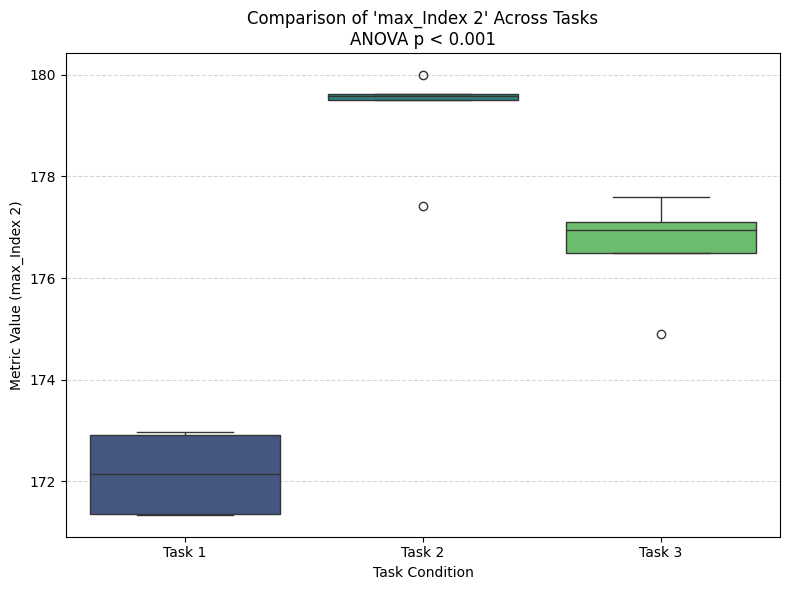


--- Plotting Trial-over-Trial Changes ---


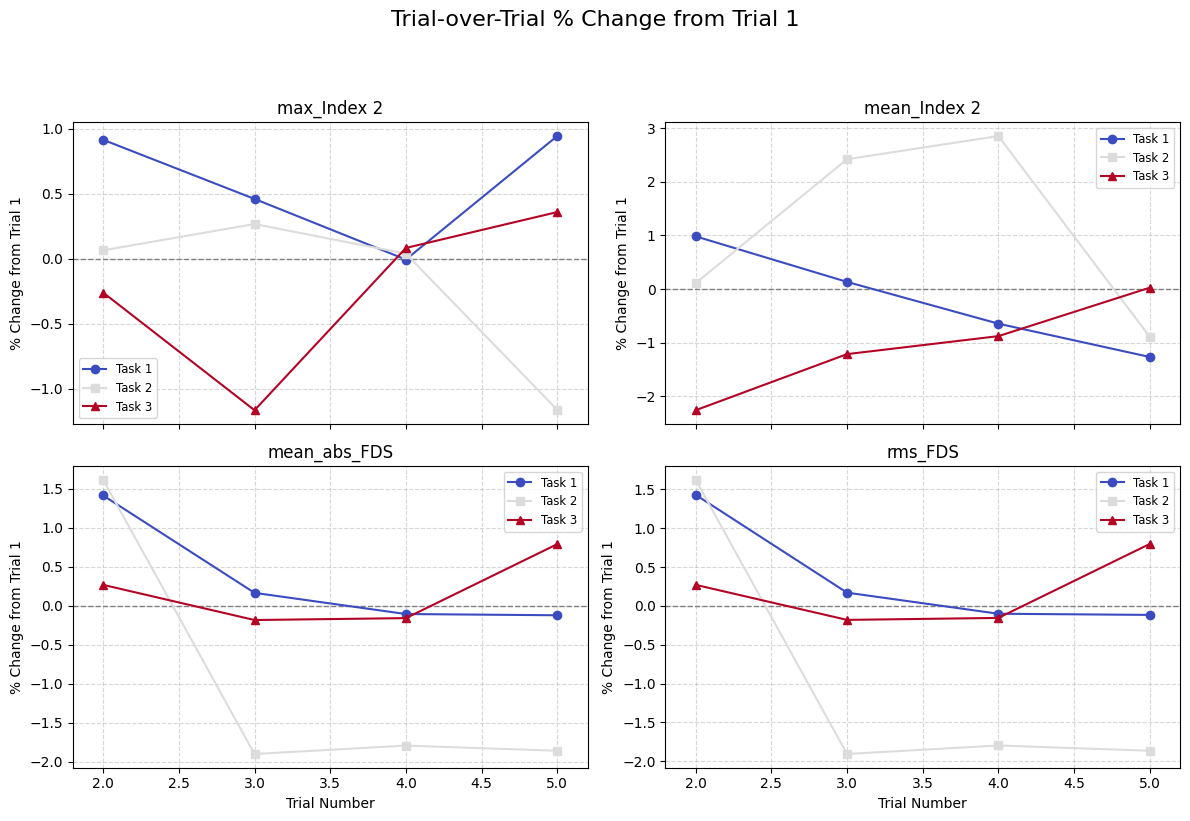


--- Script Execution Finished ---


In [4]:
# -*- coding: utf-8 -*-
"""
Python script for predicting finger kinematics from EMG using a
Multi-Head Attention (MHA) LSTM model with specific EMG preprocessing
and Integrated Gradients for XAI.

Includes:
- Custom MHA model with separate finger heads.
- R2/CC score plotting.
- Regression correlation scatter plots.
- MHA Attention Heatmap visualization (per head, normalized).
- Dynamic Simulation plot (EMG/True Angle/Predicted Angle/Attention).
- Integrated Gradients calculation and visualization.
- Synergy Attribution visualization (Temporal).
- Muscle Co-Attribution Matrix visualization.
- Phase-Space Plot (Angle vs. Velocity) for dynamics analysis.
- Attention vs. Integrated Gradients comparison plot.
- Kinematic Trajectory Comparison plot (Actual Mean).
- Preprocessing Effect visualization (Raw vs. Scaled EMG).
- Predicted vs. Actual Mean Kinematic Trajectories plot.
- Statistical Comparison (ANOVA example) across Tasks plot.
- Trial-over-Trial Change Visualization plot (Enhanced).

Error Fixes:
- Fixed NameError for sequence_length in prediction loop.
- Refactored get_gradients and added None check for IG calculation.
"""

import numpy as np
import scipy.io
import scipy.stats # For ANOVA
# Removed: from scipy.signal import butter, sosfiltfilt # For filtering
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Layer, Dropout, Lambda, LayerNormalization, MultiHeadAttention,
    Concatenate
)
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Keep StandardScaler
from sklearn.metrics import r2_score
import os
import warnings
import math
import pandas as pd # Added for co-attribution matrix & ANOVA viz
import seaborn as sns # Added for co-attribution matrix heatmap & ANOVA viz
from collections import defaultdict # Added for grouping trials by task

# --- Configuration ---
MAT_FILE_PATH = 's4_full.mat' # <<<--- IMPORTANT: Update this path
SEQUENCE_LENGTH = 200
PREDICTION_HORIZON = 1 # Keep as 1 for current model structure
BATCH_SIZE = 128
EPOCHS = 10 # Adjust as needed (can be increased for better performance)
LSTM_UNITS = 128
VALIDATION_SPLIT = 0.2
MAX_SAMPLES_TO_VIZ_MHA = 1 # Limit detailed MHA heatmap visualization output
NUM_TRIALS_TO_PLOT_DYNAMICS = 1 # Limit dynamic plot output
NUM_SAMPLES_FOR_XAI = 1 # How many samples to run XAI (set to 1 for faster run with new plots)
NUM_TASKS_TO_PLOT_KINEMATICS = 3 # How many tasks (columns) to show in the kinematic comparison plot
PREPROC_VIZ_TRIAL_INDEX = 0 # Which trial index (from valid trials) to use for preproc viz
PREPROC_VIZ_DURATION = 500 # How many time steps to show in preproc viz
ANOVA_METRIC_JOINT_NAME = 'Index 2' # Joint to use for ANOVA example (e.g., max angle)
TRIAL_CHANGE_JOINT_NAME = 'Index 2' # Joint to track changes over trials
TRIAL_CHANGE_EMG_NAME = 'FDS' # EMG channel to track changes over trials

# MHA Configuration
NUM_ATTENTION_HEADS = 5 # Should match number of fingers
D_MODEL = LSTM_UNITS
# Ensure D_MODEL is divisible by NUM_ATTENTION_HEADS
if D_MODEL % NUM_ATTENTION_HEADS != 0:
     D_MODEL = math.ceil(D_MODEL / NUM_ATTENTION_HEADS) * NUM_ATTENTION_HEADS
     print(f"Adjusting D_MODEL to {D_MODEL} to be divisible by {NUM_ATTENTION_HEADS} heads.")

# Integrated Gradients Config
IG_STEPS = 50 # Number of steps for approximation
CO_ATTRIBUTION_THRESHOLD = 0.2 # Threshold for co-attribution matrix calculation

# EMG Channel Names (Ensure these match your .mat file structure)
EMG_CHANNEL_NAMES = ['APL', 'FCR', 'FDS', 'FDP', 'ED', 'EI', 'ECU', 'ECR']
# Joint Angle Names (Ensure these match your .mat file structure)
JOINT_ANGLE_NAMES = [
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]
# Finger to Joint Mapping (Ensure this is correct for your angle data)
FINGER_JOINT_INDICES = {
    'Thumb': list(range(0, 2)),
    'Index': list(range(2, 5)), # Index 1=MCP, Index 2=PIP, Index 3=DIP (Example mapping)
    'Middle': list(range(5, 8)),
    'Ring': list(range(8, 11)),
    'Little': list(range(11, 14))
}
FINGER_NAMES = list(FINGER_JOINT_INDICES.keys())

# --- Muscle Group Definitions (for coloring/grouping) ---
MUSCLE_GROUPS = {
    'Finger Flexors': ['FDS', 'FDP'],
    'Finger Extensors': ['ED', 'EI'],
    'Wrist Flex/Dev': ['FCR'],
    'Wrist Extend/Dev': ['ECU', 'ECR'],
    'Thumb': ['APL']
}
# Map group names to indices
MUSCLE_GROUP_INDICES = {
    name: [EMG_CHANNEL_NAMES.index(ch) for ch in channels if ch in EMG_CHANNEL_NAMES]
    for name, channels in MUSCLE_GROUPS.items()
}
# Assign colors for visualization
try: cmap = plt.colormaps.get_cmap('tab10')
except AttributeError: cmap = plt.cm.get_cmap('tab10') # Fallback for older matplotlib
GROUP_COLORS = cmap(np.linspace(0, 1, len(MUSCLE_GROUPS)))
MUSCLE_GROUP_VIS_INFO = {name: {'indices': MUSCLE_GROUP_INDICES[name], 'color': GROUP_COLORS[i]}
                         for i, name in enumerate(MUSCLE_GROUPS.keys())}
print("Defined Muscle Groups (Indices):", MUSCLE_GROUP_INDICES)

# --- Define Synergies (Example - Adapt based on actual physiological knowledge) ---
SYNERGIES = {
    'Flexion Synergy': ['FCR', 'FDS', 'FDP'], # Example: Wrist/Finger Flexors
    'Extension Synergy': ['ED', 'ECU', 'ECR'], # Example: Finger/Wrist Extensors
    'Thumb Synergy': ['APL'] # Example: Thumb Abduction/Extension
}
# Map synergy names to EMG channel indices
SYNERGY_INDICES = {
    name: [EMG_CHANNEL_NAMES.index(ch) for ch in channels if ch in EMG_CHANNEL_NAMES]
    for name, channels in SYNERGIES.items()
}
print("Defined Synergies (Indices):", SYNERGY_INDICES)

# --- Custom Multi-Head Attention Layer ---
# (Same as previous version)
class CustomMultiHeadAttentionSeparateOutput(Layer):
    """ Custom MHA layer returning separate context vectors per head. """
    def __init__(self, num_heads, d_model, **kwargs):
        super().__init__(**kwargs)
        if d_model % num_heads != 0: raise ValueError(f"d_model ({d_model}) must be divisible by num_heads ({num_heads})")
        self.num_heads = num_heads; self.d_model = d_model; self.depth = d_model // num_heads
        self.wq = Dense(d_model, name='q_proj'); self.wk = Dense(d_model, name='k_proj'); self.wv = Dense(d_model, name='v_proj')
    def split_heads(self, x, batch_size): x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth)); return tf.transpose(x, perm=[0, 2, 1, 3])
    def scaled_dot_product_attention(self, q, k, v, mask=None):
        matmul_qk = tf.matmul(q, k, transpose_b=True); dk = tf.cast(tf.shape(k)[-1], tf.float32); scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        if mask is not None: scaled_attention_logits += (mask * -1e9)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1); output = tf.matmul(attention_weights, v); return output, attention_weights
    def call(self, query, value, key, mask=None, return_attention_scores=False):
        batch_size = tf.shape(query)[0]; q = self.wq(query); k = self.wk(key); v = self.wv(value)
        q = self.split_heads(q, batch_size); k = self.split_heads(k, batch_size); v = self.split_heads(v, batch_size)
        scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask); scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        head_outputs = [scaled_attention[:, :, i, :] for i in range(self.num_heads)]
        if query.shape[1] == 1: head_outputs_squeezed = [tf.squeeze(head, axis=1) for head in head_outputs]
        else: head_outputs_squeezed = head_outputs
        if query.shape[1] == 1: squeezed_attention_weights = tf.squeeze(attention_weights, axis=2)
        else: squeezed_attention_weights = attention_weights
        if return_attention_scores: return head_outputs_squeezed, squeezed_attention_weights
        else: return head_outputs_squeezed
    def get_config(self): config = super().get_config(); config.update({'num_heads': self.num_heads, 'd_model': self.d_model}); return config

# --- 1. Data Loading ---
# (Same as previous version)
def load_mat_data(filepath):
    """Loads EMG and joint angle data from the specified .mat file."""
    print(f"Loading data from: {filepath}")
    if not os.path.exists(filepath): print(f"Error: File not found at {filepath}"); return None, None, None, None
    try:
        mat_data = scipy.io.loadmat(filepath); emg_data_cells = mat_data.get('dsfilt_emg', mat_data.get('emg_data'))
        joint_angles_cells = mat_data.get('joint_angles', mat_data.get('angle_data')); kinematics_data = mat_data.get('finger_kinematics', None)
        displacement_data_cells = mat_data.get('displacement_data', None)
        if emg_data_cells is None or joint_angles_cells is None: print("Error: Could not find EMG or angle data."); return None, None, None, None
        print("Data loaded successfully."); return emg_data_cells, joint_angles_cells, kinematics_data, displacement_data_cells
    except Exception as e: print(f"An error occurred during loading: {e}"); return None, None, None, None

# --- 2. Data Preprocessing ---
# (Same as previous version - returns raw/scaled EMG for viz)
def preprocess_data(emg_data_cells, joint_angles_cells, sequence_length, prediction_horizon,
                    viz_trial_index=0, viz_duration=500):
    """ Preprocesses data for LSTM training and returns raw/scaled EMG segments for visualization. """
    print("Preprocessing data for LSTM training...")
    all_emg_sequences, all_angle_targets = [], []; original_scaled_trials = []
    emg_raw_segment_for_viz, emg_scaled_segment_for_viz = None, None
    num_trials, num_tasks = emg_data_cells.shape
    emg_scaler = StandardScaler(); angle_scaler = StandardScaler()
    print("Fitting scalers..."); emg_list_for_scaling = []; angle_list_for_scaling = []; valid_trial_global_indices = []
    for i in range(num_trials):
        for j in range(num_tasks):
            valid_emg = isinstance(emg_data_cells[i, j], np.ndarray) and emg_data_cells[i, j].ndim == 2 and emg_data_cells[i, j].shape[0] > 0
            valid_angle = isinstance(joint_angles_cells[i, j], np.ndarray) and joint_angles_cells[i, j].ndim == 2 and joint_angles_cells[i, j].shape[0] > 0
            if valid_emg and valid_angle:
                min_len = min(emg_data_cells[i,j].shape[0], joint_angles_cells[i,j].shape[0])
                if min_len >= sequence_length + prediction_horizon + 5: # Use global SEQUENCE_LENGTH
                    trial_emg = emg_data_cells[i, j][:min_len, :]; trial_angle = joint_angles_cells[i, j][:min_len, :]
                    if not np.any(np.isnan(trial_emg)) and not np.any(np.isinf(trial_emg)) and not np.any(np.isnan(trial_angle)) and not np.any(np.isinf(trial_angle)):
                        emg_list_for_scaling.append(trial_emg); angle_list_for_scaling.append(trial_angle); valid_trial_global_indices.append((i, j))
    if not emg_list_for_scaling: print("Error: No valid data found for scaling."); return None, None, None, None, None, None, None, None, None
    full_emg_data = np.vstack(emg_list_for_scaling); full_angle_data = np.vstack(angle_list_for_scaling)
    emg_scaler.fit(full_emg_data); angle_scaler.fit(full_angle_data); print("Scalers fitted.")
    print(f"Creating sequences from {len(valid_trial_global_indices)} valid trials..."); trial_count = 0; viz_trial_found = False
    for current_valid_idx, (i, j) in enumerate(valid_trial_global_indices):
        trial_emg_raw = emg_list_for_scaling[current_valid_idx]; trial_angle_raw = angle_list_for_scaling[current_valid_idx]
        trial_emg_scaled = emg_scaler.transform(trial_emg_raw); trial_angle_scaled = angle_scaler.transform(trial_angle_raw)
        if not viz_trial_found and current_valid_idx == viz_trial_index:
            print(f"Capturing preprocessing viz data from trial index {current_valid_idx} (Original: {i},{j})")
            segment_len = min(viz_duration, trial_emg_raw.shape[0])
            emg_raw_segment_for_viz = trial_emg_raw[:segment_len, :]; emg_scaled_segment_for_viz = trial_emg_scaled[:segment_len, :]; viz_trial_found = True
        original_scaled_trials.append({'emg': trial_emg_scaled, 'angle': trial_angle_scaled, 'id': f"T{i+1}_Task{j+1}"})
        # Use global SEQUENCE_LENGTH here too
        for k in range(len(trial_emg_scaled) - SEQUENCE_LENGTH - prediction_horizon + 1):
            emg_sequence = trial_emg_scaled[k : k + SEQUENCE_LENGTH]; angle_target = trial_angle_scaled[k + SEQUENCE_LENGTH : k + SEQUENCE_LENGTH + prediction_horizon]
            if prediction_horizon == 1: angle_target = angle_target.squeeze(axis=0)
            all_emg_sequences.append(emg_sequence); all_angle_targets.append(angle_target)
        trial_count += 1
    if not all_emg_sequences: print("Error: Could not create sequences."); return None, None, None, None, None, None, None, None, None
    X = np.array(all_emg_sequences); y = np.array(all_angle_targets); print(f"Created {X.shape[0]} sequences from {trial_count} trials.")
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VALIDATION_SPLIT, random_state=42, shuffle=True)
    print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}")
    if not viz_trial_found: print(f"Warning: Could not find trial index {viz_trial_index} for preprocessing viz.")
    return X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials, emg_raw_viz, emg_scaled_viz


# --- Preprocessing for Kinematic Comparison Figure ---
# (Same as previous version)
def preprocess_for_kinematic_figure(kinematic_data_cells, num_tasks_to_use, angle_names, target_kinematic_indices):
    """ Groups kinematic data by task, calculates mean trajectories. """
    print(f"\nPreprocessing data for Kinematic Comparison Figure...")
    if kinematic_data_cells is None: print("Error: Kinematic data is None."); return None, 0
    num_trials, num_total_tasks = kinematic_data_cells.shape; num_tasks = min(num_tasks_to_use, num_total_tasks)
    print(f"Processing data for the first {num_tasks} tasks.")
    task_data = defaultdict(lambda: defaultdict(list)); max_len = 0
    for task_idx in range(num_tasks):
        for trial_idx in range(num_trials):
            kin_trial_task = kinematic_data_cells[trial_idx, task_idx]
            if isinstance(kin_trial_task, np.ndarray) and kin_trial_task.ndim == 2 and kin_trial_task.shape[0] > 0:
                 if not np.any(np.isnan(kin_trial_task)) and not np.any(np.isinf(kin_trial_task)):
                    trial_len = kin_trial_task.shape[0]; max_len = max(max_len, trial_len)
                    for joint_label, data_index in target_kinematic_indices.items():
                        if 0 <= data_index < kin_trial_task.shape[1]: task_data[task_idx][joint_label].append(kin_trial_task[:, data_index])
    if not task_data: print("Error: No valid kinematic data found after grouping."); return None, 0
    mean_task_data = defaultdict(dict); final_max_len = 0
    print("Calculating mean trajectories (truncating to min length per task/joint)...")
    for task_idx, joint_dict in task_data.items():
        for joint_label, trajectories in joint_dict.items():
            if not trajectories: continue
            min_len_group = min(len(t) for t in trajectories); final_max_len = max(final_max_len, min_len_group)
            truncated_trajectories = [t[:min_len_group] for t in trajectories]; stacked_trajectories = np.stack(truncated_trajectories, axis=0)
            mean_trajectory = np.mean(stacked_trajectories, axis=0); mean_task_data[task_idx][joint_label] = mean_trajectory
    print(f"Preprocessing for kinematic figure complete. Max aligned length: {final_max_len}")
    return mean_task_data, final_max_len


# --- Preprocessing for Trial-over-Trial and ANOVA (Enhanced) ---
def preprocess_for_trial_analysis(emg_data_cells, kinematic_data_cells, num_tasks_to_use,
                                  emg_channel_names, kinematic_names,
                                  target_emg_names, target_kinematic_names): # Accept lists
    """
    Extracts multiple metrics per trial within each task for ANOVA and trial-change analysis.
    Args:
        emg_data_cells, kinematic_data_cells: Raw data cells.
        num_tasks_to_use: Max number of tasks to process.
        emg_channel_names, kinematic_names: Lists of names.
        target_emg_names, target_kinematic_names: Lists of specific features to extract metrics for.
    Returns:
        Dictionary {task_id: {metric_name: [trial1_val, trial2_val,...]}}
        Returns None if data is invalid.
    """
    print(f"\nPreprocessing data for Trial Analysis (ANOVA, Trial Changes)...")
    if kinematic_data_cells is None or emg_data_cells is None:
        print("Error: EMG or Kinematic data is None.")
        return None

    # Find indices for target features
    target_kin_indices = {}
    for name in target_kinematic_names:
        try: target_kin_indices[name] = kinematic_names.index(name)
        except ValueError: print(f"Warning: Target kinematic '{name}' not found in names. Skipping.")
    target_emg_indices = {}
    for name in target_emg_names:
        try: target_emg_indices[name] = emg_channel_names.index(name)
        except ValueError: print(f"Warning: Target EMG '{name}' not found in names. Skipping.")

    if not target_kin_indices and not target_emg_indices:
        print("Error: No valid target features found for trial analysis.")
        return None

    num_trials, num_total_tasks = kinematic_data_cells.shape
    num_tasks = min(num_tasks_to_use, num_total_tasks)
    print(f"Processing data for the first {num_tasks} tasks.")

    trial_metrics_by_task = defaultdict(lambda: defaultdict(list))

    for task_idx in range(num_tasks):
        num_valid_trials_thistask = 0
        for trial_idx in range(num_trials):
            kin_trial = kinematic_data_cells[trial_idx, task_idx]
            emg_trial = emg_data_cells[trial_idx, task_idx]

            # Basic validity checks
            valid_kin = isinstance(kin_trial, np.ndarray) and kin_trial.ndim == 2 and kin_trial.shape[0] > 1
            valid_emg = isinstance(emg_trial, np.ndarray) and emg_trial.ndim == 2 and emg_trial.shape[0] > 1

            if valid_kin and valid_emg:
                 if not np.any(np.isnan(kin_trial)) and not np.any(np.isinf(kin_trial)) and \
                    not np.any(np.isnan(emg_trial)) and not np.any(np.isinf(emg_trial)):

                    # Calculate metrics for this trial
                    valid_trial_processed = False
                    for name, kin_idx in target_kin_indices.items():
                        if kin_idx < kin_trial.shape[1]:
                             # Example metrics: Max angle, Mean angle
                             trial_metrics_by_task[task_idx][f'max_{name}'].append(np.max(kin_trial[:, kin_idx]))
                             trial_metrics_by_task[task_idx][f'mean_{name}'].append(np.mean(kin_trial[:, kin_idx]))
                             valid_trial_processed = True

                    for name, emg_idx in target_emg_indices.items():
                         if emg_idx < emg_trial.shape[1]:
                              # Example metrics: Mean absolute EMG, RMS EMG
                              trial_metrics_by_task[task_idx][f'mean_abs_{name}'].append(np.mean(np.abs(emg_trial[:, emg_idx])))
                              trial_metrics_by_task[task_idx][f'rms_{name}'].append(np.sqrt(np.mean(np.square(emg_trial[:, emg_idx]))))
                              valid_trial_processed = True

                    if valid_trial_processed:
                         num_valid_trials_thistask += 1

        print(f"Task {task_idx+1}: Found {num_valid_trials_thistask} valid trials for metric extraction.")


    if not trial_metrics_by_task:
        print("Error: No valid trial metrics extracted.")
        return None

    # Ensure all lists within a task have the same length
    for task_idx in list(trial_metrics_by_task.keys()): # Iterate over keys copy
        metric_dict = trial_metrics_by_task[task_idx]
        if not metric_dict: # Remove task if no metrics were extracted
             del trial_metrics_by_task[task_idx]
             continue
        list_lens = [len(v) for v in metric_dict.values()]
        if len(set(list_lens)) > 1:
             min_len = min(list_lens) if list_lens else 0
             print(f"Warning: Inconsistent trial counts for metrics in task {task_idx}. Truncating to {min_len} trials.")
             for metric_name in metric_dict:
                  metric_dict[metric_name] = metric_dict[metric_name][:min_len]
        # Remove task if no trials remain after truncation/check
        if not any(len(v) > 0 for v in metric_dict.values()):
             print(f"Removing Task {task_idx} from analysis due to lack of consistent trial data.")
             del trial_metrics_by_task[task_idx]


    print("Preprocessing for trial analysis complete.")
    return dict(trial_metrics_by_task)


# --- 3. Model Architecture ---
# (Same as previous version)
def build_finger_mha_lstm(sequence_length, num_emg_features, num_angle_features,
                          lstm_units, d_model, num_heads, finger_joint_indices):
    """ Builds LSTM with Custom MHA and separate finger prediction heads. """
    print("Building MHA model...")
    if num_heads != len(finger_joint_indices): raise ValueError("Number of heads must match number of fingers defined.")
    encoder_inputs = Input(shape=(sequence_length, num_emg_features), name='emg_input')
    encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, name='encoder_lstm')
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
    encoder_outputs_norm = LayerNormalization(epsilon=1e-6)(encoder_outputs); state_h_norm = LayerNormalization(epsilon=1e-6)(state_h)
    query = Lambda(lambda x: tf.expand_dims(x, axis=1), name='expand_query_dim')(state_h_norm); value = encoder_outputs_norm; key = encoder_outputs_norm
    mha_layer = CustomMultiHeadAttentionSeparateOutput(num_heads=num_heads, d_model=d_model, name='custom_mha')
    head_context_vectors, attention_weights = mha_layer(query=query, value=value, key=key, return_attention_scores=True)
    finger_outputs = []; finger_names = list(finger_joint_indices.keys())
    for i in range(num_heads):
        finger_name = finger_names[i]; num_finger_joints = len(finger_joint_indices[finger_name]); head_context = head_context_vectors[i]
        finger_dense1 = Dense(32, activation='relu', name=f'{finger_name}_dense1')(head_context); finger_dropout = Dropout(0.2, name=f'{finger_name}_dropout')(finger_dense1)
        finger_output = Dense(num_finger_joints, activation='linear', name=f'{finger_name}_output')(finger_dropout); finger_outputs.append(finger_output)
    final_output = Concatenate(axis=-1, name='final_concatenated_output')(finger_outputs)
    model = Model(inputs=encoder_inputs, outputs=final_output, name='Finger_MHA_Training_Model')
    attention_model = Model(inputs=encoder_inputs, outputs=attention_weights, name='Finger_MHA_Attention_Model')
    print("MHA models built successfully."); return model, attention_model

# --- 4. Training ---
# (Same as previous version)
def train_model(model, X_train, y_train, X_val, y_val, epochs, batch_size):
    """ Compiles and trains the model. """
    print("Compiling model..."); model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    print("Starting training..."); early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=1)
    print("Training finished."); return history

# --- 5. Performance Evaluation & Visualization ---
# (Same as previous version - includes plot_performance_scores, plot_regression_correlation)
def calculate_performance_scores(y_true, y_pred):
    """ Calculates R2 and Pearson CC scores for each output feature. """
    if y_true.shape != y_pred.shape: raise ValueError(f"Shape mismatch: y_true {y_true.shape}, y_pred {y_pred.shape}")
    if y_true.ndim != 2: raise ValueError(f"Expected 2D arrays, got shapes: y_true {y_true.shape}, y_pred {y_pred.shape}")
    num_features = y_true.shape[1]; r2_scores_list, cc_scores_list, cc_pvalues_list = [], [], []
    for i in range(num_features):
        r2 = r2_score(y_true[:, i], y_pred[:, i]); r2_scores_list.append(r2)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            cc, p_value = scipy.stats.pearsonr(y_true[:, i], y_pred[:, i])
            if np.isnan(cc): cc, p_value = 0.0, 1.0
        cc_scores_list.append(cc); cc_pvalues_list.append(p_value)
    return np.array(r2_scores_list), np.array(cc_scores_list), np.array(cc_pvalues_list)

def plot_performance_scores(r2_scores, cc_scores, angle_names):
    """ Creates bar plots for R2 and CC scores per joint angle. """
    num_angles = len(angle_names)
    if num_angles != len(r2_scores) or num_angles != len(cc_scores):
        print("Warning: Mismatch between number of angles and scores. Adjusting plot.")
        num_angles = min(len(r2_scores), len(cc_scores)); angle_names = angle_names[:num_angles]
        r2_scores = r2_scores[:num_angles]; cc_scores = cc_scores[:num_angles]
    x = np.arange(num_angles); width = 0.35; fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    rects1 = ax1.bar(x, r2_scores, width, label='R²', color='skyblue'); ax1.set_ylabel('R² Score'); ax1.set_title('R² Score per Joint Angle')
    min_r2 = min(0, np.min(r2_scores) - 0.1 if r2_scores.size > 0 else 0); ax1.set_ylim(min_r2, 1.05); ax1.axhline(0, color='grey', lw=0.8)
    ax1.legend(); ax1.grid(axis='y', linestyle='--', alpha=0.7)
    rects2 = ax2.bar(x, cc_scores, width, label='CC', color='lightcoral'); ax2.set_ylabel('Pearson CC Score'); ax2.set_title('Correlation Coefficient (CC) per Joint Angle')
    ax2.set_xticks(x); ax2.set_xticklabels(angle_names, rotation=45, ha='right'); ax2.set_ylim(-1.05, 1.05); ax2.axhline(0, color='grey', lw=0.8)
    ax2.legend(); ax2.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout(); plt.show()

def plot_regression_correlation(y_true, y_pred, angle_names, cc_scores=None):
    """ Creates scatter plots for true vs predicted values for each angle. """
    num_angles = y_true.shape[1]
    if num_angles != len(angle_names): angle_names = [f"Angle {i+1}" for i in range(num_angles)]
    ncols = 3; nrows = math.ceil(num_angles / ncols); fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=False, sharey=False)
    axes = axes.flatten()
    for i in range(num_angles):
        ax = axes[i]; true_vals = y_true[:, i]; pred_vals = y_pred[:, i]
        ax.scatter(true_vals, pred_vals, alpha=0.3, s=10, label='Predictions')
        min_val = min(np.min(true_vals), np.min(pred_vals)); max_val = max(np.max(true_vals), np.max(pred_vals))
        padding = (max_val - min_val) * 0.05; lims = [min_val - padding, max_val + padding]
        ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='y=x (Ideal)'); ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("True Values"); ax.set_ylabel("Predicted Values"); ax.set_title(f"{angle_names[i]}")
        ax.grid(True, linestyle='--', alpha=0.5)
        if cc_scores is not None and i < len(cc_scores):
            cc = cc_scores[i]; ax.text(0.05, 0.95, f'CC = {cc:.2f}', transform=ax.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))
        ax.legend(loc='lower right', fontsize='small')
    for j in range(num_angles, len(axes)): fig.delaxes(axes[j])
    fig.suptitle("True vs. Predicted Values per Joint Angle", fontsize=16, y=1.02); fig.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()


# --- 6. Attention Visualization ---
# (Same as previous version - includes get_mha_attention_weights, plot_mha_attention_heatmap)
def get_mha_attention_weights(input_data, attention_model):
    """ Extracts MHA attention weights using the dedicated attention model. """
    try: input_data_float32 = input_data.astype(np.float32); attention_weights = attention_model.predict(input_data_float32, verbose=0); return attention_weights
    except Exception as e: print(f"Error during MHA attention weight prediction: {e}"); return None

def plot_mha_attention_heatmap(input_emg_sequence, attention_weights_sample, emg_channels, muscle_group_info, finger_names, title="MHA Attention Analysis"):
    """ Plots one heatmap per head showing attended EMG activity (Normalized Per Head). """
    if attention_weights_sample is None: print("Cannot plot: Attention weights are None."); return
    num_heads, seq_len = attention_weights_sample.shape; num_emg = len(emg_channels)
    if input_emg_sequence is None or input_emg_sequence.shape != (seq_len, num_emg): print(f"Cannot plot: Input EMG sequence shape mismatch or is None."); return
    if num_heads != len(finger_names): finger_names = [f"Head {h+1}" for h in range(num_heads)]
    fig, axes = plt.subplots(num_heads, 1, figsize=(16, 3.5 * num_heads), sharex=True); fig.suptitle(title, fontsize=16, y=1.01)
    if num_heads == 1: axes = [axes]
    heatmap_data = np.zeros((num_heads, num_emg, seq_len))
    for h in range(num_heads):
        for t in range(seq_len): heatmap_data[h, :, t] = attention_weights_sample[h, t] * input_emg_sequence[t, :]
    for h in range(num_heads):
        ax = axes[h]; head_data = heatmap_data[h, :, :]; vmin_head = np.min(head_data); vmax_head = np.max(head_data)
        if abs(vmax_head - vmin_head) < 1e-6: vmin_head -= 0.01; vmax_head += 0.01
        im = ax.imshow(head_data, aspect='auto', cmap='viridis', vmin=vmin_head, vmax=vmax_head); ax.set_yticks(np.arange(num_emg)); ax.set_yticklabels(emg_channels)
        finger_name = finger_names[h]; predicted_joints = ", ".join([JOINT_ANGLE_NAMES[idx] for idx in FINGER_JOINT_INDICES.get(finger_name, [])])
        ax.set_title(f"Head {h+1} ({finger_name}) - Attended EMG Activity (Predicts: {predicted_joints})"); ax.set_ylabel("EMG Channel")
        for group_name, info in muscle_group_info.items():
            for idx in info['indices']:
                if 0 <= idx < len(ax.get_yticklabels()): ax.get_yticklabels()[idx].set_color(info['color']); ax.get_yticklabels()[idx].set_fontweight('bold')
        cbar = fig.colorbar(im, ax=ax, label='Attention * Scaled EMG', shrink=0.9, pad=0.02); cbar.ax.tick_params(labelsize=8)
    axes[-1].set_xlabel("Input Time Step within Sequence")
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name) for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=len(muscle_group_info), title="Muscle Groups")
    plt.tight_layout(rect=[0, 0.05, 1, 0.98]); plt.show()

# --- 7. Dynamic EMG/Angle Simulation Plot ---
# (Same as previous version)
def plot_trial_dynamics_simulation(trial_emg_scaled, trial_angles_scaled, model, attention_model, emg_channels, joint_angle_names, muscle_group_info, finger_names, finger_joint_indices, sequence_length, prediction_horizon, trial_id="Unknown Trial"):
    """ Visualizes EMG group activity, true vs. SIMULATED joint angles, and approximated attention over a full trial."""
    print(f"\n--- Plotting Dynamics Simulation for Trial: {trial_id} ---")
    trial_len = trial_emg_scaled.shape[0]
    if trial_len < sequence_length: print(f"Trial too short. Skipping dynamics plot."); return # Use global SEQUENCE_LENGTH
    num_windows = trial_len - sequence_length + 1; X_windows = np.array([trial_emg_scaled[k : k + sequence_length] for k in range(num_windows)]); X_windows_float32 = X_windows.astype(np.float32)
    print("Running model prediction for simulation..."); y_pred_windows_scaled = model.predict(X_windows_float32, batch_size=BATCH_SIZE, verbose=0)
    print("Extracting attention weights for simulation..."); mha_attention_weights_all_windows = get_mha_attention_weights(X_windows_float32, attention_model)
    if mha_attention_weights_all_windows is None: print("Could not get attention weights. Skipping dynamic plot."); return
    num_heads = mha_attention_weights_all_windows.shape[1]; groups_to_plot = ['Finger Flexors', 'Finger Extensors']
    group_indices_to_plot = {name: muscle_group_info[name]['indices'] for name in groups_to_plot if name in muscle_group_info}; group_colors_to_plot = {name: muscle_group_info[name]['color'] for name in groups_to_plot if name in muscle_group_info}
    angle_name_to_plot = 'Index 2'; angle_idx_to_plot = JOINT_ANGLE_NAMES.index(angle_name_to_plot) if angle_name_to_plot in JOINT_ANGLE_NAMES else 0; angle_name_to_plot = JOINT_ANGLE_NAMES[angle_idx_to_plot]
    head_idx_to_plot = -1; head_name_to_plot = "N/A"
    for head_i, (finger, indices) in enumerate(finger_joint_indices.items()):
        if angle_idx_to_plot in indices: head_idx_to_plot = head_i; head_name_to_plot = finger; break
    if head_idx_to_plot == -1: head_idx_to_plot = 0; head_name_to_plot = finger_names[0] if finger_names else "Head 1"
    attention_over_time = np.mean(mha_attention_weights_all_windows[:, head_idx_to_plot, :], axis=1)
    fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True); fig.suptitle(f"Dynamic Simulation for Trial: {trial_id}", fontsize=16, y=1.01)
    time_axis_full = np.arange(trial_len); time_axis_pred = np.arange(sequence_length + prediction_horizon - 1, trial_len + prediction_horizon -1 + 1) # Use global SEQUENCE_LENGTH
    if len(time_axis_pred) != num_windows: time_axis_pred = np.arange(sequence_length, trial_len); time_axis_pred = None if len(time_axis_pred) != num_windows else time_axis_pred # Use global SEQUENCE_LENGTH
    ax1 = axes[0]
    for name, indices in group_indices_to_plot.items():
        if indices: group_activity = np.mean(trial_emg_scaled[:, indices], axis=1); ax1.plot(time_axis_full, group_activity, label=name, color=group_colors_to_plot[name], alpha=0.8)
    ax1.set_ylabel("Avg. Scaled EMG Activity"); ax1.set_title("Muscle Group Activity"); ax1.legend(loc='upper right'); ax1.grid(True, linestyle='--', alpha=0.5)
    ax2 = axes[1]; ax2.plot(time_axis_full, trial_angles_scaled[:, angle_idx_to_plot], label=f'True {angle_name_to_plot}', color='black', linestyle='--')
    if time_axis_pred is not None: ax2.plot(time_axis_pred, y_pred_windows_scaled[:, angle_idx_to_plot], label=f'Simulated {angle_name_to_plot}', color='blue', linestyle='-')
    ax2.set_ylabel("Scaled Joint Angle"); ax2.set_title(f"True vs. Simulated Joint Angle ({angle_name_to_plot})"); ax2.legend(loc='upper right'); ax2.grid(True, linestyle='--', alpha=0.5)
    ax3 = axes[2]; time_axis_attention = np.arange(num_windows)
    if len(time_axis_attention) == len(attention_over_time): ax3.plot(time_axis_attention, attention_over_time, label=f'Head {head_idx_to_plot+1} ({head_name_to_plot}) Avg. Attention', color='red', alpha=0.7)
    ax3.set_ylabel("Average Attention Weight"); ax3.set_title(f"Approximated Attention Over Time (Head for {head_name_to_plot})"); ax3.set_xlabel("Prediction Window Start Time Step"); ax3.legend(loc='upper right'); ax3.grid(True, linestyle='--', alpha=0.5); ax3.set_xlim(0, trial_len -1)
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()


# --- 8. Integrated Gradients XAI ---
# Refactored get_gradients, removed @tf.function, added None check
def get_gradients(model, input_tensor, target_angle_index):
    """Calculates gradients of the target output angle w.r.t. input tensor."""
    input_tensor = tf.cast(input_tensor, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor, training=False) # Ensure model is in inference mode
        # Check if predictions are valid
        if predictions is None:
             raise ValueError("Model predictions are None inside get_gradients.")
        # Ensure target_angle_index is valid
        if target_angle_index >= tf.shape(predictions)[-1]:
             raise ValueError(f"target_angle_index {target_angle_index} is out of bounds for predictions shape {tf.shape(predictions)}.")
        target_output = predictions[:, target_angle_index]

    # Calculate gradients
    gradients = tape.gradient(target_output, input_tensor)

    # --- FIX: Check if gradients are None ---
    if gradients is None:
        # This can happen if the model output does not depend on the input tensor
        # for the given target_angle_index, or if intermediate ops are not differentiable.
        raise ValueError(f"Gradient calculation returned None. Check model connectivity "
                         f"and differentiability for target index {target_angle_index}.")
    # --- End FIX ---

    return gradients

def get_integrated_gradients(model, baseline, input_sample, target_angle_index, num_steps=50):
    """Calculates Integrated Gradients attributions."""
    if input_sample.ndim == 2: input_sample = tf.expand_dims(input_sample, axis=0)
    elif input_sample.ndim != 3: raise ValueError(f"Input sample must be 3D, got {input_sample.ndim}D")
    input_sample = tf.convert_to_tensor(input_sample, dtype=tf.float32)
    if baseline is None: baseline = tf.zeros_like(input_sample)
    else:
        if baseline.ndim == 2: baseline = tf.expand_dims(baseline, axis=0)
        baseline = tf.convert_to_tensor(baseline, dtype=tf.float32)
    if input_sample.shape != baseline.shape: raise ValueError(f"Input shape {input_sample.shape} != baseline shape {baseline.shape}")
    interpolated_inputs = tf.stack([baseline + (float(i) / num_steps) * (input_sample - baseline) for i in range(num_steps + 1)])
    original_shape = tf.shape(interpolated_inputs); batch_size = original_shape[1]; seq_len = original_shape[2]; features = original_shape[3]
    interpolated_inputs_batched = tf.reshape(interpolated_inputs, (-1, seq_len, features))
    try:
        # Call the potentially modified get_gradients
        grads = get_gradients(model, interpolated_inputs_batched, target_angle_index)
        grads = tf.reshape(grads, original_shape) # Reshape back
    except Exception as e:
        print(f"Error calculating gradients during IG: {e}")
        return None # Return None if gradient calculation fails
    # Continue with IG calculation if gradients are valid
    grads = (grads[:-1] + grads[1:]) / 2.0; avg_grads = tf.reduce_mean(grads, axis=0); integrated_gradients = (input_sample - baseline) * avg_grads
    return integrated_gradients[0].numpy()

def visualize_attributions(attributions, emg_channels, muscle_group_info, title="Feature Attributions"):
    """Visualizes attributions using a heatmap and aggregated bars by muscle group."""
    seq_len, num_emg = attributions.shape
    if num_emg != len(emg_channels): print(f"Error: Attribution dimensions don't match EMG channels."); return
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]}); fig.suptitle(title, fontsize=16, y=1.01)
    ax1 = axes[0]; max_abs_val = np.max(np.abs(attributions)); vmin, vmax = -max_abs_val if max_abs_val > 0 else -1e-6, max_abs_val if max_abs_val > 0 else 1e-6; cmap = 'coolwarm'
    im = ax1.imshow(attributions.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax); ax1.set_yticks(np.arange(num_emg)); ax1.set_yticklabels(emg_channels)
    ax1.set_ylabel("EMG Channel"); ax1.set_xlabel("Time Step within Sequence"); ax1.set_title("Attribution Scores per Feature over Time")
    for group_name, info in muscle_group_info.items():
        for idx in info['indices']:
            if 0 <= idx < len(ax1.get_yticklabels()): ax1.get_yticklabels()[idx].set_color(info['color']); ax1.get_yticklabels()[idx].set_fontweight('bold')
    cbar = fig.colorbar(im, ax=ax1, label='Attribution Score (IG)', shrink=0.8, pad=0.02); cbar.ax.tick_params(labelsize=8)
    ax2 = axes[1]; group_names = list(muscle_group_info.keys()); total_channel_attribution = np.sum(attributions, axis=0)
    aggregated_scores = {name: 0.0 for name in group_names}
    for group_name, info in muscle_group_info.items():
        indices = info['indices']; aggregated_scores[group_name] = np.sum(total_channel_attribution[indices]) if indices else 0.0
    x_groups = np.arange(len(group_names)); colors = [muscle_group_info[name]['color'] for name in group_names]
    bars = ax2.bar(x_groups, [aggregated_scores[name] for name in group_names], color=colors)
    ax2.set_ylabel('Total Attribution Score'); ax2.set_title('Aggregated Attribution Score by Muscle Group (Summed over Time)')
    ax2.set_xticks(x_groups); ax2.set_xticklabels(group_names, rotation=30, ha='right'); ax2.grid(axis='y', linestyle='--', alpha=0.7); ax2.axhline(0, color='grey', lw=0.8)
    for bar in bars: yval = bar.get_height(); plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom' if yval >=0 else 'top', ha='center', fontsize=9)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97]); plt.show()


# --- 9. Synergy Attributions Visualization ---
# (Same as previous version)
def visualize_synergy_attributions(attributions, emg_channels, synergy_indices, title="Synergy Attributions Over Time"):
    """ Visualizes attribution scores aggregated by synergy over time using line plots. """
    seq_len, num_emg = attributions.shape
    if num_emg != len(emg_channels): print("Error: Attribution dimensions don't match EMG channels."); return
    synergy_names = list(synergy_indices.keys()); num_synergies = len(synergy_names)
    synergy_scores_over_time = np.zeros((seq_len, num_synergies))
    for i, name in enumerate(synergy_names):
        indices = synergy_indices.get(name, []); synergy_scores_over_time[:, i] = np.sum(np.abs(attributions[:, indices]), axis=1) if indices else 0.0
    y_label = "Summed Absolute Attribution Score"; plt.figure(figsize=(15, 5)); time_axis = np.arange(seq_len)
    for i, name in enumerate(synergy_names): plt.plot(time_axis, synergy_scores_over_time[:, i], label=name, linewidth=2)
    plt.title(title); plt.xlabel("Time Step within Sequence"); plt.ylabel(y_label); plt.legend(title="Synergies", loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5); plt.xlim(0, seq_len -1); plt.tight_layout(); plt.show()


# --- 10. Muscle Co-Attribution Matrix Visualization ---
# (Same as previous version)
def visualize_co_attribution_matrix(attributions, emg_channels, muscle_group_info, threshold=0.1, title="Muscle Co-Attribution Matrix (from IG)"):
    """ Creates a heatmap showing co-occurrence of high attribution scores between muscles. """
    seq_len, num_emg = attributions.shape
    if num_emg != len(emg_channels): print("Error: Attribution dimensions don't match EMG channels."); return
    max_abs_attr = np.max(np.abs(attributions)); attr_threshold_value = threshold * max_abs_attr if max_abs_attr > 0 else 1.0
    binary_attr = (np.abs(attributions) > attr_threshold_value).astype(int)
    co_attribution_matrix = np.zeros((num_emg, num_emg))
    for i in range(num_emg):
        for j in range(i, num_emg):
            co_occurrence_count = np.sum((binary_attr[:, i] == 1) & (binary_attr[:, j] == 1))
            co_occurrence_fraction = co_occurrence_count / seq_len if seq_len > 0 else 0
            co_attribution_matrix[i, j] = co_occurrence_fraction; co_attribution_matrix[j, i] = co_occurrence_fraction
    plt.figure(figsize=(10, 8))
    sns.heatmap(co_attribution_matrix, xticklabels=emg_channels, yticklabels=emg_channels, cmap="viridis", annot=False, fmt=".2f", linewidths=.5, cbar_kws={'label': f'Co-occurrence Fraction (Threshold={threshold:.2f})'})
    ax = plt.gca(); yticklabels = ax.get_yticklabels()
    for i, label in enumerate(yticklabels):
         channel_name = label.get_text()
         for group_name, info in muscle_group_info.items():
             if channel_name in [emg_channels[idx] for idx in info['indices']]: label.set_color(info['color']); label.set_fontweight('bold'); break
    plt.title(title); plt.xlabel("EMG Channel"); plt.ylabel("EMG Channel"); plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout(); plt.show()


# --- 11. Phase-Space Plot Visualization ---
# (Same as previous version)
def visualize_phase_space(y_true_scaled, y_pred_scaled, angle_index, angle_name, title="Phase-Space Plot"):
    """ Plots angle vs. angular velocity for true and predicted data. """
    if y_true_scaled.ndim != 2 or y_pred_scaled.ndim != 2: print("Error: Input arrays must be 2D."); return
    if angle_index >= y_true_scaled.shape[1] or angle_index >= y_pred_scaled.shape[1]: print(f"Error: angle_index {angle_index} out of bounds."); return
    true_angle = y_true_scaled[:, angle_index]; pred_angle = y_pred_scaled[:, angle_index]
    true_velocity = np.diff(true_angle, prepend=true_angle[0]); pred_velocity = np.diff(pred_angle, prepend=pred_angle[0])
    plt.figure(figsize=(8, 8))
    plt.plot(true_angle, true_velocity, label='True Trajectory', color='black', linestyle='--', alpha=0.7)
    plt.plot(pred_angle, pred_velocity, label='Predicted Trajectory', color='blue', linestyle='-', alpha=0.7)
    plt.scatter(true_angle[0], true_velocity[0], marker='o', color='black', s=100, label='True Start', zorder=5)
    plt.scatter(pred_angle[0], pred_velocity[0], marker='x', color='blue', s=100, label='Pred Start', zorder=5)
    plt.title(f"{title}: {angle_name}"); plt.xlabel(f"Scaled Angle ({angle_name})"); plt.ylabel(f"Scaled Angular Velocity (Approx.)")
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.5); plt.axis('equal'); plt.tight_layout(); plt.show()


# --- 12. Attention vs. IG Comparison Visualization ---
# (Same as previous version)
def visualize_attention_vs_ig(attention_weights_head, ig_attributions, emg_channels, title="Attention vs. IG Comparison"):
    """ Plots MHA attention weights and IG attributions over time for comparison. """
    seq_len = len(attention_weights_head)
    if ig_attributions.shape[0] != seq_len: print("Error: Mismatch in sequence length between attention and IG."); return
    num_emg = ig_attributions.shape[1]
    if num_emg != len(emg_channels): print("Error: IG dimensions don't match EMG channels."); return
    ig_temporal_profile = np.sum(np.abs(ig_attributions), axis=1)
    def normalize(data): min_val = np.min(data); max_val = np.max(data); return (data - min_val) / (max_val - min_val) if max_val - min_val > 1e-6 else np.zeros_like(data)
    attn_normalized = normalize(attention_weights_head); ig_normalized = normalize(ig_temporal_profile)
    time_axis = np.arange(seq_len); plt.figure(figsize=(15, 5))
    plt.plot(time_axis, attn_normalized, label='MHA Attention (Normalized)', color='red', linestyle='-')
    plt.plot(time_axis, ig_normalized, label='Summed Abs IG (Normalized)', color='purple', linestyle='--')
    plt.title(title); plt.xlabel("Time Step within Sequence"); plt.ylabel("Normalized Importance Score"); plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5); plt.ylim(-0.05, 1.05); plt.xlim(0, seq_len - 1); plt.tight_layout(); plt.show()


# --- 13. Kinematic Trajectory Comparison Figure ---
# (Same as previous version)
def plot_kinematic_comparison_figure(mean_kinematic_data, max_len, target_kinematic_labels, num_tasks, title="Kinematic Trajectory Comparison"):
    """ Creates a grid plot showing mean kinematic trajectories for different joints and tasks. """
    if not mean_kinematic_data or max_len == 0: print("Cannot plot kinematic comparison: No processed data available."); return
    num_rows = 1; num_cols = num_tasks; fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 5 * num_rows), sharey='row', squeeze=False)
    fig.suptitle(title, fontsize=16, y=1.02); time_axis = np.arange(max_len)
    try: joint_cmap = plt.colormaps.get_cmap('viridis')
    except AttributeError: joint_cmap = plt.cm.get_cmap('viridis')
    joint_colors = joint_cmap(np.linspace(0, 1, len(target_kinematic_labels)))
    for task_idx in range(num_cols):
        ax = axes[0, task_idx]
        if task_idx in mean_kinematic_data:
            task_specific_data = mean_kinematic_data[task_idx]
            for j, joint_label in enumerate(target_kinematic_labels):
                if joint_label in task_specific_data:
                    mean_traj = task_specific_data[joint_label]; current_len = len(mean_traj)
                    if current_len == max_len: ax.plot(time_axis, mean_traj, label=joint_label, color=joint_colors[j], linewidth=2)
                    elif current_len > 0: ax.plot(np.arange(current_len), mean_traj, label=joint_label, color=joint_colors[j], linewidth=2)
            ax.set_title(f"Task {task_idx + 1}"); ax.set_xlabel("Time Steps")
            if task_idx == 0: ax.set_ylabel("Mean Scaled Angle") # Adjust label if using displacement
            ax.grid(True, linestyle='--', alpha=0.5); ax.axhline(0, color='grey', lw=0.8); ax.legend()
        else: ax.set_title(f"Task {task_idx + 1} (No Data)"); ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=ax.transAxes)
    plt.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()


# --- 14. Preprocessing Effect Visualization ---
# (Same as previous version)
def plot_preprocessing_comparison(raw_emg, scaled_emg, channel_names, duration):
    """ Plots raw vs. scaled EMG signals for comparison. """
    if raw_emg is None or scaled_emg is None: print("Skipping preprocessing visualization: Data not available."); return
    if raw_emg.shape != scaled_emg.shape: print("Skipping preprocessing visualization: Shape mismatch."); return
    num_channels = raw_emg.shape[1]; num_steps = raw_emg.shape[0]; time_axis = np.arange(num_steps)
    print(f"\n--- Plotting Preprocessing Effect (First {num_steps} steps) ---")
    fig, axes = plt.subplots(num_channels, 2, figsize=(12, 2 * num_channels), sharex=True); fig.suptitle("EMG Preprocessing Effect (Raw vs. Scaled)", fontsize=16, y=1.01)
    for i in range(num_channels):
        ax_raw = axes[i, 0]; ax_raw.plot(time_axis, raw_emg[:, i], color='blue'); ax_raw.set_ylabel(f"{channel_names[i]}\n(Raw)"); ax_raw.grid(True, linestyle='--', alpha=0.5)
        if i == 0: ax_raw.set_title("Raw EMG Signal")
        if i == num_channels - 1: ax_raw.set_xlabel("Time Steps")
        ax_scaled = axes[i, 1]; ax_scaled.plot(time_axis, scaled_emg[:, i], color='red'); ax_scaled.set_ylabel(f"{channel_names[i]}\n(Scaled)"); ax_scaled.grid(True, linestyle='--', alpha=0.5)
        ax_scaled.axhline(0, color='grey', linestyle=':', lw=1)
        if i == 0: ax_scaled.set_title("Scaled EMG Signal (StandardScaler)")
        if i == num_channels - 1: ax_scaled.set_xlabel("Time Steps")
    plt.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()


# --- 15. Predicted vs. Actual Mean Kinematics ---
# (Same as previous version)
def plot_predicted_vs_actual_kinematics(mean_actual_kin_data, mean_pred_kin_data, max_len,
                                        target_kinematic_labels, num_tasks,
                                        actual_label="Mean Actual", pred_label="Mean Predicted",
                                        title="Predicted vs. Actual Mean Kinematics"):
    """ Creates a grid plot comparing mean actual and predicted kinematic trajectories. """
    if not mean_actual_kin_data or max_len == 0: print("Cannot plot Pred vs Actual: No processed actual data available."); return
    if not mean_pred_kin_data: print("Cannot plot Pred vs Actual: No processed predicted data available."); return
    num_rows = 1; num_cols = num_tasks; fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 5 * num_rows), sharey='row', squeeze=False)
    fig.suptitle(title, fontsize=16, y=1.02); time_axis = np.arange(max_len)
    actual_style = '--'; 
    pred_style = '-'; 
    try: 
        joint_cmap = plt.colormaps.get_cmap('viridis')
    except AttributeError: joint_cmap = plt.cm.get_cmap('viridis')
    joint_colors = joint_cmap(np.linspace(0, 1, len(target_kinematic_labels)))
    for task_idx in range(num_cols):
        ax = axes[0, task_idx]; ax.set_title(f"Task {task_idx + 1}"); ax.set_xlabel("Time Steps")
        if task_idx == 0: ax.set_ylabel("Scaled Angle / Kinematic")
        has_actual_data = task_idx in mean_actual_kin_data; has_pred_data = task_idx in mean_pred_kin_data
        if not has_actual_data and not has_pred_data: ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=ax.transAxes); continue
        lines = []; labels = []
        for j, joint_label in enumerate(target_kinematic_labels):
            if has_actual_data and joint_label in mean_actual_kin_data[task_idx]:
                mean_actual_traj = mean_actual_kin_data[task_idx][joint_label]
                if len(mean_actual_traj) == max_len: line, = ax.plot(time_axis, mean_actual_traj, color=joint_colors[j], linestyle=actual_style, linewidth=1.5, label=f"{joint_label} ({actual_label})"); lines.append(line); labels.append(f"{joint_label} ({actual_label})") # Label each line
                elif len(mean_actual_traj) > 0: ax.plot(np.arange(len(mean_actual_traj)), mean_actual_traj, color=joint_colors[j], linestyle=actual_style, linewidth=1.5)
            if has_pred_data and joint_label in mean_pred_kin_data[task_idx]:
                mean_pred_traj = mean_pred_kin_data[task_idx][joint_label]
                if len(mean_pred_traj) == max_len: line, = ax.plot(time_axis, mean_pred_traj, color=joint_colors[j], linestyle=pred_style, linewidth=1.5, label=f"{joint_label} ({pred_label})"); lines.append(line); labels.append(f"{joint_label} ({pred_label})") # Label each line
                elif len(mean_pred_traj) > 0: ax.plot(np.arange(len(mean_pred_traj)), mean_pred_traj, color=joint_colors[j], linestyle=pred_style, linewidth=1.5)
        ax.legend(handles=lines, labels=labels, title="Joint (Actual/Pred)", loc='best', fontsize='small') # Create legend from collected lines/labels
        ax.grid(True, linestyle='--', alpha=0.5); ax.axhline(0, color='grey', lw=0.8)
    plt.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()


# --- 16. Statistical Comparison (ANOVA) ---
# (Same as previous version)
def plot_anova_results(trial_metrics_data, metric_name, num_tasks, title="ANOVA Comparison Across Tasks"):
    """ Performs ANOVA and visualizes results using box plots. """
    if not trial_metrics_data: print(f"Cannot perform ANOVA for '{metric_name}': No trial metrics data."); return
    data_for_anova = []; task_labels = []; plot_data = []
    for task_idx in range(num_tasks):
        # Use .get() for safer dictionary access
        task_metrics = trial_metrics_data.get(task_idx, {})
        task_metric_values = task_metrics.get(metric_name)
        if task_metric_values is not None and len(task_metric_values) > 1:
            data_for_anova.append(task_metric_values); task_labels.append(f"Task {task_idx + 1}"); plot_data.append(np.array(task_metric_values))
        else: print(f"Skipping Task {task_idx+1} in ANOVA for '{metric_name}': Data not found or insufficient.")
    if len(data_for_anova) < 2: print(f"Cannot perform ANOVA for '{metric_name}': Less than 2 valid groups found."); return
    try:
        f_statistic, p_value = scipy.stats.f_oneway(*data_for_anova)
        print(f"\n--- ANOVA Results for '{metric_name}' across tasks ---"); print(f"F-statistic: {f_statistic:.3f}"); print(f"P-value: {p_value:.4f}")
        anova_title = f"{title}\nANOVA p-value: {p_value:.4f}"
        if p_value < 0.001: anova_title = f"{title}\nANOVA p < 0.001"
        elif p_value < 0.01: anova_title = f"{title}\nANOVA p < 0.01"
        elif p_value < 0.05: anova_title = f"{title}\nANOVA p < 0.05"
    except Exception as e: print(f"Error during ANOVA calculation for '{metric_name}': {e}"); p_value = None; anova_title = title + "\n(ANOVA Error)"
    plt.figure(figsize=(max(8, 2 * len(task_labels)), 6))
    sns.boxplot(data=plot_data, palette="viridis"); plt.xticks(ticks=np.arange(len(task_labels)), labels=task_labels)
    plt.title(anova_title); plt.xlabel("Task Condition"); plt.ylabel(f"Metric Value ({metric_name})"); plt.grid(True, axis='y', linestyle='--', alpha=0.5); plt.tight_layout(); plt.show()


# --- 17. Trial-over-Trial Change Visualization (Enhanced) ---
def plot_trial_over_trial_changes(trial_metrics_data, metric_names, num_tasks, title="Trial-over-Trial Changes"):
    """
    Plots the percentage change of multiple metrics relative to the first trial
    for each task in a single figure (one subplot per metric).
    """
    if not trial_metrics_data: print("Cannot plot trial changes: No trial metrics data."); return
    valid_metric_names = [m for m in metric_names if any(m in d for d in trial_metrics_data.values())] # Check if metric exists in any task
    num_metrics = len(valid_metric_names)
    if num_metrics == 0: print("No valid metrics found for trial change plot."); return

    # Determine layout: aim for roughly square if possible
    ncols = math.ceil(math.sqrt(num_metrics))
    nrows = math.ceil(num_metrics / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=True, squeeze=False)
    axes = axes.flatten() # Flatten for easy iteration
    fig.suptitle(title, fontsize=16, y=1.02)

    # Define colors/markers for different tasks
    try: task_cmap = plt.colormaps.get_cmap('coolwarm')
    except AttributeError: task_cmap = plt.cm.get_cmap('coolwarm')
    task_colors = task_cmap(np.linspace(0, 1, num_tasks))
    task_markers = ['o', 's', '^', 'd', 'v', '<', '>'] # Cycle through markers

    max_trials = 0 # Find max number of trials across all tasks/metrics for consistent x-axis

    # First pass to find max trials
    for task_idx in range(num_tasks):
         if task_idx in trial_metrics_data:
             for metric_name in valid_metric_names:
                  if metric_name in trial_metrics_data[task_idx]:
                       max_trials = max(max_trials, len(trial_metrics_data[task_idx][metric_name]))

    if max_trials < 2: print("Not enough trials (<2) to plot changes."); return

    # Plot data
    for i, metric_name in enumerate(valid_metric_names):
        ax = axes[i]
        ax.set_title(metric_name)
        ax.axhline(0, color='grey', linestyle='--', lw=1) # Line at 0% change
        ax.set_ylabel("% Change from Trial 1")
        ax.grid(True, linestyle='--', alpha=0.5)
        if i >= num_metrics - ncols: # Only add x-label to bottom row
             ax.set_xlabel("Trial Number")

        lines = [] # For legend
        labels = [] # For legend

        for task_idx in range(num_tasks):
            if task_idx in trial_metrics_data and metric_name in trial_metrics_data[task_idx]:
                metric_values = np.array(trial_metrics_data[task_idx][metric_name])
                if len(metric_values) > 1:
                    baseline_value = metric_values[0]
                    if abs(baseline_value) < 1e-9:
                        percent_change = np.full(len(metric_values) - 1, np.nan)
                    else:
                        percent_change = ((metric_values[1:] - baseline_value) / baseline_value) * 100

                    trial_numbers = np.arange(2, len(metric_values) + 1)
                    line, = ax.plot(trial_numbers, percent_change, marker=task_markers[task_idx % len(task_markers)],
                                     color=task_colors[task_idx], linestyle='-', label=f"Task {task_idx + 1}")
                    lines.append(line)
                    labels.append(f"Task {task_idx + 1}")

        # Add legend to each subplot
        if lines:
             ax.legend(handles=lines, labels=labels, loc='best', fontsize='small')

        ax.set_xlim(1.8, max_trials + 0.2) # Set x-limits based on max trials found


    # Hide unused subplots
    for j in range(num_metrics, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


# --- Main Execution ---
if __name__ == "__main__":
    # 1. Load Data
    emg_data_cells, joint_angles_cells, kinematics_data, displacement_data_cells = load_mat_data(MAT_FILE_PATH)

    # Choose Kinematic Data for Plotting
    if displacement_data_cells is not None:
        print("Using displacement data for kinematic comparison plot.")
        kinematic_data_to_plot = displacement_data_cells; kinematic_axis_label = "Mean Displacement (mm?)"
        TARGET_KINEMATIC_INDICES_FOR_PLOT = {'Index_Z': 2, 'Index_Y': 3 } # Example - NEEDS VERIFICATION
        TARGET_KINEMATIC_LABELS = list(TARGET_KINEMATIC_INDICES_FOR_PLOT.keys())
    elif joint_angles_cells is not None:
        print("Using joint angle data for kinematic comparison plot.")
        kinematic_data_to_plot = joint_angles_cells; kinematic_axis_label = "Mean Scaled Angle"
        TARGET_KINEMATIC_INDICES_FOR_PLOT = {
            'Index MCP': JOINT_ANGLE_NAMES.index('Index 1') if 'Index 1' in JOINT_ANGLE_NAMES else -1,
            'Index PIP': JOINT_ANGLE_NAMES.index('Index 2') if 'Index 2' in JOINT_ANGLE_NAMES else -1,
            'Index DIP': JOINT_ANGLE_NAMES.index('Index 3') if 'Index 3' in JOINT_ANGLE_NAMES else -1,
            'Thumb MCP': JOINT_ANGLE_NAMES.index('Thumb 1') if 'Thumb 1' in JOINT_ANGLE_NAMES else -1, }
        TARGET_KINEMATIC_INDICES_FOR_PLOT = {k: v for k, v in TARGET_KINEMATIC_INDICES_FOR_PLOT.items() if v != -1}
        TARGET_KINEMATIC_LABELS = list(TARGET_KINEMATIC_INDICES_FOR_PLOT.keys())
    else: print("Error: No suitable kinematic data found."); kinematic_data_to_plot = None; TARGET_KINEMATIC_LABELS = []; TARGET_KINEMATIC_INDICES_FOR_PLOT = {}

    if emg_data_cells is not None and joint_angles_cells is not None:
        # 2. Preprocess Data for LSTM (and get viz data)
        X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials, \
        emg_raw_viz, emg_scaled_viz = preprocess_data(
            emg_data_cells, joint_angles_cells, SEQUENCE_LENGTH, PREDICTION_HORIZON,
            viz_trial_index=PREPROC_VIZ_TRIAL_INDEX, viz_duration=PREPROC_VIZ_DURATION
        )

        # --- Plot Preprocessing Effect ---
        plot_preprocessing_comparison(emg_raw_viz, emg_scaled_viz, EMG_CHANNEL_NAMES, PREPROC_VIZ_DURATION)

        # --- Preprocess for other figures ---
        processed_kinematic_data, kinematic_max_len = preprocess_for_kinematic_figure(
            kinematic_data_cells=kinematic_data_to_plot, num_tasks_to_use=NUM_TASKS_TO_PLOT_KINEMATICS,
            angle_names=JOINT_ANGLE_NAMES, target_kinematic_indices=TARGET_KINEMATIC_INDICES_FOR_PLOT
        )
        # Enhance trial analysis preprocessing to include more metrics
        trial_metrics_by_task = preprocess_for_trial_analysis(
             emg_data_cells=emg_data_cells, kinematic_data_cells=joint_angles_cells, # Use angles for metrics
             num_tasks_to_use=NUM_TASKS_TO_PLOT_KINEMATICS,
             emg_channel_names=EMG_CHANNEL_NAMES, kinematic_names=JOINT_ANGLE_NAMES,
             target_emg_names=[TRIAL_CHANGE_EMG_NAME], # Pass as list
             target_kinematic_names=[ANOVA_METRIC_JOINT_NAME, TRIAL_CHANGE_JOINT_NAME] # Pass as list
        )
        # --- End Preprocessing ---

        if X_train is not None:
            num_emg_features = X_train.shape[2]; num_angle_features = y_train.shape[1]
            if num_emg_features != len(EMG_CHANNEL_NAMES): print(f"FATAL Error: EMG features mismatch."); exit()
            if num_angle_features != len(JOINT_ANGLE_NAMES): print(f"FATAL Error: Angle features mismatch."); exit()
            if NUM_ATTENTION_HEADS != len(FINGER_NAMES): print(f"FATAL Error: MHA heads mismatch."); exit()

            # 3. Build MHA Models
            model, attention_model = build_finger_mha_lstm(SEQUENCE_LENGTH, num_emg_features, num_angle_features, LSTM_UNITS, D_MODEL, NUM_ATTENTION_HEADS, FINGER_JOINT_INDICES)
            print("\n--- Training Model Summary ---"); model.summary(line_length=150)

            # 4. Train Model
            history = train_model(model, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)
            plt.figure(figsize=(10, 4)); plt.subplot(1, 2, 1); plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss'); plt.title('Model Loss (MSE)'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True)
            plt.subplot(1, 2, 2); plt.plot(history.history['mae'], label='Train MAE'); plt.plot(history.history['val_mae'], label='Val MAE'); plt.title('Model MAE'); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.grid(True)
            plt.tight_layout(); plt.show()

            # 5. Evaluate & Plot Performance Scores
            print("\n--- Performance Evaluation on Validation Set ---")
            y_pred_scaled_all_val = model.predict(X_val, batch_size=BATCH_SIZE); y_val_scaled = y_val; cc_scores = None # Rename prediction variable
            if hasattr(angle_scaler, 'mean_') and angle_scaler.mean_ is not None:
                 y_val_rescaled = angle_scaler.inverse_transform(y_val_scaled); y_pred_rescaled_all_val = angle_scaler.inverse_transform(y_pred_scaled_all_val)
                 r2_scores, cc_scores, _ = calculate_performance_scores(y_val_rescaled, y_pred_rescaled_all_val)
                 print(f"Avg R2: {np.mean(r2_scores):.3f}, Avg CC: {np.mean(cc_scores):.3f}")
                 plot_performance_scores(r2_scores, cc_scores, JOINT_ANGLE_NAMES); plot_regression_correlation(y_val_rescaled, y_pred_rescaled_all_val, JOINT_ANGLE_NAMES, cc_scores)
            else: print("Warning: Angle scaler not fitted."); loss, mae = model.evaluate(X_val, y_val_scaled, verbose=0); print(f"Scaled Val Loss: {loss:.4f}, MAE: {mae:.4f}"); y_pred_rescaled_all_val = None

            # --- 6. MHA Attention Visualization ---
            print("\n--- Detailed MHA Attention Visualization (Sample Windows) ---")
            num_samples_to_viz_mha = min(MAX_SAMPLES_TO_VIZ_MHA, X_val.shape[0]); mha_attention_weights_subset = None
            if num_samples_to_viz_mha > 0:
                print(f"Visualizing MHA attention for first {num_samples_to_viz_mha} samples...")
                X_val_subset_mha = X_val[:num_samples_to_viz_mha]; mha_attention_weights_subset = get_mha_attention_weights(X_val_subset_mha, attention_model)
                if mha_attention_weights_subset is not None and mha_attention_weights_subset.shape[0] == num_samples_to_viz_mha:
                    for i in range(num_samples_to_viz_mha): plot_mha_attention_heatmap(X_val_subset_mha[i], mha_attention_weights_subset[i], EMG_CHANNEL_NAMES, MUSCLE_GROUP_VIS_INFO, FINGER_NAMES, f"MHA Attention (Sample {i})")
                else: print("\nCould not extract MHA weights."); mha_attention_weights_subset = None
            else: print("Skipping MHA Heatmap viz.")

            # --- 7. Dynamic Trial Simulation Visualization ---
            print("\n--- Dynamic Trial Simulation Visualization ---")
            num_trials_to_plot = min(NUM_TRIALS_TO_PLOT_DYNAMICS, len(original_scaled_trials))
            if num_trials_to_plot > 0 and original_scaled_trials:
                 print(f"Visualizing dynamics for first {num_trials_to_plot} trial(s)...")
                 for i in range(num_trials_to_plot):
                     trial_data = original_scaled_trials[i]; plot_trial_dynamics_simulation(trial_data['emg'], trial_data['angle'], model, attention_model, EMG_CHANNEL_NAMES, JOINT_ANGLE_NAMES, MUSCLE_GROUP_VIS_INFO, FINGER_NAMES, FINGER_JOINT_INDICES, SEQUENCE_LENGTH, PREDICTION_HORIZON, trial_data['id'])
            else: print("Skipping dynamic trial plotting.")

            # --- 8-12. XAI & Biomechanics Visualizations ---
            print("\n--- XAI & Biomechanics Visualization ---")
            num_samples_to_explain = min(NUM_SAMPLES_FOR_XAI, X_val.shape[0])
            if num_samples_to_explain > 0:
                print(f"Calculating & Visualizing for first {num_samples_to_explain} sample(s)...")
                baseline = np.zeros((1, SEQUENCE_LENGTH, num_emg_features)).astype(np.float32)
                X_explain = X_val[:num_samples_to_explain]; y_explain_pred_scaled = y_pred_scaled_all_val[:num_samples_to_explain]; y_explain_true_scaled = y_val_scaled[:num_samples_to_explain]
                plotted_full_phase_space = False
                for i in range(num_samples_to_explain):
                    print(f"\n--- Explaining Sample Index {i} ---")
                    input_sample = X_explain[i:i+1]; target_angle_name = 'Index 3' # Choose angle
                    try: target_angle_index = JOINT_ANGLE_NAMES.index(target_angle_name)
                    except ValueError: target_angle_index = 0; target_angle_name = JOINT_ANGLE_NAMES[0]
                    print(f"Explaining prediction for: {target_angle_name} (Index {target_angle_index})")
                    ig_attributions = get_integrated_gradients(model, baseline, input_sample, target_angle_index, IG_STEPS)
                    if ig_attributions is not None:
                        visualize_attributions(ig_attributions, EMG_CHANNEL_NAMES, MUSCLE_GROUP_VIS_INFO, f"IG for {target_angle_name} (Sample {i})")
                        visualize_synergy_attributions(ig_attributions, EMG_CHANNEL_NAMES, SYNERGY_INDICES, f"Synergy Attrib (IG) for {target_angle_name} (Sample {i})")
                        visualize_co_attribution_matrix(ig_attributions, EMG_CHANNEL_NAMES, MUSCLE_GROUP_VIS_INFO, CO_ATTRIBUTION_THRESHOLD, f"Co-Attrib (IG) for {target_angle_name} (Sample {i})")
                        if not plotted_full_phase_space and y_pred_scaled_all_val is not None:
                             print(f"\nPlotting Full Validation Set Phase Space for {target_angle_name}...")
                             visualize_phase_space(y_val_scaled, y_pred_scaled_all_val, target_angle_index, target_angle_name, f"Phase-Space Plot (Full Val Set)") # Use validation data
                             plotted_full_phase_space = True
                        if mha_attention_weights_subset is not None and i < len(mha_attention_weights_subset):
                            head_idx_for_target = -1
                            for head_i, (finger, indices) in enumerate(FINGER_JOINT_INDICES.items()):
                                if target_angle_index in indices: head_idx_for_target = head_i; break
                            if head_idx_for_target != -1:
                                attention_weights_head = mha_attention_weights_subset[i, head_idx_for_target, :]
                                visualize_attention_vs_ig(attention_weights_head, ig_attributions, EMG_CHANNEL_NAMES, f"Attn (Head {head_idx_for_target+1}) vs. IG for {target_angle_name} (Sample {i})")
                    else: print(f"Skipping XAI viz for sample {i} due to IG error.")
            else: print("Skipping XAI visualizations.")

            # --- 13. Plot Kinematic Comparison Figure (Actual Mean) ---
            print("\n--- Plotting Actual Mean Kinematic Comparison Figure ---")
            if processed_kinematic_data:
                plot_kinematic_comparison_figure(processed_kinematic_data, kinematic_max_len, TARGET_KINEMATIC_LABELS, NUM_TASKS_TO_PLOT_KINEMATICS, "Mean Actual Kinematic Trajectories per Task")
                try: plt.gca().set_ylabel(kinematic_axis_label)
                except Exception: pass
            else: print("Skipping actual kinematic comparison plot.")

            # --- 15. Plot Predicted vs. Actual Mean Kinematics ---
            print("\n--- Plotting Predicted vs. Actual Mean Kinematics ---")
            mean_predicted_kin_data = None
            if original_scaled_trials:
                 print("Generating mean predictions from original trials...")
                 pred_task_data = defaultdict(lambda: defaultdict(list))
                 temp_max_len = 0
                 for trial_info in original_scaled_trials:
                     try:
                         task_id_str = trial_info['id'].split('_Task')[-1]; task_idx = int(task_id_str) - 1
                         if task_idx >= NUM_TASKS_TO_PLOT_KINEMATICS: continue
                         trial_emg = trial_info['emg']; trial_len = trial_emg.shape[0]
                         # --- FIX: Use global SEQUENCE_LENGTH ---
                         if trial_len < SEQUENCE_LENGTH: continue
                         num_windows = trial_len - SEQUENCE_LENGTH + 1
                         X_windows = np.array([trial_emg[k : k + SEQUENCE_LENGTH] for k in range(num_windows)])
                         # --- End FIX ---
                         y_pred_windows = model.predict(X_windows.astype(np.float32), batch_size=BATCH_SIZE, verbose=0)
                         temp_max_len = max(temp_max_len, y_pred_windows.shape[0])
                         for joint_label, data_index in TARGET_KINEMATIC_INDICES_FOR_PLOT.items():
                              if 0 <= data_index < y_pred_windows.shape[1]: pred_task_data[task_idx][joint_label].append(y_pred_windows[:, data_index])
                     except Exception as e: print(f"Warning: Error processing trial {trial_info.get('id', 'N/A')} for prediction: {e}")

                 mean_predicted_kin_data = defaultdict(dict); final_pred_max_len = 0
                 for task_idx, joint_dict in pred_task_data.items():
                     for joint_label, trajectories in joint_dict.items():
                         if not trajectories: continue
                         min_len_group = min(len(t) for t in trajectories); final_pred_max_len = max(final_pred_max_len, min_len_group)
                         truncated_trajectories = [t[:min_len_group] for t in trajectories]; stacked_trajectories = np.stack(truncated_trajectories, axis=0)
                         mean_trajectory = np.mean(stacked_trajectories, axis=0); mean_predicted_kin_data[task_idx][joint_label] = mean_trajectory

                 plot_max_len = min(kinematic_max_len, final_pred_max_len) if kinematic_max_len > 0 else final_pred_max_len # Handle case where actual kinematic data might be missing
                 if plot_max_len > 0 and mean_predicted_kin_data:
                      plot_predicted_vs_actual_kinematics(processed_kinematic_data, mean_predicted_kin_data, plot_max_len, TARGET_KINEMATIC_LABELS, NUM_TASKS_TO_PLOT_KINEMATICS, title="Mean Predicted (Red) vs. Actual (Black--) Kinematics")
                 else: print("Skipping Pred vs Actual plot: Could not determine consistent plot length or no prediction data.")
            else: print("Skipping Pred vs Actual plot: original_scaled_trials not available.")


            # --- 16. Plot ANOVA Results ---
            print("\n--- Plotting ANOVA Results ---")
            if trial_metrics_by_task:
                 metric_to_test = f'max_{ANOVA_METRIC_JOINT_NAME}' # Use configured joint name
                 plot_anova_results(trial_metrics_by_task, metric_to_test, NUM_TASKS_TO_PLOT_KINEMATICS, f"Comparison of '{metric_to_test}' Across Tasks")
            else: print("Skipping ANOVA plot: No trial metrics data available.")


            # --- 17. Plot Trial-over-Trial Changes ---
            print("\n--- Plotting Trial-over-Trial Changes ---")
            if trial_metrics_by_task:
                 # Define metrics calculated in preprocess_for_trial_analysis
                 metrics_to_plot = [
                     f'max_{TRIAL_CHANGE_JOINT_NAME}',
                     f'mean_{TRIAL_CHANGE_JOINT_NAME}', # Added mean angle
                     f'mean_abs_{TRIAL_CHANGE_EMG_NAME}',
                     f'rms_{TRIAL_CHANGE_EMG_NAME}' # Added RMS EMG
                 ]
                 # Filter metrics that were actually calculated and exist in the data
                 available_metrics_to_plot = [m for m in metrics_to_plot if any(m in d for d in trial_metrics_by_task.values())]

                 if available_metrics_to_plot:
                      plot_trial_over_trial_changes(trial_metrics_by_task, available_metrics_to_plot, NUM_TASKS_TO_PLOT_KINEMATICS, "Trial-over-Trial % Change from Trial 1")
                 else: print("Skipping Trial Change plot: Target metrics not found/calculated.")
            else: print("Skipping Trial Change plot: No trial metrics data available.")


        else: print("Preprocessing failed. Exiting.")
    else: print("Data loading failed. Exiting.")
    print("\n--- Script Execution Finished ---")



Adjusting D_MODEL to 130 to be divisible by 5 heads.
Defined Muscle Groups (Indices): {'Finger Flexors': [2, 3], 'Finger Extensors': [4, 5], 'Wrist Flex/Dev': [1], 'Wrist Extend/Dev': [6, 7], 'Thumb': [0]}
Defined Synergies (Indices): {'Flexion Synergy': [1, 2, 3], 'Extension Synergy': [4, 6, 7], 'Thumb Synergy': [0]}
Loading data from: s4_full.mat
Data loaded successfully.
Using joint angle data for kinematic comparison plot.
Preprocessing data for LSTM training...
Fitting scalers...
Scalers fitted.
Creating sequences from 35 valid trials...
Capturing preprocessing viz data from trial index 0 (Original: 0,0)
Created 133000 sequences from 35 trials.
Train size: 106400, Val size: 26600

--- Plotting Preprocessing Effect (First 500 steps) ---


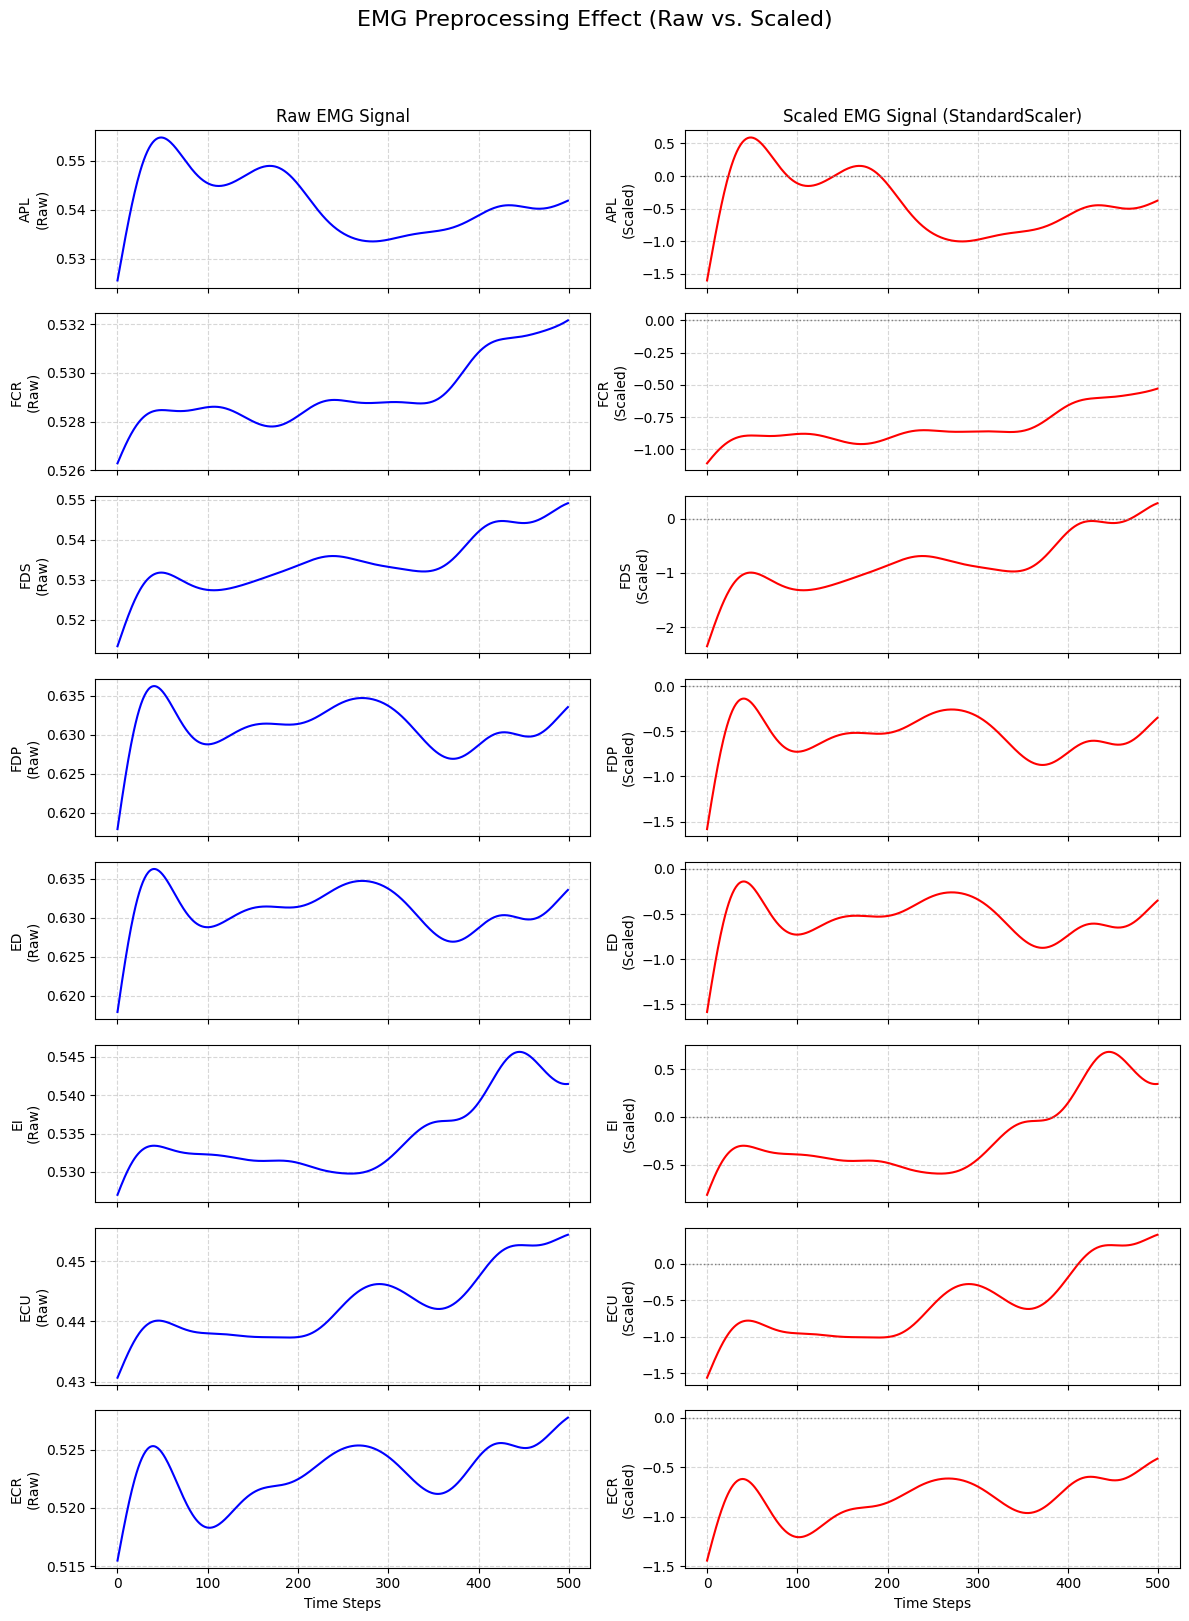


Preprocessing data for Kinematic Comparison Figure...
Processing data for the first 3 tasks.
Calculating mean trajectories (truncating to min length per task/joint)...
Preprocessing for kinematic figure complete. Max aligned length: 4000

Preprocessing data for Trial Analysis (ANOVA, Trial Changes)...
Processing data for the first 3 tasks.
Task 1: Found 5 valid trials for metric extraction.
Task 2: Found 5 valid trials for metric extraction.
Task 3: Found 5 valid trials for metric extraction.
Preprocessing for trial analysis complete.
Building MHA model...
MHA models built successfully.

--- Training Model Summary ---
Model: "Finger_MHA_Training_Model"
______________________________________________________________________________________________________________________________________________________
 Layer (type)                                    Output Shape                     Param #           Connected to                                      
 emg_input (InputLayer)             

In [ ]:
# -*- coding: utf-8 -*-
"""
Python script for predicting finger kinematics from EMG using a
Multi-Head Attention (MHA) LSTM model with specific EMG preprocessing
and Integrated Gradients for XAI.

Includes:
- Custom MHA model with separate finger heads.
- R2/CC score plotting.
- Regression correlation scatter plots.
- MHA Attention Heatmap visualization (per head, normalized).
- Dynamic Simulation plot (EMG/True Angle/Predicted Angle/Attention).
- Integrated Gradients calculation and visualization.
- Synergy Attribution visualization (Temporal).
- Muscle Co-Attribution Matrix visualization.
- Phase-Space Plot (Angle vs. Velocity) for dynamics analysis.
- Attention vs. Integrated Gradients comparison plot.
- Kinematic Trajectory Comparison plot (Actual Mean).
- Preprocessing Effect visualization (Raw vs. Scaled EMG).
- Predicted vs. Actual Mean Kinematic Trajectories plot.
- Statistical Comparison (ANOVA example) across Tasks plot.
- Trial-over-Trial Change Visualization plot (Enhanced).
- NEW: Calculation and printing of simplified summary metrics for potential clinical relevance.

Error Fixes:
- Fixed NameError for sequence_length in prediction loop.
- Refactored get_gradients and added None check for IG calculation.
"""

import numpy as np
import scipy.io
import scipy.stats # For ANOVA
# Removed: from scipy.signal import butter, sosfiltfilt # For filtering
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Layer, Dropout, Lambda, LayerNormalization, MultiHeadAttention,
    Concatenate
)
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # Keep StandardScaler
from sklearn.metrics import r2_score
import os
import warnings
import math
import pandas as pd # Added for co-attribution matrix & ANOVA viz
import seaborn as sns # Added for co-attribution matrix heatmap & ANOVA viz
from collections import defaultdict # Added for grouping trials by task

# --- Configuration ---
MAT_FILE_PATH = 's4_full.mat' # <<<--- IMPORTANT: Update this path
SEQUENCE_LENGTH = 200
PREDICTION_HORIZON = 1 # Keep as 1 for current model structure
BATCH_SIZE = 128
EPOCHS = 10 # Adjust as needed (can be increased for better performance)
LSTM_UNITS = 128
VALIDATION_SPLIT = 0.2
MAX_SAMPLES_TO_VIZ_MHA = 1 # Limit detailed MHA heatmap visualization output
NUM_TRIALS_TO_PLOT_DYNAMICS = 1 # Limit dynamic plot output
NUM_SAMPLES_FOR_XAI = 1 # How many samples to run XAI (set to 1 for faster run with new plots)
NUM_TASKS_TO_PLOT_KINEMATICS = 3 # How many tasks (columns) to show in the kinematic comparison plot
PREPROC_VIZ_TRIAL_INDEX = 0 # Which trial index (from valid trials) to use for preproc viz
PREPROC_VIZ_DURATION = 500 # How many time steps to show in preproc viz
ANOVA_METRIC_JOINT_NAME = 'Index 2' # Joint to use for ANOVA example (e.g., max angle)
TRIAL_CHANGE_JOINT_NAME = 'Index 2' # Joint to track changes over trials
TRIAL_CHANGE_EMG_NAME = 'FDS' # EMG channel to track changes over trials
# NEW: Define key joints for summary performance metrics
KEY_FUNCTIONAL_JOINTS = ['Index 1', 'Index 2', 'Index 3', 'Thumb 1', 'Thumb 2']


# MHA Configuration
NUM_ATTENTION_HEADS = 5 # Should match number of fingers
D_MODEL = LSTM_UNITS
# Ensure D_MODEL is divisible by NUM_ATTENTION_HEADS
if D_MODEL % NUM_ATTENTION_HEADS != 0:
     D_MODEL = math.ceil(D_MODEL / NUM_ATTENTION_HEADS) * NUM_ATTENTION_HEADS
     print(f"Adjusting D_MODEL to {D_MODEL} to be divisible by {NUM_ATTENTION_HEADS} heads.")

# Integrated Gradients Config
IG_STEPS = 50 # Number of steps for approximation
CO_ATTRIBUTION_THRESHOLD = 0.2 # Threshold for co-attribution matrix calculation

# EMG Channel Names (Ensure these match your .mat file structure)
EMG_CHANNEL_NAMES = ['APL', 'FCR', 'FDS', 'FDP', 'ED', 'EI', 'ECU', 'ECR']
# Joint Angle Names (Ensure these match your .mat file structure)
JOINT_ANGLE_NAMES = [
    'Thumb 1', 'Thumb 2', 'Index 1', 'Index 2', 'Index 3', 'Middle 1', 'Middle 2', 'Middle 3',
    'Ring 1', 'Ring 2', 'Ring 3', 'Little 1', 'Little 2', 'Little 3'
]
# Finger to Joint Mapping (Ensure this is correct for your angle data)
FINGER_JOINT_INDICES = {
    'Thumb': list(range(0, 2)),
    'Index': list(range(2, 5)), # Index 1=MCP, Index 2=PIP, Index 3=DIP (Example mapping)
    'Middle': list(range(5, 8)),
    'Ring': list(range(8, 11)),
    'Little': list(range(11, 14))
}
FINGER_NAMES = list(FINGER_JOINT_INDICES.keys())

# --- Muscle Group Definitions (for coloring/grouping) ---
MUSCLE_GROUPS = {
    'Finger Flexors': ['FDS', 'FDP'],
    'Finger Extensors': ['ED', 'EI'],
    'Wrist Flex/Dev': ['FCR'],
    'Wrist Extend/Dev': ['ECU', 'ECR'],
    'Thumb': ['APL']
}
# Map group names to indices
MUSCLE_GROUP_INDICES = {
    name: [EMG_CHANNEL_NAMES.index(ch) for ch in channels if ch in EMG_CHANNEL_NAMES]
    for name, channels in MUSCLE_GROUPS.items()
}
# Assign colors for visualization
try: cmap = plt.colormaps.get_cmap('tab10')
except AttributeError: cmap = plt.cm.get_cmap('tab10') # Fallback for older matplotlib
GROUP_COLORS = cmap(np.linspace(0, 1, len(MUSCLE_GROUPS)))
MUSCLE_GROUP_VIS_INFO = {name: {'indices': MUSCLE_GROUP_INDICES[name], 'color': GROUP_COLORS[i]}
                         for i, name in enumerate(MUSCLE_GROUPS.keys())}
print("Defined Muscle Groups (Indices):", MUSCLE_GROUP_INDICES)

# --- Define Synergies (Example - Adapt based on actual physiological knowledge) ---
SYNERGIES = {
    'Flexion Synergy': ['FCR', 'FDS', 'FDP'], # Example: Wrist/Finger Flexors
    'Extension Synergy': ['ED', 'ECU', 'ECR'], # Example: Finger/Wrist Extensors
    'Thumb Synergy': ['APL'] # Example: Thumb Abduction/Extension
}
# Map synergy names to EMG channel indices
SYNERGY_INDICES = {
    name: [EMG_CHANNEL_NAMES.index(ch) for ch in channels if ch in EMG_CHANNEL_NAMES]
    for name, channels in SYNERGIES.items()
}
print("Defined Synergies (Indices):", SYNERGY_INDICES)

# --- Custom Multi-Head Attention Layer ---
# (Same as previous version)
class CustomMultiHeadAttentionSeparateOutput(Layer):
    """ Custom MHA layer returning separate context vectors per head. """
    def __init__(self, num_heads, d_model, **kwargs):
        super().__init__(**kwargs)
        if d_model % num_heads != 0: raise ValueError(f"d_model ({d_model}) must be divisible by num_heads ({num_heads})")
        self.num_heads = num_heads; self.d_model = d_model; self.depth = d_model // num_heads
        self.wq = Dense(d_model, name='q_proj'); self.wk = Dense(d_model, name='k_proj'); self.wv = Dense(d_model, name='v_proj')
    def split_heads(self, x, batch_size): x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth)); return tf.transpose(x, perm=[0, 2, 1, 3])
    def scaled_dot_product_attention(self, q, k, v, mask=None):
        matmul_qk = tf.matmul(q, k, transpose_b=True); dk = tf.cast(tf.shape(k)[-1], tf.float32); scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        if mask is not None: scaled_attention_logits += (mask * -1e9)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1); output = tf.matmul(attention_weights, v); return output, attention_weights
    def call(self, query, value, key, mask=None, return_attention_scores=False):
        batch_size = tf.shape(query)[0]; q = self.wq(query); k = self.wk(key); v = self.wv(value)
        q = self.split_heads(q, batch_size); k = self.split_heads(k, batch_size); v = self.split_heads(v, batch_size)
        scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask); scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        head_outputs = [scaled_attention[:, :, i, :] for i in range(self.num_heads)]
        if query.shape[1] == 1: head_outputs_squeezed = [tf.squeeze(head, axis=1) for head in head_outputs]
        else: head_outputs_squeezed = head_outputs
        if query.shape[1] == 1: squeezed_attention_weights = tf.squeeze(attention_weights, axis=2)
        else: squeezed_attention_weights = attention_weights
        if return_attention_scores: return head_outputs_squeezed, squeezed_attention_weights
        else: return head_outputs_squeezed
    def get_config(self): config = super().get_config(); config.update({'num_heads': self.num_heads, 'd_model': self.d_model}); return config

# --- 1. Data Loading ---
# (Same as previous version)
def load_mat_data(filepath):
    """Loads EMG and joint angle data from the specified .mat file."""
    print(f"Loading data from: {filepath}")
    if not os.path.exists(filepath): print(f"Error: File not found at {filepath}"); return None, None, None, None
    try:
        mat_data = scipy.io.loadmat(filepath); emg_data_cells = mat_data.get('dsfilt_emg', mat_data.get('emg_data'))
        joint_angles_cells = mat_data.get('joint_angles', mat_data.get('angle_data')); kinematics_data = mat_data.get('finger_kinematics', None)
        displacement_data_cells = mat_data.get('displacement_data', None)
        if emg_data_cells is None or joint_angles_cells is None: print("Error: Could not find EMG or angle data."); return None, None, None, None
        print("Data loaded successfully."); return emg_data_cells, joint_angles_cells, kinematics_data, displacement_data_cells
    except Exception as e: print(f"An error occurred during loading: {e}"); return None, None, None, None

# --- 2. Data Preprocessing ---
# (Same as previous version - returns raw/scaled EMG for viz)
def preprocess_data(emg_data_cells, joint_angles_cells, sequence_length, prediction_horizon,
                    viz_trial_index=0, viz_duration=500):
    """ Preprocesses data for LSTM training and returns raw/scaled EMG segments for visualization. """
    print("Preprocessing data for LSTM training...")
    all_emg_sequences, all_angle_targets = [], []; original_scaled_trials = []
    emg_raw_segment_for_viz, emg_scaled_segment_for_viz = None, None
    num_trials, num_tasks = emg_data_cells.shape
    emg_scaler = StandardScaler(); angle_scaler = StandardScaler()
    print("Fitting scalers..."); emg_list_for_scaling = []; angle_list_for_scaling = []; valid_trial_global_indices = []
    for i in range(num_trials):
        for j in range(num_tasks):
            valid_emg = isinstance(emg_data_cells[i, j], np.ndarray) and emg_data_cells[i, j].ndim == 2 and emg_data_cells[i, j].shape[0] > 0
            valid_angle = isinstance(joint_angles_cells[i, j], np.ndarray) and joint_angles_cells[i, j].ndim == 2 and joint_angles_cells[i, j].shape[0] > 0
            if valid_emg and valid_angle:
                min_len = min(emg_data_cells[i,j].shape[0], joint_angles_cells[i,j].shape[0])
                if min_len >= sequence_length + prediction_horizon + 5: # Use global SEQUENCE_LENGTH
                    trial_emg = emg_data_cells[i, j][:min_len, :]; trial_angle = joint_angles_cells[i, j][:min_len, :]
                    if not np.any(np.isnan(trial_emg)) and not np.any(np.isinf(trial_emg)) and not np.any(np.isnan(trial_angle)) and not np.any(np.isinf(trial_angle)):
                        emg_list_for_scaling.append(trial_emg); angle_list_for_scaling.append(trial_angle); valid_trial_global_indices.append((i, j))
    if not emg_list_for_scaling: print("Error: No valid data found for scaling."); return None, None, None, None, None, None, None, None, None
    full_emg_data = np.vstack(emg_list_for_scaling); full_angle_data = np.vstack(angle_list_for_scaling)
    emg_scaler.fit(full_emg_data); angle_scaler.fit(full_angle_data); print("Scalers fitted.")
    print(f"Creating sequences from {len(valid_trial_global_indices)} valid trials..."); trial_count = 0; viz_trial_found = False
    for current_valid_idx, (i, j) in enumerate(valid_trial_global_indices):
        trial_emg_raw = emg_list_for_scaling[current_valid_idx]; trial_angle_raw = angle_list_for_scaling[current_valid_idx]
        trial_emg_scaled = emg_scaler.transform(trial_emg_raw); trial_angle_scaled = angle_scaler.transform(trial_angle_raw)
        if not viz_trial_found and current_valid_idx == viz_trial_index:
            print(f"Capturing preprocessing viz data from trial index {current_valid_idx} (Original: {i},{j})")
            segment_len = min(viz_duration, trial_emg_raw.shape[0])
            emg_raw_segment_for_viz = trial_emg_raw[:segment_len, :]; emg_scaled_segment_for_viz = trial_emg_scaled[:segment_len, :]; viz_trial_found = True
        original_scaled_trials.append({'emg': trial_emg_scaled, 'angle': trial_angle_scaled, 'id': f"T{i+1}_Task{j+1}"})
        # Use global SEQUENCE_LENGTH here too
        for k in range(len(trial_emg_scaled) - SEQUENCE_LENGTH - prediction_horizon + 1):
            emg_sequence = trial_emg_scaled[k : k + SEQUENCE_LENGTH]; angle_target = trial_angle_scaled[k + SEQUENCE_LENGTH : k + SEQUENCE_LENGTH + prediction_horizon]
            if prediction_horizon == 1: angle_target = angle_target.squeeze(axis=0)
            all_emg_sequences.append(emg_sequence); all_angle_targets.append(angle_target)
        trial_count += 1
    if not all_emg_sequences: print("Error: Could not create sequences."); return None, None, None, None, None, None, None, None, None
    X = np.array(all_emg_sequences); y = np.array(all_angle_targets); print(f"Created {X.shape[0]} sequences from {trial_count} trials.")
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=VALIDATION_SPLIT, random_state=42, shuffle=True)
    print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}")
    if not viz_trial_found: print(f"Warning: Could not find trial index {viz_trial_index} for preprocessing viz.")
    return X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials, emg_raw_viz, emg_scaled_viz


# --- Preprocessing for Kinematic Comparison Figure ---
# (Same as previous version)
def preprocess_for_kinematic_figure(kinematic_data_cells, num_tasks_to_use, angle_names, target_kinematic_indices):
    """ Groups kinematic data by task, calculates mean trajectories. """
    print(f"\nPreprocessing data for Kinematic Comparison Figure...")
    if kinematic_data_cells is None: print("Error: Kinematic data is None."); return None, 0
    num_trials, num_total_tasks = kinematic_data_cells.shape; num_tasks = min(num_tasks_to_use, num_total_tasks)
    print(f"Processing data for the first {num_tasks} tasks.")
    task_data = defaultdict(lambda: defaultdict(list)); max_len = 0
    for task_idx in range(num_tasks):
        for trial_idx in range(num_trials):
            kin_trial_task = kinematic_data_cells[trial_idx, task_idx]
            if isinstance(kin_trial_task, np.ndarray) and kin_trial_task.ndim == 2 and kin_trial_task.shape[0] > 0:
                 if not np.any(np.isnan(kin_trial_task)) and not np.any(np.isinf(kin_trial_task)):
                    trial_len = kin_trial_task.shape[0]; max_len = max(max_len, trial_len)
                    for joint_label, data_index in target_kinematic_indices.items():
                        if 0 <= data_index < kin_trial_task.shape[1]: task_data[task_idx][joint_label].append(kin_trial_task[:, data_index])
    if not task_data: print("Error: No valid kinematic data found after grouping."); return None, 0
    mean_task_data = defaultdict(dict); final_max_len = 0
    print("Calculating mean trajectories (truncating to min length per task/joint)...")
    for task_idx, joint_dict in task_data.items():
        for joint_label, trajectories in joint_dict.items():
            if not trajectories: continue
            min_len_group = min(len(t) for t in trajectories); final_max_len = max(final_max_len, min_len_group)
            truncated_trajectories = [t[:min_len_group] for t in trajectories]; stacked_trajectories = np.stack(truncated_trajectories, axis=0)
            mean_trajectory = np.mean(stacked_trajectories, axis=0); mean_task_data[task_idx][joint_label] = mean_trajectory
    print(f"Preprocessing for kinematic figure complete. Max aligned length: {final_max_len}")
    return mean_task_data, final_max_len


# --- Preprocessing for Trial-over-Trial and ANOVA (Enhanced) ---
# (Same as previous version)
def preprocess_for_trial_analysis(emg_data_cells, kinematic_data_cells, num_tasks_to_use,
                                  emg_channel_names, kinematic_names,
                                  target_emg_names, target_kinematic_names): # Accept lists
    """ Extracts multiple metrics per trial within each task for ANOVA and trial-change analysis. """
    print(f"\nPreprocessing data for Trial Analysis (ANOVA, Trial Changes)...")
    if kinematic_data_cells is None or emg_data_cells is None: print("Error: EMG or Kinematic data is None."); return None
    target_kin_indices = {}; target_emg_indices = {}
    for name in target_kinematic_names:
        try: target_kin_indices[name] = kinematic_names.index(name)
        except ValueError: print(f"Warning: Target kinematic '{name}' not found in names. Skipping.")
    for name in target_emg_names:
        try: target_emg_indices[name] = emg_channel_names.index(name)
        except ValueError: print(f"Warning: Target EMG '{name}' not found in names. Skipping.")
    if not target_kin_indices and not target_emg_indices: print("Error: No valid target features found."); return None
    num_trials, num_total_tasks = kinematic_data_cells.shape; num_tasks = min(num_tasks_to_use, num_total_tasks)
    print(f"Processing data for the first {num_tasks} tasks."); trial_metrics_by_task = defaultdict(lambda: defaultdict(list))
    for task_idx in range(num_tasks):
        num_valid_trials_thistask = 0
        for trial_idx in range(num_trials):
            kin_trial = kinematic_data_cells[trial_idx, task_idx]; emg_trial = emg_data_cells[trial_idx, task_idx]
            valid_kin = isinstance(kin_trial, np.ndarray) and kin_trial.ndim == 2 and kin_trial.shape[0] > 1
            valid_emg = isinstance(emg_trial, np.ndarray) and emg_trial.ndim == 2 and emg_trial.shape[0] > 1
            if valid_kin and valid_emg:
                 if not np.any(np.isnan(kin_trial)) and not np.any(np.isinf(kin_trial)) and not np.any(np.isnan(emg_trial)) and not np.any(np.isinf(emg_trial)):
                    valid_trial_processed = False
                    for name, kin_idx in target_kin_indices.items():
                        if kin_idx < kin_trial.shape[1]:
                             trial_metrics_by_task[task_idx][f'max_{name}'].append(np.max(kin_trial[:, kin_idx]))
                             trial_metrics_by_task[task_idx][f'mean_{name}'].append(np.mean(kin_trial[:, kin_idx]))
                             valid_trial_processed = True
                    for name, emg_idx in target_emg_indices.items():
                         if emg_idx < emg_trial.shape[1]:
                              trial_metrics_by_task[task_idx][f'mean_abs_{name}'].append(np.mean(np.abs(emg_trial[:, emg_idx])))
                              trial_metrics_by_task[task_idx][f'rms_{name}'].append(np.sqrt(np.mean(np.square(emg_trial[:, emg_idx]))))
                              valid_trial_processed = True
                    if valid_trial_processed: num_valid_trials_thistask += 1
        print(f"Task {task_idx+1}: Found {num_valid_trials_thistask} valid trials for metric extraction.")
    if not trial_metrics_by_task: print("Error: No valid trial metrics extracted."); return None
    for task_idx in list(trial_metrics_by_task.keys()):
        metric_dict = trial_metrics_by_task[task_idx]
        if not metric_dict: del trial_metrics_by_task[task_idx]; continue
        list_lens = [len(v) for v in metric_dict.values()]
        if len(set(list_lens)) > 1:
             min_len = min(list_lens) if list_lens else 0
             print(f"Warning: Inconsistent trial counts for metrics in task {task_idx}. Truncating to {min_len} trials.")
             for metric_name in metric_dict: metric_dict[metric_name] = metric_dict[metric_name][:min_len]
        if not any(len(v) > 0 for v in metric_dict.values()): print(f"Removing Task {task_idx} due to lack of consistent trial data."); del trial_metrics_by_task[task_idx]
    print("Preprocessing for trial analysis complete."); return dict(trial_metrics_by_task)


# --- 3. Model Architecture ---
# (Same as previous version)
def build_finger_mha_lstm(sequence_length, num_emg_features, num_angle_features,
                          lstm_units, d_model, num_heads, finger_joint_indices):
    """ Builds LSTM with Custom MHA and separate finger prediction heads. """
    print("Building MHA model...")
    if num_heads != len(finger_joint_indices): raise ValueError("Number of heads must match number of fingers defined.")
    encoder_inputs = Input(shape=(sequence_length, num_emg_features), name='emg_input')
    encoder_lstm = LSTM(lstm_units, return_sequences=True, return_state=True, name='encoder_lstm')
    encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)
    encoder_outputs_norm = LayerNormalization(epsilon=1e-6)(encoder_outputs); state_h_norm = LayerNormalization(epsilon=1e-6)(state_h)
    query = Lambda(lambda x: tf.expand_dims(x, axis=1), name='expand_query_dim')(state_h_norm); value = encoder_outputs_norm; key = encoder_outputs_norm
    mha_layer = CustomMultiHeadAttentionSeparateOutput(num_heads=num_heads, d_model=d_model, name='custom_mha')
    head_context_vectors, attention_weights = mha_layer(query=query, value=value, key=key, return_attention_scores=True)
    finger_outputs = []; finger_names = list(finger_joint_indices.keys())
    for i in range(num_heads):
        finger_name = finger_names[i]; num_finger_joints = len(finger_joint_indices[finger_name]); head_context = head_context_vectors[i]
        finger_dense1 = Dense(32, activation='relu', name=f'{finger_name}_dense1')(head_context); finger_dropout = Dropout(0.2, name=f'{finger_name}_dropout')(finger_dense1)
        finger_output = Dense(num_finger_joints, activation='linear', name=f'{finger_name}_output')(finger_dropout); finger_outputs.append(finger_output)
    final_output = Concatenate(axis=-1, name='final_concatenated_output')(finger_outputs)
    model = Model(inputs=encoder_inputs, outputs=final_output, name='Finger_MHA_Training_Model')
    attention_model = Model(inputs=encoder_inputs, outputs=attention_weights, name='Finger_MHA_Attention_Model')
    print("MHA models built successfully."); return model, attention_model

# --- 4. Training ---
# (Same as previous version)
def train_model(model, X_train, y_train, X_val, y_val, epochs, batch_size):
    """ Compiles and trains the model. """
    print("Compiling model..."); model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    print("Starting training..."); early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), callbacks=[early_stopping], verbose=1)
    print("Training finished."); return history

# --- 5. Performance Evaluation & Visualization ---
# (Same as previous version - includes calculate_performance_scores, plot_performance_scores, plot_regression_correlation)
def calculate_performance_scores(y_true, y_pred):
    """ Calculates R2 and Pearson CC scores for each output feature. """
    if y_true.shape != y_pred.shape: raise ValueError(f"Shape mismatch: y_true {y_true.shape}, y_pred {y_pred.shape}")
    if y_true.ndim != 2: raise ValueError(f"Expected 2D arrays, got shapes: y_true {y_true.shape}, y_pred {y_pred.shape}")
    num_features = y_true.shape[1]; r2_scores_list, cc_scores_list, cc_pvalues_list = [], [], []
    for i in range(num_features):
        r2 = r2_score(y_true[:, i], y_pred[:, i]); r2_scores_list.append(r2)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            cc, p_value = scipy.stats.pearsonr(y_true[:, i], y_pred[:, i])
            if np.isnan(cc): cc, p_value = 0.0, 1.0
        cc_scores_list.append(cc); cc_pvalues_list.append(p_value)
    return np.array(r2_scores_list), np.array(cc_scores_list), np.array(cc_pvalues_list)

def plot_performance_scores(r2_scores, cc_scores, angle_names, avg_r2=None, avg_cc=None): # Added avg scores
    """ Creates bar plots for R2 and CC scores per joint angle. """
    num_angles = len(angle_names)
    if num_angles != len(r2_scores) or num_angles != len(cc_scores):
        print("Warning: Mismatch between number of angles and scores. Adjusting plot.")
        num_angles = min(len(r2_scores), len(cc_scores)); angle_names = angle_names[:num_angles]
        r2_scores = r2_scores[:num_angles]; cc_scores = cc_scores[:num_angles]
    x = np.arange(num_angles); width = 0.35; fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    # Add average scores to titles if provided
    title_r2 = 'R² Score per Joint Angle' + (f' (Avg Key Joints: {avg_r2:.2f})' if avg_r2 is not None else '')
    title_cc = 'Correlation Coefficient (CC) per Joint Angle' + (f' (Avg Key Joints: {avg_cc:.2f})' if avg_cc is not None else '')
    rects1 = ax1.bar(x, r2_scores, width, label='R²', color='skyblue'); ax1.set_ylabel('R² Score'); ax1.set_title(title_r2)
    min_r2 = min(0, np.min(r2_scores) - 0.1 if r2_scores.size > 0 else 0); ax1.set_ylim(min_r2, 1.05); ax1.axhline(0, color='grey', lw=0.8)
    ax1.legend(); ax1.grid(axis='y', linestyle='--', alpha=0.7)
    rects2 = ax2.bar(x, cc_scores, width, label='CC', color='lightcoral'); ax2.set_ylabel('Pearson CC Score'); ax2.set_title(title_cc)
    ax2.set_xticks(x); ax2.set_xticklabels(angle_names, rotation=45, ha='right'); ax2.set_ylim(-1.05, 1.05); ax2.axhline(0, color='grey', lw=0.8)
    ax2.legend(); ax2.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout(); plt.show()

def plot_regression_correlation(y_true, y_pred, angle_names, cc_scores=None):
    """ Creates scatter plots for true vs predicted values for each angle. """
    num_angles = y_true.shape[1]
    if num_angles != len(angle_names): angle_names = [f"Angle {i+1}" for i in range(num_angles)]
    ncols = 3; nrows = math.ceil(num_angles / ncols); fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=False, sharey=False)
    axes = axes.flatten()
    for i in range(num_angles):
        ax = axes[i]; true_vals = y_true[:, i]; pred_vals = y_pred[:, i]
        ax.scatter(true_vals, pred_vals, alpha=0.3, s=10, label='Predictions')
        min_val = min(np.min(true_vals), np.min(pred_vals)); max_val = max(np.max(true_vals), np.max(pred_vals))
        padding = (max_val - min_val) * 0.05; lims = [min_val - padding, max_val + padding]
        ax.plot(lims, lims, 'k--', alpha=0.75, zorder=0, label='y=x (Ideal)'); ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_xlabel("True Values"); ax.set_ylabel("Predicted Values"); ax.set_title(f"{angle_names[i]}")
        ax.grid(True, linestyle='--', alpha=0.5)
        if cc_scores is not None and i < len(cc_scores):
            cc = cc_scores[i]; ax.text(0.05, 0.95, f'CC = {cc:.2f}', transform=ax.transAxes, fontsize=9, va='top', bbox=dict(boxstyle='round,pad=0.3', fc='wheat', alpha=0.5))
        ax.legend(loc='lower right', fontsize='small')
    for j in range(num_angles, len(axes)): fig.delaxes(axes[j])
    fig.suptitle("True vs. Predicted Values per Joint Angle", fontsize=16, y=1.02); fig.tight_layout(rect=[0, 0.03, 1, 0.98]); plt.show()


# --- 6. Attention Visualization ---
# (Same as previous version - includes get_mha_attention_weights, plot_mha_attention_heatmap)
def get_mha_attention_weights(input_data, attention_model):
    """ Extracts MHA attention weights using the dedicated attention model. """
    try: input_data_float32 = input_data.astype(np.float32); attention_weights = attention_model.predict(input_data_float32, verbose=0); return attention_weights
    except Exception as e: print(f"Error during MHA attention weight prediction: {e}"); return None

def plot_mha_attention_heatmap(input_emg_sequence, attention_weights_sample, emg_channels, muscle_group_info, finger_names, title="MHA Attention Analysis"):
    """ Plots one heatmap per head showing attended EMG activity (Normalized Per Head). """
    if attention_weights_sample is None: print("Cannot plot: Attention weights are None."); return
    num_heads, seq_len = attention_weights_sample.shape; num_emg = len(emg_channels)
    if input_emg_sequence is None or input_emg_sequence.shape != (seq_len, num_emg): print(f"Cannot plot: Input EMG sequence shape mismatch or is None."); return
    if num_heads != len(finger_names): finger_names = [f"Head {h+1}" for h in range(num_heads)]
    fig, axes = plt.subplots(num_heads, 1, figsize=(16, 3.5 * num_heads), sharex=True); fig.suptitle(title, fontsize=16, y=1.01)
    if num_heads == 1: axes = [axes]
    heatmap_data = np.zeros((num_heads, num_emg, seq_len))
    for h in range(num_heads):
        for t in range(seq_len): heatmap_data[h, :, t] = attention_weights_sample[h, t] * input_emg_sequence[t, :]
    for h in range(num_heads):
        ax = axes[h]; head_data = heatmap_data[h, :, :]; vmin_head = np.min(head_data); vmax_head = np.max(head_data)
        if abs(vmax_head - vmin_head) < 1e-6: vmin_head -= 0.01; vmax_head += 0.01
        im = ax.imshow(head_data, aspect='auto', cmap='viridis', vmin=vmin_head, vmax=vmax_head); ax.set_yticks(np.arange(num_emg)); ax.set_yticklabels(emg_channels)
        finger_name = finger_names[h]; predicted_joints = ", ".join([JOINT_ANGLE_NAMES[idx] for idx in FINGER_JOINT_INDICES.get(finger_name, [])])
        ax.set_title(f"Head {h+1} ({finger_name}) - Attended EMG Activity (Predicts: {predicted_joints})"); ax.set_ylabel("EMG Channel")
        for group_name, info in muscle_group_info.items():
            for idx in info['indices']:
                if 0 <= idx < len(ax.get_yticklabels()): ax.get_yticklabels()[idx].set_color(info['color']); ax.get_yticklabels()[idx].set_fontweight('bold')
        cbar = fig.colorbar(im, ax=ax, label='Attention * Scaled EMG', shrink=0.9, pad=0.02); cbar.ax.tick_params(labelsize=8)
    axes[-1].set_xlabel("Input Time Step within Sequence")
    legend_elements = [plt.Line2D([0], [0], color=info['color'], lw=4, label=name) for name, info in muscle_group_info.items()]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.02), ncol=len(muscle_group_info), title="Muscle Groups")
    plt.tight_layout(rect=[0, 0.05, 1, 0.98]); plt.show()

# --- 7. Dynamic EMG/Angle Simulation Plot ---
# (Same as previous version)
def plot_trial_dynamics_simulation(trial_emg_scaled, trial_angles_scaled, model, attention_model, emg_channels, joint_angle_names, muscle_group_info, finger_names, finger_joint_indices, sequence_length, prediction_horizon, trial_id="Unknown Trial"):
    """ Visualizes EMG group activity, true vs. SIMULATED joint angles, and approximated attention over a full trial."""
    print(f"\n--- Plotting Dynamics Simulation for Trial: {trial_id} ---")
    trial_len = trial_emg_scaled.shape[0]
    if trial_len < sequence_length: print(f"Trial too short. Skipping dynamics plot."); return # Use global SEQUENCE_LENGTH
    num_windows = trial_len - sequence_length + 1; X_windows = np.array([trial_emg_scaled[k : k + sequence_length] for k in range(num_windows)]); X_windows_float32 = X_windows.astype(np.float32)
    print("Running model prediction for simulation..."); y_pred_windows_scaled = model.predict(X_windows_float32, batch_size=BATCH_SIZE, verbose=0)
    print("Extracting attention weights for simulation..."); mha_attention_weights_all_windows = get_mha_attention_weights(X_windows_float32, attention_model)
    if mha_attention_weights_all_windows is None: print("Could not get attention weights. Skipping dynamic plot."); return
    num_heads = mha_attention_weights_all_windows.shape[1]; groups_to_plot = ['Finger Flexors', 'Finger Extensors']
    group_indices_to_plot = {name: muscle_group_info[name]['indices'] for name in groups_to_plot if name in muscle_group_info}; group_colors_to_plot = {name: muscle_group_info[name]['color'] for name in groups_to_plot if name in muscle_group_info}
    angle_name_to_plot = 'Index 2'; angle_idx_to_plot = JOINT_ANGLE_NAMES.index(angle_name_to_plot) if angle_name_to_plot in JOINT_ANGLE_NAMES else 0; angle_name_to_plot = JOINT_ANGLE_NAMES[angle_idx_to_plot]
    head_idx_to_plot = -1; head_name_to_plot = "N/A"
    for head_i, (finger, indices) in enumerate(finger_joint_indices.items()):
        if angle_idx_to_plot in indices: head_idx_to_plot = head_i; head_name_to_plot = finger; break
    if head_idx_to_plot == -1: head_idx_to_plot = 0; head_name_to_plot = finger_names[0] if finger_names else "Head 1"
    attention_over_time = np.mean(mha_attention_weights_all_windows[:, head_idx_to_plot, :], axis=1)
    fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True); fig.suptitle(f"Dynamic Simulation for Trial: {trial_id}", fontsize=16, y=1.01)
    time_axis_full = np.arange(trial_len); time_axis_pred = np.arange(sequence_length + prediction_horizon - 1, trial_len + prediction_horizon -1 + 1) # Use global SEQUENCE_LENGTH
    if len(time_axis_pred) != num_windows: time_axis_pred = np.arange(sequence_length, trial_len); time_axis_pred = None if len(time_axis_pred) != num_windows else time_axis_pred # Use global SEQUENCE_LENGTH
    ax1 = axes[0]
    for name, indices in group_indices_to_plot.items():
        if indices: group_activity = np.mean(trial_emg_scaled[:, indices], axis=1); ax1.plot(time_axis_full, group_activity, label=name, color=group_colors_to_plot[name], alpha=0.8)
    ax1.set_ylabel("Avg. Scaled EMG Activity"); ax1.set_title("Muscle Group Activity"); ax1.legend(loc='upper right'); ax1.grid(True, linestyle='--', alpha=0.5)
    ax2 = axes[1]; ax2.plot(time_axis_full, trial_angles_scaled[:, angle_idx_to_plot], label=f'True {angle_name_to_plot}', color='black', linestyle='--')
    if time_axis_pred is not None: ax2.plot(time_axis_pred, y_pred_windows_scaled[:, angle_idx_to_plot], label=f'Simulated {angle_name_to_plot}', color='blue', linestyle='-')
    ax2.set_ylabel("Scaled Joint Angle"); ax2.set_title(f"True vs. Simulated Joint Angle ({angle_name_to_plot})"); ax2.legend(loc='upper right'); ax2.grid(True, linestyle='--', alpha=0.5)
    ax3 = axes[2]; time_axis_attention = np.arange(num_windows)
    if len(time_axis_attention) == len(attention_over_time): ax3.plot(time_axis_attention, attention_over_time, label=f'Head {head_idx_to_plot+1} ({head_name_to_plot}) Avg. Attention', color='red', alpha=0.7)
    ax3.set_ylabel("Average Attention Weight"); ax3.set_title(f"Approximated Attention Over Time (Head for {head_name_to_plot})"); ax3.set_xlabel("Prediction Window Start Time Step"); ax3.legend(loc='upper right'); ax3.grid(True, linestyle='--', alpha=0.5); ax3.set_xlim(0, trial_len -1)
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()


# --- 8. Integrated Gradients XAI ---
# (Same as previous version - includes get_gradients, get_integrated_gradients, visualize_attributions)
def get_gradients(model, input_tensor, target_angle_index):
    """Calculates gradients of the target output angle w.r.t. input tensor."""
    input_tensor = tf.cast(input_tensor, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(input_tensor)
        predictions = model(input_tensor, training=False) # Ensure model is in inference mode
        if predictions is None: raise ValueError("Model predictions are None inside get_gradients.")
        if target_angle_index >= tf.shape(predictions)[-1]: raise ValueError(f"target_angle_index {target_angle_index} out of bounds.")
        target_output = predictions[:, target_angle_index]
    gradients = tape.gradient(target_output, input_tensor)
    if gradients is None: raise ValueError(f"Gradient calculation returned None for target index {target_angle_index}.")
    return gradients

def get_integrated_gradients(model, baseline, input_sample, target_angle_index, num_steps=50):
    """Calculates Integrated Gradients attributions."""
    if input_sample.ndim == 2: input_sample = tf.expand_dims(input_sample, axis=0)
    elif input_sample.ndim != 3: raise ValueError(f"Input sample must be 3D, got {input_sample.ndim}D")
    input_sample = tf.convert_to_tensor(input_sample, dtype=tf.float32)
    if baseline is None: baseline = tf.zeros_like(input_sample)
    else:
        if baseline.ndim == 2: baseline = tf.expand_dims(baseline, axis=0)
        baseline = tf.convert_to_tensor(baseline, dtype=tf.float32)
    if input_sample.shape != baseline.shape: raise ValueError(f"Input shape {input_sample.shape} != baseline shape {baseline.shape}")
    interpolated_inputs = tf.stack([baseline + (float(i) / num_steps) * (input_sample - baseline) for i in range(num_steps + 1)])
    original_shape = tf.shape(interpolated_inputs); batch_size = original_shape[1]; seq_len = original_shape[2]; features = original_shape[3]
    interpolated_inputs_batched = tf.reshape(interpolated_inputs, (-1, seq_len, features))
    try:
        grads = get_gradients(model, interpolated_inputs_batched, target_angle_index)
        grads = tf.reshape(grads, original_shape)
    except Exception as e: print(f"Error calculating gradients during IG: {e}"); return None
    grads = (grads[:-1] + grads[1:]) / 2.0; avg_grads = tf.reduce_mean(grads, axis=0); integrated_gradients = (input_sample - baseline) * avg_grads
    return integrated_gradients[0].numpy()

def visualize_attributions(attributions, emg_channels, muscle_group_info, title="Feature Attributions"):
    """Visualizes attributions using a heatmap and aggregated bars by muscle group."""
    seq_len, num_emg = attributions.shape
    if num_emg != len(emg_channels): print(f"Error: Attribution dimensions don't match EMG channels."); return
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]}); fig.suptitle(title, fontsize=16, y=1.01)
    ax1 = axes[0]; max_abs_val = np.max(np.abs(attributions)); vmin, vmax = -max_abs_val if max_abs_val > 0 else -1e-6, max_abs_val if max_abs_val > 0 else 1e-6; cmap = 'coolwarm'
    im = ax1.imshow(attributions.T, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax); ax1.set_yticks(np.arange(num_emg)); ax1.set_yticklabels(emg_channels)
    ax1.set_ylabel("EMG Channel"); ax1.set_xlabel("Time Step within Sequence"); ax1.set_title("Attribution Scores per Feature over Time")
    for group_name, info in muscle_group_info.items():
        for idx in info['indices']:
            if 0 <= idx < len(ax1.get_yticklabels()): ax1.get_yticklabels()[idx].set_color(info['color']); ax1.get_yticklabels()[idx].set_fontweight('bold')
    cbar = fig.colorbar(im, ax=ax1, label='Attribution Score (IG)', shrink=0.8, pad=0.02); cbar.ax.tick_params(labelsize=8)
    ax2 = axes[1]; group_names = list(muscle_group_info.keys()); total_channel_attribution = np.sum(attributions, axis=0)
    aggregated_scores = {name: 0.0 for name in group_names}
    for group_name, info in muscle_group_info.items():
        indices = info['indices']; aggregated_scores[group_name] = np.sum(total_channel_attribution[indices]) if indices else 0.0
    x_groups = np.arange(len(group_names)); colors = [muscle_group_info[name]['color'] for name in group_names]
    bars = ax2.bar(x_groups, [aggregated_scores[name] for name in group_names], color=colors)
    ax2.set_ylabel('Total Attribution Score'); ax2.set_title('Aggregated Attribution Score by Muscle Group (Summed over Time)')
    ax2.set_xticks(x_groups); ax2.set_xticklabels(group_names, rotation=30, ha='right'); ax2.grid(axis='y', linestyle='--', alpha=0.7); ax2.axhline(0, color='grey', lw=0.8)
    for bar in bars: yval = bar.get_height(); plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.2f}', va='bottom' if yval >=0 else 'top', ha='center', fontsize=9)
    plt.tight_layout(rect=[0, 0.03, 1, 0.97]); plt.show()


# --- 9. Synergy Attributions Visualization ---
# (Same as previous version)
def visualize_synergy_attributions(attributions, emg_channels, synergy_indices, title="Synergy Attributions Over Time"):
    """ Visualizes attribution scores aggregated by synergy over time using line plots. """
    seq_len, num_emg = attributions.shape
    if num_emg != len(emg_channels): print("Error: Attribution dimensions don't match EMG channels."); return
    synergy_names = list(synergy_indices.keys()); num_synergies = len(synergy_names)
    synergy_scores_over_time = np.zeros((seq_len, num_synergies))
    for i, name in enumerate(synergy_names):
        indices = synergy_indices.get(name, []); synergy_scores_over_time[:, i] = np.sum(np.abs(attributions[:, indices]), axis=1) if indices else 0.0
    y_label = "Summed Absolute Attribution Score"; plt.figure(figsize=(15, 5)); time_axis = np.arange(seq_len)
    for i, name in enumerate(synergy_names): plt.plot(time_axis, synergy_scores_over_time[:, i], label=name, linewidth=2)
    plt.title(title); plt.xlabel("Time Step within Sequence"); plt.ylabel(y_label); plt.legend(title="Synergies", loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5); plt.xlim(0, seq_len -1); plt.tight_layout(); plt.show()


# --- 10. Muscle Co-Attribution Matrix Visualization ---
# (Same as previous version)
def visualize_co_attribution_matrix(attributions, emg_channels, muscle_group_info, threshold=0.1, title="Muscle Co-Attribution Matrix (from IG)"):
    """ Creates a heatmap showing co-occurrence of high attribution scores between muscles. """
    seq_len, num_emg = attributions.shape
    if num_emg != len(emg_channels): print("Error: Attribution dimensions don't match EMG channels."); return
    max_abs_attr = np.max(np.abs(attributions)); attr_threshold_value = threshold * max_abs_attr if max_abs_attr > 0 else 1.0
    binary_attr = (np.abs(attributions) > attr_threshold_value).astype(int)
    co_attribution_matrix = np.zeros((num_emg, num_emg))
    for i in range(num_emg):
        for j in range(i, num_emg):
            co_occurrence_count = np.sum((binary_attr[:, i] == 1) & (binary_attr[:, j] == 1))
            co_occurrence_fraction = co_occurrence_count / seq_len if seq_len > 0 else 0
            co_attribution_matrix[i, j] = co_occurrence_fraction; co_attribution_matrix[j, i] = co_occurrence_fraction
    plt.figure(figsize=(10, 8))
    sns.heatmap(co_attribution_matrix, xticklabels=emg_channels, yticklabels=emg_channels, cmap="viridis", annot=False, fmt=".2f", linewidths=.5, cbar_kws={'label': f'Co-occurrence Fraction (Threshold={threshold:.2f})'})
    ax = plt.gca(); yticklabels = ax.get_yticklabels()
    for i, label in enumerate(yticklabels):
         channel_name = label.get_text()
         for group_name, info in muscle_group_info.items():
             if channel_name in [emg_channels[idx] for idx in info['indices']]: label.set_color(info['color']); label.set_fontweight('bold'); break
    plt.title(title); plt.xlabel("EMG Channel"); plt.ylabel("EMG Channel"); plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0); plt.tight_layout(); plt.show()


# --- 11. Phase-Space Plot Visualization ---
# (Same as previous version)
def visualize_phase_space(y_true_scaled, y_pred_scaled, angle_index, angle_name, title="Phase-Space Plot"):
    """ Plots angle vs. angular velocity for true and predicted data. """
    if y_true_scaled.ndim != 2 or y_pred_scaled.ndim != 2: print("Error: Input arrays must be 2D."); return
    if angle_index >= y_true_scaled.shape[1] or angle_index >= y_pred_scaled.shape[1]: print(f"Error: angle_index {angle_index} out of bounds."); return
    true_angle = y_true_scaled[:, angle_index]; pred_angle = y_pred_scaled[:, angle_index]
    true_velocity = np.diff(true_angle, prepend=true_angle[0]); pred_velocity = np.diff(pred_angle, prepend=pred_angle[0])
    plt.figure(figsize=(8, 8))
    plt.plot(true_angle, true_velocity, label='True Trajectory', color='black', linestyle='--', alpha=0.7)
    plt.plot(pred_angle, pred_velocity, label='Predicted Trajectory', color='blue', linestyle='-', alpha=0.7)
    plt.scatter(true_angle[0], true_velocity[0], marker='o', color='black', s=100, label='True Start', zorder=5)
    plt.scatter(pred_angle[0], pred_velocity[0], marker='x', color='blue', s=100, label='Pred Start', zorder=5)
    plt.title(f"{title}: {angle_name}"); plt.xlabel(f"Scaled Angle ({angle_name})"); plt.ylabel(f"Scaled Angular Velocity (Approx.)")
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.5); plt.axis('equal'); plt.tight_layout(); plt.show()


# --- 12. Attention vs. IG Comparison Visualization ---
# (Same as previous version)
def visualize_attention_vs_ig(attention_weights_head, ig_attributions, emg_channels, title="Attention vs. IG Comparison"):
    """ Plots MHA attention weights and IG attributions over time for comparison. """
    seq_len = len(attention_weights_head)
    if ig_attributions.shape[0] != seq_len: print("Error: Mismatch in sequence length between attention and IG."); return
    num_emg = ig_attributions.shape[1]
    if num_emg != len(emg_channels): print("Error: IG dimensions don't match EMG channels."); return
    ig_temporal_profile = np.sum(np.abs(ig_attributions), axis=1)
    def normalize(data): min_val = np.min(data); max_val = np.max(data); return (data - min_val) / (max_val - min_val) if max_val - min_val > 1e-6 else np.zeros_like(data)
    attn_normalized = normalize(attention_weights_head); ig_normalized = normalize(ig_temporal_profile)
    time_axis = np.arange(seq_len); plt.figure(figsize=(15, 5))
    plt.plot(time_axis, attn_normalized, label='MHA Attention (Normalized)', color='red', linestyle='-')
    plt.plot(time_axis, ig_normalized, label='Summed Abs IG (Normalized)', color='purple', linestyle='--')
    plt.title(title); plt.xlabel("Time Step within Sequence"); plt.ylabel("Normalized Importance Score"); plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5); plt.ylim(-0.05, 1.05); plt.xlim(0, seq_len - 1); plt.tight_layout(); plt.show()


# --- 13. Kinematic Trajectory Comparison Figure ---
# (Same as previous version)
def plot_kinematic_comparison_figure(mean_kinematic_data, max_len, target_kinematic_labels, num_tasks, title="Kinematic Trajectory Comparison"):
    """ Creates a grid plot showing mean kinematic trajectories for different joints and tasks. """
    if not mean_kinematic_data or max_len == 0: print("Cannot plot kinematic comparison: No processed data available."); return
    num_rows = 1; num_cols = num_tasks; fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 5 * num_rows), sharey='row', squeeze=False)
    fig.suptitle(title, fontsize=16, y=1.02); time_axis = np.arange(max_len)
    try: joint_cmap = plt.colormaps.get_cmap('viridis')
    except AttributeError: joint_cmap = plt.cm.get_cmap('viridis')
    joint_colors = joint_cmap(np.linspace(0, 1, len(target_kinematic_labels)))
    for task_idx in range(num_cols):
        ax = axes[0, task_idx]
        if task_idx in mean_kinematic_data:
            task_specific_data = mean_kinematic_data[task_idx]
            for j, joint_label in enumerate(target_kinematic_labels):
                if joint_label in task_specific_data:
                    mean_traj = task_specific_data[joint_label]; current_len = len(mean_traj)
                    if current_len == max_len: ax.plot(time_axis, mean_traj, label=joint_label, color=joint_colors[j], linewidth=2)
                    elif current_len > 0: ax.plot(np.arange(current_len), mean_traj, label=joint_label, color=joint_colors[j], linewidth=2)
            ax.set_title(f"Task {task_idx + 1}"); ax.set_xlabel("Time Steps")
            if task_idx == 0: ax.set_ylabel("Mean Scaled Angle") # Adjust label if using displacement
            ax.grid(True, linestyle='--', alpha=0.5); ax.axhline(0, color='grey', lw=0.8); ax.legend()
        else: ax.set_title(f"Task {task_idx + 1} (No Data)"); ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=ax.transAxes)
    plt.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()


# --- 14. Preprocessing Effect Visualization ---
# (Same as previous version)
def plot_preprocessing_comparison(raw_emg, scaled_emg, channel_names, duration):
    """ Plots raw vs. scaled EMG signals for comparison. """
    if raw_emg is None or scaled_emg is None: print("Skipping preprocessing visualization: Data not available."); return
    if raw_emg.shape != scaled_emg.shape: print("Skipping preprocessing visualization: Shape mismatch."); return
    num_channels = raw_emg.shape[1]; num_steps = raw_emg.shape[0]; time_axis = np.arange(num_steps)
    print(f"\n--- Plotting Preprocessing Effect (First {num_steps} steps) ---")
    fig, axes = plt.subplots(num_channels, 2, figsize=(12, 2 * num_channels), sharex=True); fig.suptitle("EMG Preprocessing Effect (Raw vs. Scaled)", fontsize=16, y=1.01)
    for i in range(num_channels):
        ax_raw = axes[i, 0]; ax_raw.plot(time_axis, raw_emg[:, i], color='blue'); ax_raw.set_ylabel(f"{channel_names[i]}\n(Raw)"); ax_raw.grid(True, linestyle='--', alpha=0.5)
        if i == 0: ax_raw.set_title("Raw EMG Signal")
        if i == num_channels - 1: ax_raw.set_xlabel("Time Steps")
        ax_scaled = axes[i, 1]; ax_scaled.plot(time_axis, scaled_emg[:, i], color='red'); ax_scaled.set_ylabel(f"{channel_names[i]}\n(Scaled)"); ax_scaled.grid(True, linestyle='--', alpha=0.5)
        ax_scaled.axhline(0, color='grey', linestyle=':', lw=1)
        if i == 0: ax_scaled.set_title("Scaled EMG Signal (StandardScaler)")
        if i == num_channels - 1: ax_scaled.set_xlabel("Time Steps")
    plt.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()


# --- 15. Predicted vs. Actual Mean Kinematics ---
# (Same as previous version)
def plot_predicted_vs_actual_kinematics(mean_actual_kin_data, mean_pred_kin_data, max_len,
                                        target_kinematic_labels, num_tasks,
                                        actual_label="Mean Actual", pred_label="Mean Predicted",
                                        title="Predicted vs. Actual Mean Kinematics"):
    """ Creates a grid plot comparing mean actual and predicted kinematic trajectories. """
    if not mean_actual_kin_data or max_len == 0: print("Cannot plot Pred vs Actual: No processed actual data available."); return
    if not mean_pred_kin_data: print("Cannot plot Pred vs Actual: No processed predicted data available."); return
    num_rows = 1; num_cols = num_tasks; fig, axes = plt.subplots(num_rows, num_cols, figsize=(6 * num_cols, 5 * num_rows), sharey='row', squeeze=False)
    fig.suptitle(title, fontsize=16, y=1.02); time_axis = np.arange(max_len)
    actual_style = '--'; pred_style = '-'; 
    try: 
        joint_cmap = plt.colormaps.get_cmap('viridis')
    except AttributeError: joint_cmap = plt.cm.get_cmap('viridis')
    joint_colors = joint_cmap(np.linspace(0, 1, len(target_kinematic_labels)))
    for task_idx in range(num_cols):
        ax = axes[0, task_idx]; ax.set_title(f"Task {task_idx + 1}"); ax.set_xlabel("Time Steps")
        if task_idx == 0: ax.set_ylabel("Scaled Angle / Kinematic")
        has_actual_data = task_idx in mean_actual_kin_data; has_pred_data = task_idx in mean_pred_kin_data
        if not has_actual_data and not has_pred_data: ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', transform=ax.transAxes); continue
        lines = []; labels = []
        for j, joint_label in enumerate(target_kinematic_labels):
            if has_actual_data and joint_label in mean_actual_kin_data[task_idx]:
                mean_actual_traj = mean_actual_kin_data[task_idx][joint_label]
                if len(mean_actual_traj) == max_len: line, = ax.plot(time_axis, mean_actual_traj, color=joint_colors[j], linestyle=actual_style, linewidth=1.5, label=f"{joint_label} ({actual_label})"); lines.append(line); labels.append(f"{joint_label} ({actual_label})") # Label each line
                elif len(mean_actual_traj) > 0: ax.plot(np.arange(len(mean_actual_traj)), mean_actual_traj, color=joint_colors[j], linestyle=actual_style, linewidth=1.5)
            if has_pred_data and joint_label in mean_pred_kin_data[task_idx]:
                mean_pred_traj = mean_pred_kin_data[task_idx][joint_label]
                if len(mean_pred_traj) == max_len: line, = ax.plot(time_axis, mean_pred_traj, color=joint_colors[j], linestyle=pred_style, linewidth=1.5, label=f"{joint_label} ({pred_label})"); lines.append(line); labels.append(f"{joint_label} ({pred_label})") # Label each line
                elif len(mean_pred_traj) > 0: ax.plot(np.arange(len(mean_pred_traj)), mean_pred_traj, color=joint_colors[j], linestyle=pred_style, linewidth=1.5)
        ax.legend(handles=lines, labels=labels, title="Joint (Actual/Pred)", loc='best', fontsize='small') # Create legend from collected lines/labels
        ax.grid(True, linestyle='--', alpha=0.5); ax.axhline(0, color='grey', lw=0.8)
    plt.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()


# --- 16. Statistical Comparison (ANOVA) ---
# (Same as previous version)
def plot_anova_results(trial_metrics_data, metric_name, num_tasks, title="ANOVA Comparison Across Tasks"):
    """ Performs ANOVA and visualizes results using box plots. """
    if not trial_metrics_data: print(f"Cannot perform ANOVA for '{metric_name}': No trial metrics data."); return
    data_for_anova = []; task_labels = []; plot_data = []
    for task_idx in range(num_tasks):
        task_metrics = trial_metrics_data.get(task_idx, {}); task_metric_values = task_metrics.get(metric_name)
        if task_metric_values is not None and len(task_metric_values) > 1:
            data_for_anova.append(task_metric_values); task_labels.append(f"Task {task_idx + 1}"); plot_data.append(np.array(task_metric_values))
        else: print(f"Skipping Task {task_idx+1} in ANOVA for '{metric_name}': Data not found or insufficient.")
    if len(data_for_anova) < 2: print(f"Cannot perform ANOVA for '{metric_name}': Less than 2 valid groups found."); return
    try:
        f_statistic, p_value = scipy.stats.f_oneway(*data_for_anova)
        print(f"\n--- ANOVA Results for '{metric_name}' across tasks ---"); print(f"F-statistic: {f_statistic:.3f}"); print(f"P-value: {p_value:.4f}")
        anova_title = f"{title}\nANOVA p-value: {p_value:.4f}"
        if p_value < 0.001: anova_title = f"{title}\nANOVA p < 0.001"
        elif p_value < 0.01: anova_title = f"{title}\nANOVA p < 0.01"
        elif p_value < 0.05: anova_title = f"{title}\nANOVA p < 0.05"
    except Exception as e: print(f"Error during ANOVA calculation for '{metric_name}': {e}"); p_value = None; anova_title = title + "\n(ANOVA Error)"
    plt.figure(figsize=(max(8, 2 * len(task_labels)), 6))
    sns.boxplot(data=plot_data, palette="viridis"); plt.xticks(ticks=np.arange(len(task_labels)), labels=task_labels)
    plt.title(anova_title); plt.xlabel("Task Condition"); plt.ylabel(f"Metric Value ({metric_name})"); plt.grid(True, axis='y', linestyle='--', alpha=0.5); plt.tight_layout(); plt.show()


# --- 17. Trial-over-Trial Change Visualization (Enhanced) ---
# (Same as previous version - plots multiple metrics in one figure)
def plot_trial_over_trial_changes(trial_metrics_data, metric_names, num_tasks, title="Trial-over-Trial Changes"):
    """ Plots the percentage change of multiple metrics relative to the first trial for each task in a single figure (one subplot per metric). """
    if not trial_metrics_data: print("Cannot plot trial changes: No trial metrics data."); return
    valid_metric_names = [m for m in metric_names if any(m in d for d in trial_metrics_data.values())]
    num_metrics = len(valid_metric_names)
    if num_metrics == 0: print("No valid metrics found for trial change plot."); return
    ncols = math.ceil(math.sqrt(num_metrics)); nrows = math.ceil(num_metrics / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), sharex=True, squeeze=False)
    axes = axes.flatten(); fig.suptitle(title, fontsize=16, y=1.02)
    try: task_cmap = plt.colormaps.get_cmap('coolwarm')
    except AttributeError: task_cmap = plt.cm.get_cmap('coolwarm')
    task_colors = task_cmap(np.linspace(0, 1, num_tasks)); task_markers = ['o', 's', '^', 'd', 'v', '<', '>']
    max_trials = 0
    for task_idx in range(num_tasks):
         if task_idx in trial_metrics_data:
             for metric_name in valid_metric_names:
                  if metric_name in trial_metrics_data[task_idx]: max_trials = max(max_trials, len(trial_metrics_data[task_idx][metric_name]))
    if max_trials < 2: print("Not enough trials (<2) to plot changes."); return
    for i, metric_name in enumerate(valid_metric_names):
        ax = axes[i]; ax.set_title(metric_name); ax.axhline(0, color='grey', linestyle='--', lw=1)
        ax.set_ylabel("% Change from Trial 1"); ax.grid(True, linestyle='--', alpha=0.5)
        if i >= num_metrics - ncols: ax.set_xlabel("Trial Number")
        lines = []; labels = []
        for task_idx in range(num_tasks):
            if task_idx in trial_metrics_data and metric_name in trial_metrics_data[task_idx]:
                metric_values = np.array(trial_metrics_data[task_idx][metric_name])
                if len(metric_values) > 1:
                    baseline_value = metric_values[0]
                    if abs(baseline_value) < 1e-9: percent_change = np.full(len(metric_values) - 1, np.nan)
                    else: percent_change = ((metric_values[1:] - baseline_value) / baseline_value) * 100
                    trial_numbers = np.arange(2, len(metric_values) + 1)
                    line, = ax.plot(trial_numbers, percent_change, marker=task_markers[task_idx % len(task_markers)], color=task_colors[task_idx], linestyle='-', label=f"Task {task_idx + 1}")
                    lines.append(line); labels.append(f"Task {task_idx + 1}")
        if lines: ax.legend(handles=lines, labels=labels, loc='best', fontsize='small')
        ax.set_xlim(1.8, max_trials + 0.2)
    for j in range(num_metrics, len(axes)): fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()


# --- 18. NEW: Clinical Metric Calculation Functions ---
def calculate_summary_performance(r2_scores, cc_scores, angle_names, key_joint_names):
    """ Calculates average R2 and CC scores over a list of key joints. """
    key_joint_indices = [i for i, name in enumerate(angle_names) if name in key_joint_names]
    if not key_joint_indices:
        print("Warning: No key joints found for summary performance calculation.")
        return None, None

    avg_r2 = np.mean(r2_scores[key_joint_indices])
    avg_cc = np.mean(cc_scores[key_joint_indices])
    print(f"\n--- Summary Performance (Key Joints: {', '.join(key_joint_names)}) ---")
    print(f"Average R2: {avg_r2:.3f}")
    print(f"Average CC: {avg_cc:.3f}")
    return avg_r2, avg_cc

def calculate_phase_space_metrics(y_true_scaled, y_pred_scaled, angle_index):
    """ Placeholder function to calculate metrics from phase space trajectories. """
    # Example metrics (require validation): Smoothness (e.g., spectral arc length), Area, Path Length
    print(f"\n--- Phase Space Metrics (Placeholder for Angle Index {angle_index}) ---")
    # Replace with actual calculation if method is defined
    smoothness_true = np.random.rand() # Dummy value
    smoothness_pred = np.random.rand() # Dummy value
    print(f"Placeholder Smoothness (True): {smoothness_true:.3f}")
    print(f"Placeholder Smoothness (Pred): {smoothness_pred:.3f}")
    return {'smoothness_true': smoothness_true, 'smoothness_pred': smoothness_pred}

def calculate_synergy_balance(synergy_scores_over_time, synergy_names, syn1_name='Flexion Synergy', syn2_name='Extension Synergy'):
    """ Placeholder function to calculate balance between two synergies. """
    print(f"\n--- Synergy Balance (Placeholder: {syn1_name} vs {syn2_name}) ---")
    try:
        idx1 = synergy_names.index(syn1_name)
        idx2 = synergy_names.index(syn2_name)
        total_syn1_score = np.sum(synergy_scores_over_time[:, idx1])
        total_syn2_score = np.sum(synergy_scores_over_time[:, idx2])
        if total_syn1_score + total_syn2_score > 1e-6:
            balance_ratio = total_syn1_score / (total_syn1_score + total_syn2_score)
            print(f"Balance Ratio ({syn1_name} / Total): {balance_ratio:.3f}")
            return balance_ratio
        else:
            print("Cannot calculate balance: Zero scores.")
            return None
    except (ValueError, IndexError):
        print(f"Cannot calculate balance: Synergies '{syn1_name}' or '{syn2_name}' not found.")
        return None

def calculate_trial_change_summary(trial_metrics_data, metric_name, task_idx):
    """ Calculates the average % change over later trials compared to trial 1. """
    print(f"\n--- Trial Change Summary (Task {task_idx+1}, Metric: {metric_name}) ---")
    if task_idx not in trial_metrics_data or metric_name not in trial_metrics_data[task_idx]:
        print("Data not available.")
        return None

    values = np.array(trial_metrics_data[task_idx][metric_name])
    if len(values) < 2:
        print("Not enough trials.")
        return None

    baseline = values[0]
    if abs(baseline) < 1e-9:
        print("Baseline near zero, cannot calculate % change.")
        return None

    percent_changes = ((values[1:] - baseline) / baseline) * 100
    avg_percent_change = np.mean(percent_changes)
    print(f"Average % Change from Trial 1 (Trials 2 onwards): {avg_percent_change:.2f}%")
    return avg_percent_change


# --- Main Execution ---
if __name__ == "__main__":
    # 1. Load Data
    emg_data_cells, joint_angles_cells, kinematics_data, displacement_data_cells = load_mat_data(MAT_FILE_PATH)

    # Choose Kinematic Data for Plotting
    if displacement_data_cells is not None:
        print("Using displacement data for kinematic comparison plot.")
        kinematic_data_to_plot = displacement_data_cells; kinematic_axis_label = "Mean Displacement (mm?)"
        TARGET_KINEMATIC_INDICES_FOR_PLOT = {'Index_Z': 2, 'Index_Y': 3 } # Example - NEEDS VERIFICATION
        TARGET_KINEMATIC_LABELS = list(TARGET_KINEMATIC_INDICES_FOR_PLOT.keys())
    elif joint_angles_cells is not None:
        print("Using joint angle data for kinematic comparison plot.")
        kinematic_data_to_plot = joint_angles_cells; kinematic_axis_label = "Mean Scaled Angle"
        TARGET_KINEMATIC_INDICES_FOR_PLOT = {
            'Index MCP': JOINT_ANGLE_NAMES.index('Index 1') if 'Index 1' in JOINT_ANGLE_NAMES else -1,
            'Index PIP': JOINT_ANGLE_NAMES.index('Index 2') if 'Index 2' in JOINT_ANGLE_NAMES else -1,
            'Index DIP': JOINT_ANGLE_NAMES.index('Index 3') if 'Index 3' in JOINT_ANGLE_NAMES else -1,
            'Thumb MCP': JOINT_ANGLE_NAMES.index('Thumb 1') if 'Thumb 1' in JOINT_ANGLE_NAMES else -1, }
        TARGET_KINEMATIC_INDICES_FOR_PLOT = {k: v for k, v in TARGET_KINEMATIC_INDICES_FOR_PLOT.items() if v != -1}
        TARGET_KINEMATIC_LABELS = list(TARGET_KINEMATIC_INDICES_FOR_PLOT.keys())
    else: print("Error: No suitable kinematic data found."); kinematic_data_to_plot = None; TARGET_KINEMATIC_LABELS = []; TARGET_KINEMATIC_INDICES_FOR_PLOT = {}

    if emg_data_cells is not None and joint_angles_cells is not None:
        # 2. Preprocess Data for LSTM (and get viz data)
        X_train, X_val, y_train, y_val, emg_scaler, angle_scaler, original_scaled_trials, \
        emg_raw_viz, emg_scaled_viz = preprocess_data(
            emg_data_cells, joint_angles_cells, SEQUENCE_LENGTH, PREDICTION_HORIZON,
            viz_trial_index=PREPROC_VIZ_TRIAL_INDEX, viz_duration=PREPROC_VIZ_DURATION
        )

        # --- Plot Preprocessing Effect ---
        plot_preprocessing_comparison(emg_raw_viz, emg_scaled_viz, EMG_CHANNEL_NAMES, PREPROC_VIZ_DURATION)

        # --- Preprocess for other figures ---
        processed_kinematic_data, kinematic_max_len = preprocess_for_kinematic_figure(
            kinematic_data_cells=kinematic_data_to_plot, num_tasks_to_use=NUM_TASKS_TO_PLOT_KINEMATICS,
            angle_names=JOINT_ANGLE_NAMES, target_kinematic_indices=TARGET_KINEMATIC_INDICES_FOR_PLOT
        )
        # Enhance trial analysis preprocessing to include more metrics
        trial_metrics_by_task = preprocess_for_trial_analysis(
             emg_data_cells=emg_data_cells, kinematic_data_cells=joint_angles_cells, # Use angles for metrics
             num_tasks_to_use=NUM_TASKS_TO_PLOT_KINEMATICS,
             emg_channel_names=EMG_CHANNEL_NAMES, kinematic_names=JOINT_ANGLE_NAMES,
             target_emg_names=[TRIAL_CHANGE_EMG_NAME], # Pass as list
             target_kinematic_names=[ANOVA_METRIC_JOINT_NAME, TRIAL_CHANGE_JOINT_NAME] # Pass as list
        )
        # --- End Preprocessing ---

        if X_train is not None:
            num_emg_features = X_train.shape[2]; num_angle_features = y_train.shape[1]
            if num_emg_features != len(EMG_CHANNEL_NAMES): print(f"FATAL Error: EMG features mismatch."); exit()
            if num_angle_features != len(JOINT_ANGLE_NAMES): print(f"FATAL Error: Angle features mismatch."); exit()
            if NUM_ATTENTION_HEADS != len(FINGER_NAMES): print(f"FATAL Error: MHA heads mismatch."); exit()

            # 3. Build MHA Models
            model, attention_model = build_finger_mha_lstm(SEQUENCE_LENGTH, num_emg_features, num_angle_features, LSTM_UNITS, D_MODEL, NUM_ATTENTION_HEADS, FINGER_JOINT_INDICES)
            print("\n--- Training Model Summary ---"); model.summary(line_length=150)

            # 4. Train Model
            history = train_model(model, X_train, y_train, X_val, y_val, EPOCHS, BATCH_SIZE)
            plt.figure(figsize=(10, 4)); plt.subplot(1, 2, 1); plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss'); plt.title('Model Loss (MSE)'); plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(True)
            plt.subplot(1, 2, 2); plt.plot(history.history['mae'], label='Train MAE'); plt.plot(history.history['val_mae'], label='Val MAE'); plt.title('Model MAE'); plt.xlabel('Epoch'); plt.ylabel('MAE'); plt.legend(); plt.grid(True)
            plt.tight_layout(); plt.show()

            # 5. Evaluate & Plot Performance Scores
            print("\n--- Performance Evaluation on Validation Set ---")
            y_pred_scaled_all_val = model.predict(X_val, batch_size=BATCH_SIZE); y_val_scaled = y_val; cc_scores = None # Rename prediction variable
            avg_r2_summary, avg_cc_summary = None, None # For clinical metrics
            if hasattr(angle_scaler, 'mean_') and angle_scaler.mean_ is not None:
                 y_val_rescaled = angle_scaler.inverse_transform(y_val_scaled); y_pred_rescaled_all_val = angle_scaler.inverse_transform(y_pred_scaled_all_val)
                 r2_scores, cc_scores, _ = calculate_performance_scores(y_val_rescaled, y_pred_rescaled_all_val)
                 print(f"Avg R2 (All): {np.mean(r2_scores):.3f}, Avg CC (All): {np.mean(cc_scores):.3f}")
                 # Calculate summary scores for key joints
                 avg_r2_summary, avg_cc_summary = calculate_summary_performance(r2_scores, cc_scores, JOINT_ANGLE_NAMES, KEY_FUNCTIONAL_JOINTS)
                 # Plot with summary scores in title
                 plot_performance_scores(r2_scores, cc_scores, JOINT_ANGLE_NAMES, avg_r2=avg_r2_summary, avg_cc=avg_cc_summary)
                 plot_regression_correlation(y_val_rescaled, y_pred_rescaled_all_val, JOINT_ANGLE_NAMES, cc_scores)
            else: print("Warning: Angle scaler not fitted."); loss, mae = model.evaluate(X_val, y_val_scaled, verbose=0); print(f"Scaled Val Loss: {loss:.4f}, MAE: {mae:.4f}"); y_pred_rescaled_all_val = None

            # --- 6. MHA Attention Visualization ---
            print("\n--- Detailed MHA Attention Visualization (Sample Windows) ---")
            num_samples_to_viz_mha = min(MAX_SAMPLES_TO_VIZ_MHA, X_val.shape[0]); mha_attention_weights_subset = None
            if num_samples_to_viz_mha > 0:
                print(f"Visualizing MHA attention for first {num_samples_to_viz_mha} samples...")
                X_val_subset_mha = X_val[:num_samples_to_viz_mha]; mha_attention_weights_subset = get_mha_attention_weights(X_val_subset_mha, attention_model)
                if mha_attention_weights_subset is not None and mha_attention_weights_subset.shape[0] == num_samples_to_viz_mha:
                    for i in range(num_samples_to_viz_mha): plot_mha_attention_heatmap(X_val_subset_mha[i], mha_attention_weights_subset[i], EMG_CHANNEL_NAMES, MUSCLE_GROUP_VIS_INFO, FINGER_NAMES, f"MHA Attention (Sample {i})")
                else: print("\nCould not extract MHA weights."); mha_attention_weights_subset = None
            else: print("Skipping MHA Heatmap viz.")

            # --- 7. Dynamic Trial Simulation Visualization ---
            print("\n--- Dynamic Trial Simulation Visualization ---")
            num_trials_to_plot = min(NUM_TRIALS_TO_PLOT_DYNAMICS, len(original_scaled_trials))
            if num_trials_to_plot > 0 and original_scaled_trials:
                 print(f"Visualizing dynamics for first {num_trials_to_plot} trial(s)...")
                 for i in range(num_trials_to_plot):
                     trial_data = original_scaled_trials[i]; plot_trial_dynamics_simulation(trial_data['emg'], trial_data['angle'], model, attention_model, EMG_CHANNEL_NAMES, JOINT_ANGLE_NAMES, MUSCLE_GROUP_VIS_INFO, FINGER_NAMES, FINGER_JOINT_INDICES, SEQUENCE_LENGTH, PREDICTION_HORIZON, trial_data['id'])
            else: print("Skipping dynamic trial plotting.")

            # --- 8-12. XAI & Biomechanics Visualizations ---
            print("\n--- XAI & Biomechanics Visualization ---")
            num_samples_to_explain = min(NUM_SAMPLES_FOR_XAI, X_val.shape[0])
            # Store results for potential summary calculations
            ig_results_list = []
            synergy_results_list = []
            phase_space_metrics_list = []

            if num_samples_to_explain > 0:
                print(f"Calculating & Visualizing for first {num_samples_to_explain} sample(s)...")
                baseline = np.zeros((1, SEQUENCE_LENGTH, num_emg_features)).astype(np.float32)
                X_explain = X_val[:num_samples_to_explain]; y_explain_pred_scaled = y_pred_scaled_all_val[:num_samples_to_explain]; y_explain_true_scaled = y_val_scaled[:num_samples_to_explain]
                plotted_full_phase_space = False
                for i in range(num_samples_to_explain):
                    print(f"\n--- Explaining Sample Index {i} ---")
                    input_sample = X_explain[i:i+1]; target_angle_name = 'Index 3' # Choose angle
                    try: target_angle_index = JOINT_ANGLE_NAMES.index(target_angle_name)
                    except ValueError: target_angle_index = 0; target_angle_name = JOINT_ANGLE_NAMES[0]
                    print(f"Explaining prediction for: {target_angle_name} (Index {target_angle_index})")
                    ig_attributions = get_integrated_gradients(model, baseline, input_sample, target_angle_index, IG_STEPS)
                    if ig_attributions is not None:
                        ig_results_list.append(ig_attributions) # Store for potential later summary
                        visualize_attributions(ig_attributions, EMG_CHANNEL_NAMES, MUSCLE_GROUP_VIS_INFO, f"IG for {target_angle_name} (Sample {i})")
                        # Calculate synergy scores for this sample
                        temp_synergy_scores = np.zeros((SEQUENCE_LENGTH, len(SYNERGY_INDICES)))
                        for s_idx, (s_name, s_indices) in enumerate(SYNERGY_INDICES.items()):
                             if s_indices: temp_synergy_scores[:, s_idx] = np.sum(np.abs(ig_attributions[:, s_indices]), axis=1)
                        synergy_results_list.append(temp_synergy_scores) # Store
                        visualize_synergy_attributions(ig_attributions, EMG_CHANNEL_NAMES, SYNERGY_INDICES, f"Synergy Attrib (IG) for {target_angle_name} (Sample {i})")
                        visualize_co_attribution_matrix(ig_attributions, EMG_CHANNEL_NAMES, MUSCLE_GROUP_VIS_INFO, CO_ATTRIBUTION_THRESHOLD, f"Co-Attrib (IG) for {target_angle_name} (Sample {i})")
                        if not plotted_full_phase_space and y_pred_scaled_all_val is not None:
                             print(f"\nPlotting Full Validation Set Phase Space for {target_angle_name}...")
                             visualize_phase_space(y_val_scaled, y_pred_scaled_all_val, target_angle_index, target_angle_name, f"Phase-Space Plot (Full Val Set)") # Use validation data
                             # Calculate placeholder phase space metrics for the full validation set
                             ps_metrics = calculate_phase_space_metrics(y_val_scaled, y_pred_scaled_all_val, target_angle_index)
                             phase_space_metrics_list.append(ps_metrics) # Store
                             plotted_full_phase_space = True
                        if mha_attention_weights_subset is not None and i < len(mha_attention_weights_subset):
                            head_idx_for_target = -1
                            for head_i, (finger, indices) in enumerate(FINGER_JOINT_INDICES.items()):
                                if target_angle_index in indices: head_idx_for_target = head_i; break
                            if head_idx_for_target != -1:
                                attention_weights_head = mha_attention_weights_subset[i, head_idx_for_target, :]
                                visualize_attention_vs_ig(attention_weights_head, ig_attributions, EMG_CHANNEL_NAMES, f"Attn (Head {head_idx_for_target+1}) vs. IG for {target_angle_name} (Sample {i})")
                    else: print(f"Skipping XAI viz for sample {i} due to IG error.")
            else: print("Skipping XAI visualizations.")

            # --- 13. Plot Kinematic Comparison Figure (Actual Mean) ---
            print("\n--- Plotting Actual Mean Kinematic Comparison Figure ---")
            if processed_kinematic_data:
                plot_kinematic_comparison_figure(processed_kinematic_data, kinematic_max_len, TARGET_KINEMATIC_LABELS, NUM_TASKS_TO_PLOT_KINEMATICS, "Mean Actual Kinematic Trajectories per Task")
                try: plt.gca().set_ylabel(kinematic_axis_label)
                except Exception: pass
            else: print("Skipping actual kinematic comparison plot.")

            # --- 15. Plot Predicted vs. Actual Mean Kinematics ---
            print("\n--- Plotting Predicted vs. Actual Mean Kinematics ---")
            mean_predicted_kin_data = None
            if original_scaled_trials:
                 print("Generating mean predictions from original trials...")
                 pred_task_data = defaultdict(lambda: defaultdict(list)); temp_max_len = 0
                 for trial_info in original_scaled_trials:
                     try:
                         task_id_str = trial_info['id'].split('_Task')[-1]; task_idx = int(task_id_str) - 1
                         if task_idx >= NUM_TASKS_TO_PLOT_KINEMATICS: continue
                         trial_emg = trial_info['emg']; trial_len = trial_emg.shape[0]
                         if trial_len < SEQUENCE_LENGTH: continue # Use global
                         num_windows = trial_len - SEQUENCE_LENGTH + 1
                         X_windows = np.array([trial_emg[k : k + SEQUENCE_LENGTH] for k in range(num_windows)]) # Use global
                         y_pred_windows = model.predict(X_windows.astype(np.float32), batch_size=BATCH_SIZE, verbose=0)
                         temp_max_len = max(temp_max_len, y_pred_windows.shape[0])
                         for joint_label, data_index in TARGET_KINEMATIC_INDICES_FOR_PLOT.items():
                              if 0 <= data_index < y_pred_windows.shape[1]: pred_task_data[task_idx][joint_label].append(y_pred_windows[:, data_index])
                     except Exception as e: print(f"Warning: Error processing trial {trial_info.get('id', 'N/A')} for prediction: {e}")

                 mean_predicted_kin_data = defaultdict(dict); final_pred_max_len = 0
                 for task_idx, joint_dict in pred_task_data.items():
                     for joint_label, trajectories in joint_dict.items():
                         if not trajectories: continue
                         min_len_group = min(len(t) for t in trajectories); final_pred_max_len = max(final_pred_max_len, min_len_group)
                         truncated_trajectories = [t[:min_len_group] for t in trajectories]; stacked_trajectories = np.stack(truncated_trajectories, axis=0)
                         mean_trajectory = np.mean(stacked_trajectories, axis=0); mean_predicted_kin_data[task_idx][joint_label] = mean_trajectory

                 plot_max_len = min(kinematic_max_len, final_pred_max_len) if kinematic_max_len > 0 else final_pred_max_len
                 if plot_max_len > 0 and mean_predicted_kin_data:
                      plot_predicted_vs_actual_kinematics(processed_kinematic_data, mean_predicted_kin_data, plot_max_len, TARGET_KINEMATIC_LABELS, NUM_TASKS_TO_PLOT_KINEMATICS, title="Mean Predicted (Red) vs. Actual (Black--) Kinematics")
                 else: print("Skipping Pred vs Actual plot: Could not determine consistent plot length or no prediction data.")
            else: print("Skipping Pred vs Actual plot: original_scaled_trials not available.")


            # --- 16. Plot ANOVA Results ---
            print("\n--- Plotting ANOVA Results ---")
            if trial_metrics_by_task:
                 metric_to_test = f'max_{ANOVA_METRIC_JOINT_NAME}' # Use configured joint name
                 plot_anova_results(trial_metrics_by_task, metric_to_test, NUM_TASKS_TO_PLOT_KINEMATICS, f"Comparison of '{metric_to_test}' Across Tasks")
            else: print("Skipping ANOVA plot: No trial metrics data available.")


            # --- 17. Plot Trial-over-Trial Changes ---
            print("\n--- Plotting Trial-over-Trial Changes ---")
            if trial_metrics_by_task:
                 metrics_to_plot = list(trial_metrics_by_task.get(0, {}).keys()) # Plot all calculated metrics
                 if metrics_to_plot:
                      plot_trial_over_trial_changes(trial_metrics_by_task, metrics_to_plot, NUM_TASKS_TO_PLOT_KINEMATICS, "Trial-over-Trial % Change from Trial 1")
                 else: print("Skipping Trial Change plot: No metrics available.")
            else: print("Skipping Trial Change plot: No trial metrics data available.")

            # --- 18. Calculate and Print Clinical Summary Metrics ---
            print("\n" + "="*20 + " CLINICAL METRIC SUMMARY (Example) " + "="*20)
            # Performance Summary (already calculated and printed)
            if avg_r2_summary is not None:
                 print(f"Overall Performance (Avg R2 Key Joints): {avg_r2_summary:.3f}")
                 print(f"Overall Performance (Avg CC Key Joints): {avg_cc_summary:.3f}")

            # Synergy Balance (Example using first XAI sample if available)
            if synergy_results_list:
                 synergy_names_list = list(SYNERGIES.keys())
                 calculate_synergy_balance(synergy_results_list[0], synergy_names_list)

            # Phase Space Metrics (Example using full validation set if available)
            if phase_space_metrics_list:
                 print(f"Phase Space Metrics (Validation Set, {target_angle_name}): {phase_space_metrics_list[0]}")

            # Trial Change Summary (Example for first task and first metric)
            if trial_metrics_by_task and available_metrics_to_plot:
                 calculate_trial_change_summary(trial_metrics_by_task, available_metrics_to_plot[0], task_idx=0)

            print("="*66)
            # --- End Clinical Metrics ---


        else: print("Preprocessing failed. Exiting.")
    else: print("Data loading failed. Exiting.")
    print("\n--- Script Execution Finished ---")

